In [1]:
import sys, os
print("python:", sys.executable)
print("cwd:", os.getcwd())
print("sys.path[0:5]:", sys.path[:5])


python: /Users/mehaksaleem/Desktop/DOFG Project/.venv-DMS/bin/python
cwd: /Users/mehaksaleem/Desktop/DOFG Project
sys.path[0:5]: ['/Users/mehaksaleem/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/lib/python311.zip', '/Users/mehaksaleem/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/lib/python3.11', '/Users/mehaksaleem/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/lib/python3.11/lib-dynload', '', '/Users/mehaksaleem/Desktop/DOFG Project/.venv-DMS/lib/python3.11/site-packages']


## 1. Setup & Imports 


In [1]:
# Essential imports
import cv2
import dlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Display settings
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("All imports successful!")



Using device: cpu
All imports successful!


## 2. Configuration & Data Structures 

In [61]:
# Configuration settings
CONFIG = {
    # Paths
    'CSV_DATASET_PATH': 'Data',
    'RESNET34_MODEL_PATH': 'resnet34_portable.state_dict.pt',
    'RESNET34_occlusion_MODEL_PATH': 'resnet34_occlusion.pth',
    'DLIB_MODEL_PATH': 'shape_predictor_68_face_landmarks.dat',
    'YawDD_DATASET_PATH' : 'C:\\Users\\salee\\OneDrive\\Desktop\\DOFG_MAIN\\YawDD Dataset\\yawdd_csvs',
    
    # Image processing
    'IMG_SIZE': (224, 224),
    'TARGET_FACE_SIZE': (224, 224),
    'IMAGENET_MEAN': [0.485, 0.456, 0.406],
    'IMAGENET_STD': [0.229, 0.224, 0.225],
    
    # Thresholds
    'EAR_THRESHOLD': 0.25,  # Eye Aspect Ratio for closed eyes
    'MAR_THRESHOLD': 0.65,  # Mouth Aspect Ratio for yawning
    'MIN_FACE_CONFIDENCE': 0.5,

    # Data
    'BATCH': 32,
    
    # CSV Labels
    'CSV_LABELS': {'EyeClosed': 0, 'Yawn': 1, 'Neutral': 2},
    'NUM_CLASSES': 3
}

# Data structures for results
@dataclass
class CSVAnnotation:
    frame: int
    timestamp: float
    class_label: str
    variant: str
    eyes_state: str
    yawn_with_hand: bool
    yawn_without_hand: bool
    eyes_occluded_prior: bool
    mouth_occluded_prior: bool
    glasses: bool

@dataclass
class PhaseResult:
    phase_name: str
    success: bool
    processing_time: float
    data: dict
    confidence: float = 0.0
    
print("Configuration and data structures defined")
print(f"Target image size: {CONFIG['IMG_SIZE']}")
print(f"Device: {device}")


Configuration and data structures defined
Target image size: (224, 224)
Device: cpu


In [62]:
import os, random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
# MODEL_TRAINER_MAP = {
#     'EnhancedOcclusionAwareTransformer': EnhancedTransformerTrainer,
#     'EnhancedTransformerNoGates': EnhancedTransformerTrainer,
#     'Level2DynamicOcclusionAwareTransformer': TinyTransformerTrainer,
#     'TransformerNoGating': TransformerNoGatingTrainer,
# }

 ## 3. CSV Video Data Loading 

In [63]:

def load_csv_video_data(dataset_path: str, filter_eye_states: bool = True) -> Dict:
    """Load CSV video annotations and metadata"""
    print(f"Loading CSV video data from: {dataset_path}")
    
    csv_metadata = {}
    excluded_states = {"opening", "closing", "undefined"}
    
    # Scan for subject folders
    for subject_folder in os.listdir(dataset_path):
        subject_path = os.path.join(dataset_path, subject_folder)
        if not os.path.isdir(subject_path):
            continue
            
        print(f"Processing subject: {subject_folder}")
        
        # Look for video and CSV files
        video_files = [f for f in os.listdir(subject_path) if f.endswith('.mp4')]
        csv_files = [f for f in os.listdir(subject_path) if f.endswith('.csv')]
        
        for video_file in video_files:
            video_name = os.path.splitext(video_file)[0]
            csv_file = f"{video_name}.csv"
            
            if csv_file in csv_files:
                video_path = os.path.join(subject_path, video_file)
                csv_path = os.path.join(subject_path, csv_file)
                
                # Load CSV annotations
                try:
                    df = pd.read_csv(csv_path)

                    if filter_eye_states:
                        before = len(df)
                        df = df[~df['eyes_state'].astype(str).str.lower().isin(excluded_states)]
                        print(f"  Loaded {len(df)} annotations from {csv_file} (filtered out {before - len(df)})")
                    else:
                        print(f"  Loaded {len(df)} annotations from {csv_file}")
                    
                    # Parse annotations
                    annotations = []
                    for _, row in df.iterrows():
                        ann = CSVAnnotation(
                            frame=int(row['frame']),
                            timestamp=float(row['timestamp_s']),
                            class_label=row['class'],
                            variant=row['variant'],
                            eyes_state=row['eyes_state'],
                            yawn_with_hand=bool(row['yawn_with_hand']),
                            yawn_without_hand=bool(row['yawn_without_hand']),
                            eyes_occluded_prior=bool(row['eyes_occluded_prior']),
                            mouth_occluded_prior=bool(row['mouth_occluded_prior']),
                            glasses=bool(row['glasses'])
                        )
                        annotations.append(ann)
                    
                    # Store metadata
                    key = f"{subject_folder}_{video_name}"
                    csv_metadata[key] = {
                        'video_path': video_path,
                        'csv_path': csv_path,
                        'annotations': annotations,
                        'total_frames': len(annotations)
                    }
                    
                except Exception as e:
                    print(f"  Error loading {csv_file}: {e}")
    
    return csv_metadata

In [64]:
# Load your CSV video data
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'])
# csv_data = load_csv_video_data('Testing_Data')

if csv_data:
    print(f"\n Loaded {len(csv_data)} video(s) with annotations")
    
    # Display statistics
    for key, meta in csv_data.items():
        annotations = meta['annotations']
        class_dist = {}
        eye_states = {}
        yawn_with_hand_states = {}
        yawn_without_hand_states = {}
        occlusion_stats = {'eyes': 0, 'mouth': 0, 'glasses': 0}
        
        for ann in annotations:
            # Class distribution
            class_dist[ann.class_label] = class_dist.get(ann.class_label, 0) + 1
            # Eye states
            eye_states[ann.eyes_state] = eye_states.get(ann.eyes_state, 0) + 1
            # Mouth states
            yawn_with_hand_states[ann.yawn_with_hand] = yawn_with_hand_states.get(ann.yawn_with_hand, 0) + 1
            yawn_without_hand_states[ann.yawn_without_hand] = yawn_without_hand_states.get(ann.yawn_without_hand, 0) + 1
            # Occlusion stats
            if ann.eyes_occluded_prior:
                occlusion_stats['eyes'] += 1
            if ann.mouth_occluded_prior:
                occlusion_stats['mouth'] += 1
            if ann.glasses:
                occlusion_stats['glasses'] += 1
        
        print(f"\n{key}:")
        print(f"  Video: {meta['video_path']}")
        print(f"  Frames: {meta['total_frames']}")
        print(f"  Classes: {class_dist}")
        print(f"  Eye states: {eye_states}, Mouth states: Yawn with hand: {yawn_with_hand_states[True]}, Yawn without hand: {yawn_without_hand_states[True]}")
        print(f"  Occlusion: Eyes={occlusion_stats['eyes']}, Mouth={occlusion_stats['mouth']}, Glasses={occlusion_stats['glasses']}")
else:
    print("❌ No CSV video data found!")


Loading CSV video data from: Data
Processing subject: Sub10
  Loaded 4440 annotations from sub10_video.csv (filtered out 1615)
Processing subject: Sub1
  Loaded 4256 annotations from sub1_video.csv (filtered out 1224)
Processing subject: Sub6
  Loaded 4031 annotations from sub6_video.csv (filtered out 1379)
Processing subject: Sub8
  Loaded 4345 annotations from sub8_video.csv (filtered out 1062)
Processing subject: Sub9
  Loaded 3977 annotations from sub9_video.csv (filtered out 1315)
Processing subject: Sub7
  Loaded 3708 annotations from sub7_video.csv (filtered out 1697)
Processing subject: Sub5
  Loaded 3642 annotations from sub5_video.csv (filtered out 1645)
Processing subject: Sub2
  Loaded 4218 annotations from sub2_video.csv (filtered out 1198)
Processing subject: Sub3
  Loaded 3463 annotations from sub3_video.csv (filtered out 2064)
Processing subject: Sub4
  Loaded 3829 annotations from sub4_video.csv (filtered out 1400)

 Loaded 10 video(s) with annotations

Sub10_sub10_vid

In [110]:
# def extract_frames(csv_data: Dict, num_samples: Optional[int] = 3) -> List[Dict]:
#     """Extract sample frames; if num_samples is None, take ALL frames for ALL videos/subjects."""
#     sample_frames = []
#     if not csv_data:
#         return sample_frames

#     for video_key, video_meta in csv_data.items():
#         print(f"Extracting frames from: {video_key}")
#         print(f"Video path: {video_meta['video_path']}")

#         cap = cv2.VideoCapture(video_meta['video_path'])
#         if not cap.isOpened():
#             print(f"Could not open video: {video_meta['video_path']}")
#             continue

#         try:
#             annotations = video_meta['annotations']
#             n = len(annotations)

#             if num_samples is None or num_samples >= n:
#                 selected_indices = range(n)
#             else:
#                 # Evenly spaced indices without step=0 issues
#                 selected_indices = np.linspace(0, n - 1, num_samples, dtype=int).tolist()

#             for i, idx in enumerate(selected_indices):
#                 annotation = annotations[idx]
#                 frame_number = annotation.frame

#                 cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
#                 ret, frame = cap.read()
#                 if ret:
#                     frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                     sample_frames.append({
#                         'frame_id': len(sample_frames) + 1,
#                         'frame_number': frame_number,
#                         'image': frame_rgb,
#                         'annotation': annotation,
#                         'video_key': video_key
#                     })
#                     # print(f"  Extracted frame {frame_number}: {annotation.class_label} | {annotation.eyes_state}")
#                 else:
#                     print(f"  Failed to extract frame {frame_number}")

#         finally:
#             print("Frames extracted successfully")
#             cap.release()

#     return sample_frames


# # def extract_frames_for_split(csv_data, video_ids, num_samples=None):
# #     return extract_frames({k: csv_data[k] for k in video_ids}, num_samples)

# # Extract sample frames
# sample_frames = extract_frames(csv_data, 10)



In [65]:
# --- 1) Deterministic split by video -----------------------------------------
import random
from collections import defaultdict

def split_video_ids(csv_data, num_test=3, num_val=0, seed=42):
    vids = sorted(csv_data.keys())
    rng = random.Random(seed)
    rng.shuffle(vids)
    #assert num_test + num_val < len(vids)
    test = vids[:num_test]; val = vids[num_test:num_test+num_val]; train = vids[num_test+num_val:]
    return {'train': train, 'val': train, 'test': test}

splits = split_video_ids(csv_data, num_test=3, num_val=0, seed=42)
print(splits)


# train_frames = extract_frames({k: csv_data[k] for k in splits['train']}, num_samples=10)
# val_frames   = extract_frames({k: csv_data[k] for k in splits['val']},   num_samples=10)
# test_frames  = extract_frames({k: csv_data[k] for k in splits['test']},  num_samples=10)

# print(len(train_frames), len(val_frames), len(test_frames))

{'train': ['Sub8_sub8_video', 'Sub5_sub5_video', 'Sub6_sub6_video', 'Sub9_sub9_video', 'Sub4_sub4_video', 'Sub10_sub10_video', 'Sub1_sub1_video'], 'val': ['Sub8_sub8_video', 'Sub5_sub5_video', 'Sub6_sub6_video', 'Sub9_sub9_video', 'Sub4_sub4_video', 'Sub10_sub10_video', 'Sub1_sub1_video'], 'test': ['Sub7_sub7_video', 'Sub3_sub3_video', 'Sub2_sub2_video']}


In [66]:
# Cell 10 - MODIFIED: Extract frames with subject-based split + stratified train/val

import pandas as pd
from sklearn.model_selection import train_test_split

def extract_frames_with_stratified_split(csv_data, splits, num_samples=None, 
                                        val_ratio=0.20, random_state=42):
    """
    Extract frames and split into train/val/test with stratification.
    
    Args:
        csv_data: Dictionary of video metadata
        splits: Dictionary with 'train' and 'test' subject lists
        num_samples: None for all frames, int for subset
        val_ratio: Validation split ratio (0.20 = 20%)
        random_state: Random seed for reproducibility
    """
    print(f"\n{'='*80}")
    print("🎯 EXTRACTING FRAMES WITH STRATIFIED SPLIT")
    print(f"{'='*80}")
    
    # Collect frames by subject category
    train_subject_frames = []  # Frames from 7 training subjects
    test_subject_frames = []   # Frames from 3 test subjects
    
    for video_key, video_meta in csv_data.items():
        print(f"Extracting frames from: {video_key}")
        
        cap = cv2.VideoCapture(video_meta['video_path'])
        if not cap.isOpened():
            print(f"Could not open video: {video_meta['video_path']}")
            continue
        
        try:
            annotations = video_meta['annotations']
            n = len(annotations)
            
            if num_samples is None or num_samples >= n:
                selected_indices = range(n)
            else:
                selected_indices = np.linspace(0, n - 1, num_samples, dtype=int).tolist()
            
            for idx in selected_indices:
                annotation = annotations[idx]
                frame_number = annotation.frame
                
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
                ret, frame = cap.read()
                
                if ret:
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame_data = {
                        'frame_id': len(train_subject_frames) + len(test_subject_frames) + 1,
                        'frame_number': frame_number,
                        # 'image': frame_rgb,
                        'image': frame,
                        'annotation': annotation,
                        'video_key': video_key,
                        'class_label': annotation.class_label  # For stratification
                    }
                    
                    # Assign to train subjects or test subjects
                    if video_key in splits['test']:
                        test_subject_frames.append(frame_data)
                    else:  # Must be in training subjects
                        train_subject_frames.append(frame_data)
        
        finally:
            cap.release()
    
    print(f"\n📊 Initial Split by Subjects:")
    print(f"   Training subjects frames: {len(train_subject_frames)}")
    print(f"   Test subjects frames: {len(test_subject_frames)}")
    
    # ========================================================================
    # STRATIFIED SPLIT: Split training subjects into train/val (80/20)
    # ========================================================================
    
    # Create DataFrame for stratification
    train_subject_df = pd.DataFrame([
        {
            'frame_data': frame,
            'class_label': frame['class_label']
        }
        for frame in train_subject_frames
    ])
    
    # Count class distribution
    class_dist = train_subject_df['class_label'].value_counts()
    print(f"\n📊 Class Distribution in Training Subjects:")
    for cls, count in class_dist.items():
        print(f"   {cls}: {count} ({100*count/len(train_subject_df):.1f}%)")
    
    # Stratified split
    train_df, val_df = train_test_split(
        train_subject_df,
        test_size=val_ratio,
        stratify=train_subject_df['class_label'],  # ← Stratify by class
        random_state=random_state
    )
    
    # Extract frame data back from DataFrames
    train_frames = [row['frame_data'] for _, row in train_df.iterrows()]
    val_frames = [row['frame_data'] for _, row in val_df.iterrows()]
    test_frames = test_subject_frames  # Already separated
    
    # Verify stratification worked
    print(f"\n✅ STRATIFIED SPLIT COMPLETE:")
    print(f"   Train: {len(train_frames)} frames")
    train_class_dist = pd.Series([f['class_label'] for f in train_frames]).value_counts()
    for cls, count in train_class_dist.items():
        print(f"      {cls}: {count} ({100*count/len(train_frames):.1f}%)")
    
    print(f"\n   Val: {len(val_frames)} frames")
    val_class_dist = pd.Series([f['class_label'] for f in val_frames]).value_counts()
    for cls, count in val_class_dist.items():
        print(f"      {cls}: {count} ({100*count/len(val_frames):.1f}%)")
    
    print(f"\n   Test: {len(test_frames)} frames")
    test_class_dist = pd.Series([f['class_label'] for f in test_frames]).value_counts()
    for cls, count in test_class_dist.items():
        print(f"      {cls}: {count} ({100*count/len(test_frames):.1f}%)")
    
    print(f"\n{'='*80}\n")
    
    return train_frames, val_frames, test_frames


# Execute the stratified split
train_frames, val_frames, test_frames = extract_frames_with_stratified_split(
    csv_data, 
    splits, 
    num_samples=100,  # Use all frames
    val_ratio=0.20,    # 80/20 split
    random_state=42    # For reproducibility
)


🎯 EXTRACTING FRAMES WITH STRATIFIED SPLIT
Extracting frames from: Sub10_sub10_video
Extracting frames from: Sub1_sub1_video
Extracting frames from: Sub6_sub6_video
Extracting frames from: Sub8_sub8_video
Extracting frames from: Sub9_sub9_video
Extracting frames from: Sub7_sub7_video
Extracting frames from: Sub5_sub5_video
Extracting frames from: Sub2_sub2_video
Extracting frames from: Sub3_sub3_video
Extracting frames from: Sub4_sub4_video

📊 Initial Split by Subjects:
   Training subjects frames: 700
   Test subjects frames: 300

📊 Class Distribution in Training Subjects:
   Neutral: 524 (74.9%)
   Yawn: 89 (12.7%)
   EyeClosed: 87 (12.4%)

✅ STRATIFIED SPLIT COMPLETE:
   Train: 560 frames
      Neutral: 419 (74.8%)
      Yawn: 71 (12.7%)
      EyeClosed: 70 (12.5%)

   Val: 140 frames
      Neutral: 105 (75.0%)
      Yawn: 18 (12.9%)
      EyeClosed: 17 (12.1%)

   Test: 300 frames
      Neutral: 228 (76.0%)
      Yawn: 38 (12.7%)
      EyeClosed: 34 (11.3%)




## 5. Phase 1: Face Detection & Landmarks  

In [67]:
import os, time, cv2, dlib, numpy as np
from typing import Dict, List, Tuple, Optional

# -------------------- utilities --------------------

def _extract_eye_regions(self, landmarks: np.ndarray) -> List[Tuple]:
    left_eye = landmarks[36:42]; right_eye = landmarks[42:48]
    def box(points, pad=10):
        x0, y0 = points.min(axis=0); x1, y1 = points.max(axis=0)
        return (int(x0-pad), int(y0-pad), int((x1-x0)+2*pad), int((y1-y0)+2*pad))
    return [box(left_eye), box(right_eye)]

def bbox_from_points(pts: np.ndarray) -> np.ndarray:
    x0, y0 = pts.min(axis=0)
    x1, y1 = pts.max(axis=0)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def expand_bbox(b: np.ndarray, scale: float = 1.25, bias=(0.0, 0.0),
                img_wh: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """Expand a bbox [x0,y0,x1,y1] by scale and bias; clip to image."""
    x0, y0, x1, y1 = b.astype(np.float32)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    w, h = (x1 - x0), (y1 - y0)
    cx += bias[0] * w
    cy += bias[1] * h
    w2, h2 = (w * scale) / 2.0, (h * scale) / 2.0
    out = np.array([cx - w2, cy - h2, cx + w2, cy + h2], dtype=np.float32)
    if img_wh is not None:
        W, H = img_wh
        out[0::2] = np.clip(out[0::2], 0, W - 1)
        out[1::2] = np.clip(out[1::2], 0, H - 1)
    return out

def rect_to_tuple(r: dlib.rectangle) -> Tuple[int, int, int, int]:
    return int(r.left()), int(r.top()), int(r.width()), int(r.height())

def approx_yaw_from_landmarks(landmarks: np.ndarray) -> float:
    le = landmarks[36:42].mean(axis=0)
    re = landmarks[42:48].mean(axis=0)
    nose = landmarks[30]
    dl = np.linalg.norm(nose - le)
    dr = np.linalg.norm(nose - re)
    if (dl + dr) == 0:
        return 0.0
    asym = (dr - dl) / (dl + dr)
    return float(asym * 90.0)

# CNN-only mouth padding
def pad_mouth_xyxy(mouth_xyxy, img_wh, scale_w=1.35, scale_h=1.6, bias_down=0.12):
    W, H = img_wh
    x0, y0, x1, y1 = map(float, mouth_xyxy)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    w, h = (x1 - x0), (y1 - y0)
    w2 = (w * scale_w) / 2.0
    h2 = (h * scale_h) / 2.0
    cy += bias_down * h  # push downward slightly
    bx0, by0, bx1, by1 = cx - w2, cy - h2, cx + w2, cy + h2
    bx0, by0, bx1, by1 = int(bx0), int(by0), int(bx1), int(by1)
    bx0 = max(0, min(W - 1, bx0))
    bx1 = max(0, min(W - 1, bx1))
    by0 = max(0, min(H - 1, by0))
    by1 = max(0, min(H - 1, by1))
    return np.array([bx0, by0, bx1, by1], dtype=int)

def xyxy_to_xywh(b: np.ndarray) -> Tuple[int, int, int, int]:
    x0, y0, x1, y1 = map(int, b)
    return (x0, y0, max(0, x1 - x0), max(0, y1 - y0))



In [68]:
# class FaceDetector:
#     def __init__(self,
#                  shape_model_path: str,
#                  cnn_model_path: str = "mmod_human_face_detector.dat",
#                  hog_upsample: int = 0,
#                  cnn_upsample: int = 0,
#                  use_pose_filter: bool = False,
#                  yaw_thresh_deg: float = 15.0):
#         self.hog = dlib.get_frontal_face_detector()
#         self.cnn = dlib.cnn_face_detection_model_v1(cnn_model_path)
#         self.predictor = dlib.shape_predictor(shape_model_path)
#         self.hog_upsample = int(hog_upsample)
#         self.cnn_upsample = int(cnn_upsample)
#         self.use_pose_filter = bool(use_pose_filter)
#         self.yaw_thresh_deg = float(yaw_thresh_deg)

#     def _predict_landmarks(self, rgb: np.ndarray, rect: dlib.rectangle) -> np.ndarray:
#         shape = self.predictor(rgb, rect)
#         return np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

#     def _rois_from_landmarks(self, landmarks: np.ndarray, img_wh: Tuple[int, int],
#     face_rect: Optional[dlib.rectangle] = None, pad_mouth=False):
#         """
#         Generate eye and mouth ROIs.
#         Eyes → fixed-pixel padding (for stability).
#         Mouth → adaptive padding (larger for CNN fallback).
#         """
#         W, H = img_wh

#         # ---- Eyes (fixed padding, your old logic) ----
#         def eye_box(points, pad=10):
#             x0, y0 = points.min(axis=0)
#             x1, y1 = points.max(axis=0)
#             x0 = max(0, int(x0 - pad))
#             y0 = max(0, int(y0 - pad))
#             w = int((x1 - x0) + 2 * pad)
#             h = int((y1 - y0) + 2 * pad)
#             # clip within image
#             x1 = min(W - 1, x0 + w)
#             y1 = min(H - 1, y0 + h)
#             return (x0, y0, w, h)

#         left_eye  = eye_box(landmarks[36:42], pad=12)
#         right_eye = eye_box(landmarks[42:48], pad=12)

#         # ---- Mouth (adaptive padding like before) ----
#         mouth_tight = bbox_from_points(landmarks[48:68])

#         if pad_mouth:
#             # CNN fallback → broader mouth
#             if face_rect is not None:
#                 face_w = face_rect.width()
#                 face_h = face_rect.height()
#                 pad_x = int(face_w * 0.20)
#                 pad_y_up = int(face_h * 0.05)
#                 pad_y_down = int(face_h * 0.25)
#             else:
#                 pad_x, pad_y_up, pad_y_down = 30, 10, 40

#             x0, y0, x1, y1 = mouth_tight.astype(int)
#             x0 = max(0, x0 - pad_x)
#             y0 = max(0, y0 - pad_y_up)
#             x1 = min(W - 1, x1 + pad_x)
#             y1 = min(H - 1, y1 + pad_y_down)
#         else:
#             # modest expansion for normal cases
#             x0, y0, x1, y1 = mouth_tight.astype(int)
#             pad_x, pad_y = 15, 10
#             x0 = max(0, x0 - pad_x)
#             y0 = max(0, y0 - pad_y)
#             x1 = min(W - 1, x1 + pad_x)
#             y1 = min(H - 1, y1 + pad_y)

#         mouth = (x0, y0, x1 - x0, y1 - y0)
#         return (left_eye, right_eye, mouth)



#     def detect_face_and_landmarks(self, image_bgr: np.ndarray) -> Dict:
#         t0 = time.time()
#         rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

#         # ---- HOG first ----
#         faces_hog = self.hog(rgb, self.hog_upsample)
#         def make_output(rect: dlib.rectangle, pad_mouth=False):
#             lm = self._predict_landmarks(rgb, rect)
#             if self.use_pose_filter:
#                 yaw = approx_yaw_from_landmarks(lm)
#                 if abs(yaw) > self.yaw_thresh_deg:
#                     return None
#             x, y, w, h = rect_to_tuple(rect)
#             W, H = image_bgr.shape[1], image_bgr.shape[0]
#             eL, eR, mB = self._rois_from_landmarks(lm, (W, H), face_rect=rect, pad_mouth=pad_mouth)
#             return {
#                 'is_valid': True,
#                 'face_bbox': (x, y, w, h),
#                 'landmarks': lm,
#                 'eye_regions': [tuple(eL), tuple(eR)],
#                 'mouth_region': tuple(mB),
#                 'processing_time': time.time() - t0
#             }

#         if len(faces_hog) > 0:
#             rect = max(faces_hog, key=lambda r: r.width() * r.height())
#             out = make_output(rect, pad_mouth=False)
#             if out is not None:
#                 return out

#         # ---- CNN fallback ----
#         dets = self.cnn(rgb, self.cnn_upsample)
#         if len(dets) == 0:
#             return {
#                 'is_valid': False, 'face_bbox': None, 'landmarks': None,
#                 'eye_regions': None, 'mouth_region': None,
#                 'processing_time': time.time() - t0
#             }
#         rects = [d.rect for d in dets]
#         rect = max(rects, key=lambda r: r.width() * r.height())
#         out = make_output(rect, pad_mouth=True)
#         if out is not None:
#             return out
#         return {
#             'is_valid': False, 'face_bbox': None, 'landmarks': None,
#             'eye_regions': None, 'mouth_region': None,
#             'processing_time': time.time() - t0
#         }


# face_detector = FaceDetector(CONFIG['DLIB_MODEL_PATH'])


# phase1_results = []


In [69]:
# ============================================================================
# STANDARDIZED FACE DETECTOR: RetinaFace + dlib landmarks
# ============================================================================

from insightface.app import FaceAnalysis

class FaceDetector:
    """
    Standardized Face Detector for T-IV Journal.
    
    - Detection: RetinaFace (InsightFace) - fast, robust under occlusion
    - Landmarks: dlib 68-point - keeps all downstream code unchanged
    
    Speed: ~30-50 FPS on GPU (report this in paper)
    """
    
    def __init__(self,
                 shape_model_path: str,
                #  det_size: Tuple[int, int] = (640, 640),
                 det_size: Tuple[int, int] = (768, 768),
                 use_pose_filter: bool = False,
                 yaw_thresh_deg: float = 15.0,
                #  det_thresh: float = 0.5):
                 det_thresh: float = 0.35):
        # RetinaFace detector
        print("Initializing RetinaFace detector...")
        self.face_app = FaceAnalysis(
            name='buffalo_sc',  # 'buffalo_sc' = fast, 'buffalo_l' = more accurate
            # providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
            providers=['CPUExecutionProvider']
        )
        
        self.face_app.prepare(ctx_id=-1, det_size=det_size, det_thresh=det_thresh)
        # self.face_app.prepare(ctx_id=0, det_size=det_size, det_thresh=det_thresh)
        
        
        # dlib for 68-point landmarks (keeps downstream code unchanged)
        self.predictor = dlib.shape_predictor(shape_model_path)
        self.use_pose_filter = bool(use_pose_filter)
        self.yaw_thresh_deg = float(yaw_thresh_deg)
        
        print(f"FaceDetector initialized:")
        print(f"  Detection: RetinaFace (buffalo_sc)")
        print(f"  Landmarks: dlib 68-point")
        print(f"  Detection threshold: {det_thresh}")
        print(f"  Pose filter: {use_pose_filter} (thresh={yaw_thresh_deg}°)")

    def _predict_landmarks(self, rgb: np.ndarray, rect: dlib.rectangle) -> np.ndarray:
        """Get 68-point landmarks using dlib."""
        shape = self.predictor(rgb, rect)
        return np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

    def _rois_from_landmarks(self, landmarks: np.ndarray, img_wh: Tuple[int, int],
                             face_rect: Optional[dlib.rectangle] = None):
        """Generate eye and mouth ROIs from 68 landmarks (unchanged from original)."""
        W, H = img_wh

        def eye_box(points, pad=12):
            x0, y0 = points.min(axis=0)
            x1, y1 = points.max(axis=0)
            x0 = max(0, int(x0 - pad))
            y0 = max(0, int(y0 - pad))
            w = int((x1 - x0) + 2 * pad)
            h = int((y1 - y0) + 2 * pad)
            x1 = min(W - 1, x0 + w)
            y1 = min(H - 1, y0 + h)
            return (x0, y0, w, h)

        left_eye = eye_box(landmarks[36:42], pad=12)
        right_eye = eye_box(landmarks[42:48], pad=12)

        # Mouth ROI
        mouth_tight = bbox_from_points(landmarks[48:68])
        x0, y0, x1, y1 = mouth_tight.astype(int)
        pad_x, pad_y = 15, 10
        x0 = max(0, x0 - pad_x)
        y0 = max(0, y0 - pad_y)
        x1 = min(W - 1, x1 + pad_x)
        y1 = min(H - 1, y1 + pad_y)
        mouth = (x0, y0, x1 - x0, y1 - y0)

        return (left_eye, right_eye, mouth)

    def detect_face_and_landmarks(self, image_bgr: np.ndarray) -> Dict:
        """
        Detect face using RetinaFace, get landmarks using dlib.
        Output format is identical to original - no downstream changes needed.
        """
        t0 = time.time()
        rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        H, W = image_bgr.shape[:2]

        # RetinaFace detection
        # faces = self.face_app.get(rgb)
        faces = self.face_app.get(image_bgr)
        
        if len(faces) == 0:
            return {
                'is_valid': False,
                'face_bbox': None,
                'landmarks': None,
                'eye_regions': None,
                'mouth_region': None,
                'processing_time': time.time() - t0,
                'detector': 'retinaface'
            }
        
        # Pick largest face
        face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
        
        # Convert RetinaFace bbox [x1,y1,x2,y2] to dlib.rectangle
        x1, y1, x2, y2 = face.bbox.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W - 1, x2), min(H - 1, y2)
        rect = dlib.rectangle(x1, y1, x2, y2)
        
        # Get 68-point landmarks using dlib
        landmarks = self._predict_landmarks(rgb, rect)
        
        # Optional pose filter
        if self.use_pose_filter:
            yaw = approx_yaw_from_landmarks(landmarks)
            if abs(yaw) > self.yaw_thresh_deg:
                return {
                    'is_valid': False,
                    'face_bbox': None,
                    'landmarks': None,
                    'eye_regions': None,
                    'mouth_region': None,
                    'processing_time': time.time() - t0,
                    'detector': 'retinaface'
                }
        
        # Get ROIs (same logic as before)
        face_bbox = (x1, y1, x2 - x1, y2 - y1)  # (x, y, w, h)
        eL, eR, mB = self._rois_from_landmarks(landmarks, (W, H), face_rect=rect)
        
        return {
            'is_valid': True,
            'face_bbox': face_bbox,
            'landmarks': landmarks,
            'eye_regions': [tuple(eL), tuple(eR)],
            'mouth_region': tuple(mB),
            'processing_time': time.time() - t0,
            'detector': 'retinaface',
            'detection_score': float(face.det_score)  # Confidence score for paper
        }


# Initialize (same interface - just pass the dlib landmark model path)
face_detector = FaceDetector(CONFIG['DLIB_MODEL_PATH'])




Initializing RetinaFace detector...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (768, 768)
FaceDetector initialized:
  Detection: RetinaFace (buffalo_sc)
  Landmarks: dlib 68-point
  Detection threshold: 0.35
  Pose filter: False (thresh=15.0°)


In [70]:
from modulefinder import test


phase1_results = []

print("PHASE 1: Face Detection & Landmarks")
print("=" * 50)

for frame_data in test_frames[:100]:
    print(f"Processing Frame {frame_data['frame_id']}...")
    
    # Detect face and landmarks
    face_result = face_detector.detect_face_and_landmarks(frame_data['image'])
    
    # Create phase result
    phase1_result = PhaseResult(
        phase_name="Phase 1: Face Detection",
        success=face_result['is_valid'],
        processing_time=face_result['processing_time'],
        data=face_result,
        confidence=face_result.get('detection_confidence', 0.0)
    )
    
    phase1_results.append(phase1_result)
    
    # Display results
    if face_result['is_valid']:
        print(f"   Face detected successfully")
        print(f"   Face bbox: {face_result['face_bbox']}")
        print(f"   Eye regions: {len(face_result['eye_regions'])} detected")
        print(f"   Mouth region: {'✓' if face_result['mouth_region'] else '✗'}")
        print(f"   Processing time: {face_result['processing_time']:.4f}s")
        print(f"   Landmarks: {len(face_result['landmarks'])} points")
    else:
        print(f"   Face detection failed")


PHASE 1: Face Detection & Landmarks
Processing Frame 501...
   Face detected successfully
   Face bbox: (np.int64(388), np.int64(285), np.int64(229), np.int64(323))
   Eye regions: 2 detected
   Mouth region: ✓
   Processing time: 0.0712s
   Landmarks: 68 points
Processing Frame 502...
   Face detected successfully
   Face bbox: (np.int64(361), np.int64(340), np.int64(236), np.int64(326))
   Eye regions: 2 detected
   Mouth region: ✓
   Processing time: 0.0371s
   Landmarks: 68 points
Processing Frame 503...
   Face detected successfully
   Face bbox: (np.int64(476), np.int64(255), np.int64(211), np.int64(303))
   Eye regions: 2 detected
   Mouth region: ✓
   Processing time: 0.0311s
   Landmarks: 68 points
Processing Frame 504...
   Face detected successfully
   Face bbox: (np.int64(485), np.int64(258), np.int64(208), np.int64(291))
   Eye regions: 2 detected
   Mouth region: ✓
   Processing time: 0.0313s
   Landmarks: 68 points
Processing Frame 505...
   Face detected successfully
  

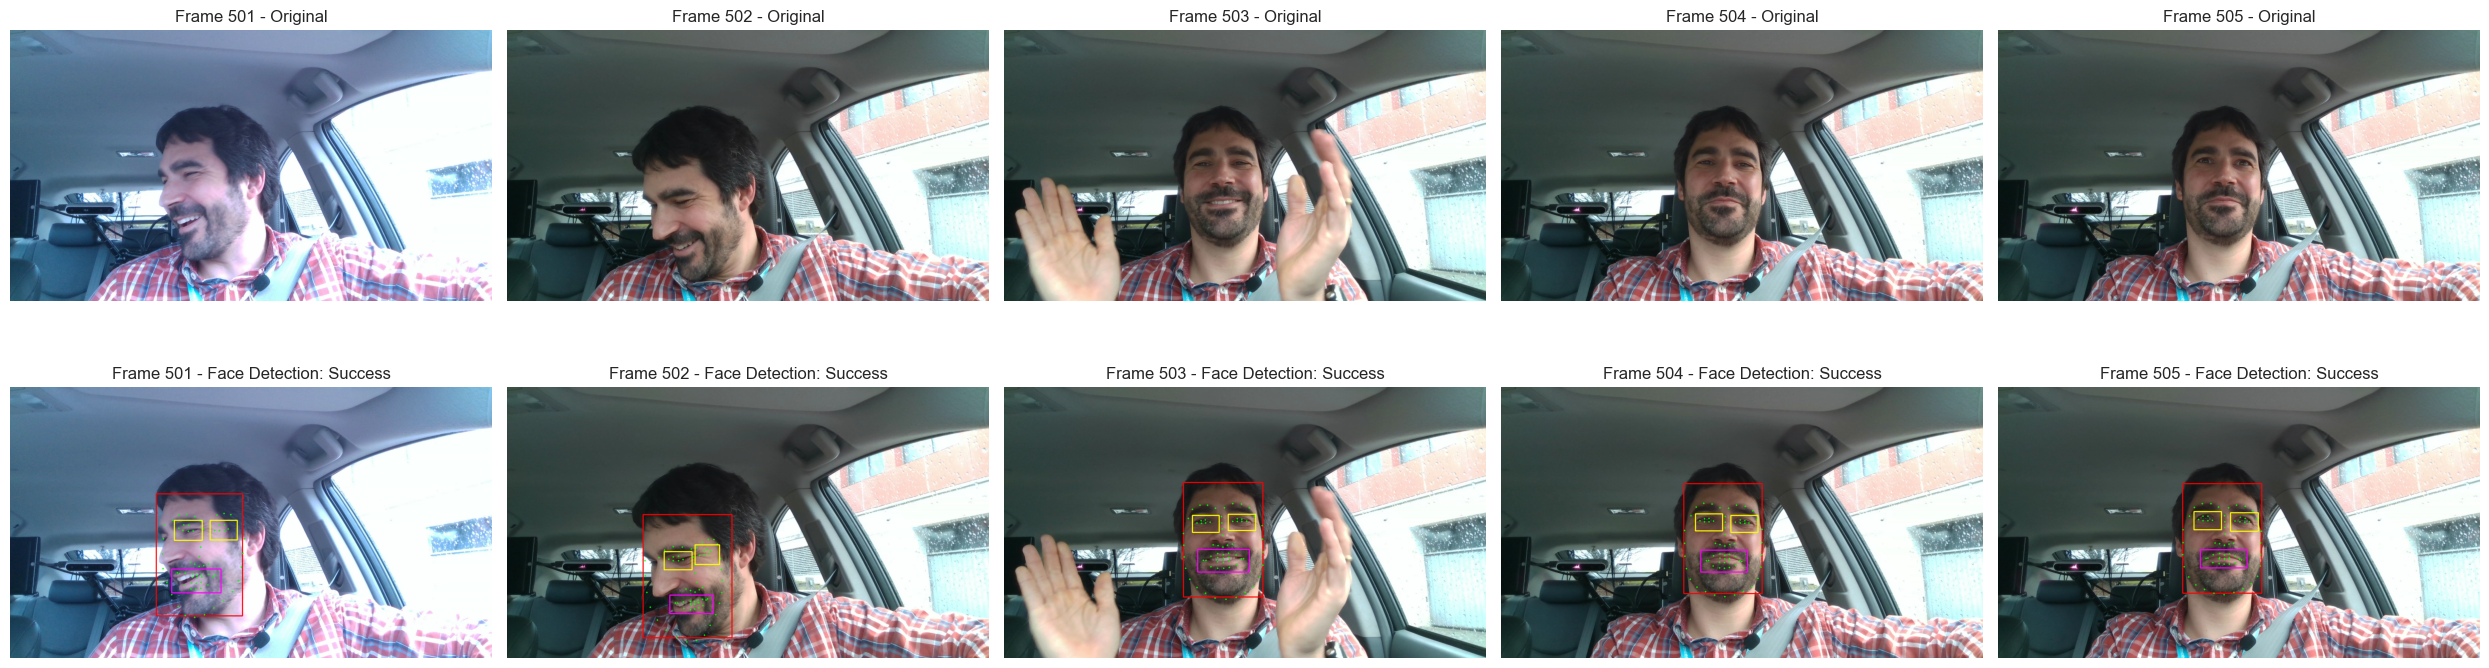

Phase 1 Summary: 5/5 successful


In [71]:
num_to_show = min(4, len(test_frames), len(phase1_results))
# viz_frames  = test_frames[:num_to_show]
# viz_results = phase1_results[:num_to_show]
viz_frames  = test_frames[:5]
viz_results = phase1_results[:5]

if viz_frames:  # don't hide originals when all detections fail
    fig, axes = plt.subplots(2, len(viz_frames), figsize=(5*len(viz_frames), 8))
    if len(viz_frames) == 1:
        axes = axes.reshape(2, 1)

    for i, (frame_data, phase1_result) in enumerate(zip(viz_frames, viz_results)):
        img_bgr = frame_data['image']

        # --- row 1: originals (convert BGR->RGB for matplotlib) ---
        axes[0, i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        # axes[0, i].imshow(img_bgr)

        axes[0, i].set_title(f"Frame {frame_data['frame_id']} - Original")
        axes[0, i].axis('off')

        # --- row 2: drawings on a copy in BGR, then convert once for display ---
        img_draw = img_bgr.copy()

        if phase1_result.success:
            face_data = phase1_result.data

            # Face bbox (BGR colors!):
            x, y, w, h = map(int, face_data['face_bbox'])
            cv2.rectangle(img_draw, (x, y), (x + w, y + h), (0, 0, 255), 2)       # red

            # Landmarks
            for (lx, ly) in face_data['landmarks']:
                cv2.circle(img_draw, (int(lx), int(ly)), 2, (0, 255, 0), -1)       # green

            # Eye regions
            for eye_bbox in face_data['eye_regions']:
                ex, ey, ew, eh = map(int, eye_bbox)
                cv2.rectangle(img_draw, (ex, ey), (ex + ew, ey + eh), (0, 255, 255), 2)  # yellow

            # Mouth region (may be None)
            mr = face_data.get('mouth_region')
            if mr is not None:
                mx, my, mw, mh = map(int, mr)
                cv2.rectangle(img_draw, (mx, my), (mx + mw, my + mh), (255, 0, 255), 2)  # magenta

        axes[1, i].imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
        # axes[1, i].imshow(img_draw)

        axes[1, i].set_title(
            f"Frame {frame_data['frame_id']} - Face Detection: {'Success' if phase1_result.success else 'Failed'}"
        )
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

print(f"Phase 1 Summary: {sum(r.success for r in viz_results)}/{len(viz_results)} successful")


In [72]:
# # Test: Print actual coordinates for consecutive frames
# for i, frame in enumerate(test_frames[:5]):
#     result = face_detector.detect_face_and_landmarks(frame['image'])
#     if result['is_valid']:
#         print(f"Frame {500+i}: bbox={result['face_bbox']}, score={result.get('detection_score', 'N/A'):.3f}")
#     else:
#         print(f"Frame {500+i}: No face detected")

In [13]:
# # Filter for frames with ANY occlusion (eyes OR mouth)
# occluded_frames = [
#     frame for frame in sample_frames 
#     if frame['annotation'].eyes_occluded_prior or frame['annotation'].mouth_occluded_prior
# ]

# print(f"Found {len(occluded_frames)} occluded frames out of {len(sample_frames)} total")

# # Breakdown by occlusion type
# eyes_occluded = [f for f in occluded_frames if f['annotation'].eyes_occluded_prior]
# mouth_occluded = [f for f in occluded_frames if f['annotation'].mouth_occluded_prior]
# both_occluded = [f for f in occluded_frames if f['annotation'].eyes_occluded_prior and f['annotation'].mouth_occluded_prior]

# print(f"  Eyes occluded: {len(eyes_occluded)}")
# print(f"  Mouth occluded: {len(mouth_occluded)}")
# print(f"  Both occluded: {len(both_occluded)}")

# # Show a sample
# if occluded_frames:
#     sample = occluded_frames[0]
#     print(f"\nSample occluded frame:")
#     print(f"  Frame ID: {sample['frame_id']}")
#     print(f"  Video: {sample['video_key']}")
#     print(f"  Class: {sample['annotation'].class_label}")
#     print(f"  Eyes occluded: {sample['annotation'].eyes_occluded_prior}")
#     print(f"  Mouth occluded: {sample['annotation'].mouth_occluded_prior}")

## Phase 2: ResNet34 Feature Extraction


In [73]:
import torch
import torch.nn as nn
from torchvision import models as tv_models

class ResNet34Classifier(nn.Module):
    def __init__(self, num_classes=3, dropout_prob=0.3):
        super().__init__()
        self.model = tv_models.resnet34(weights=tv_models.ResNet34_Weights.DEFAULT)

        # freeze all except layer4 and fc (exactly as before)
        for p in self.model.parameters():
            p.requires_grad = False
        for p in self.model.layer4.parameters():
            p.requires_grad = True
        for p in self.model.fc.parameters():
            p.requires_grad = True

        # add dropout same as training
        self.model.layer4 = nn.Sequential(self.model.layer4, nn.Dropout(dropout_prob))
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [74]:
# Cell 21 - MODIFIED: Add augmentation support

class ResNet34FeatureExtractor:
    def __init__(self, model_path: str, device: str = 'auto'):
        if device == 'auto':
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        
        # Load your trained model
        try:
            print(f"Loading trained ResNet34 from {model_path}")
            self.model = ResNet34Classifier(num_classes=3, dropout_prob=0.3)
            self.model.load_state_dict(torch.load("resnet34_portable.state_dict.pt", map_location=device))
            self.model.to(device)
            self.model.eval()
            print(f"✅ Loaded trained ResNet34 from {model_path}")
        except Exception as e:
            print(f"Error loading model: {e}")
            self.model = ResNet34Classifier(num_classes=CONFIG['NUM_CLASSES'])
            self.model.to(self.device)
            self.model.eval()
            print("⚠️ Using untrained ResNet34 architecture")
        
        # Create feature extractor
        self.feature_extractor = self._create_feature_extractor()
        
        # ========================================================================
        # TRAINING transforms (WITH augmentation - matches baseline)
        # ========================================================================
        self.transform_train = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomResizedCrop(224, antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=CONFIG['IMAGENET_MEAN'], std=CONFIG['IMAGENET_STD'])
        ])
        
        # ========================================================================
        # VAL/TEST transforms (NO augmentation)
        # ========================================================================
        self.transform_val = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=CONFIG['IMAGENET_MEAN'], std=CONFIG['IMAGENET_STD'])
        ])
        
        print(f"✅ Feature extractor ready on {self.device}")
        print(f"   Training mode: Augmentation ENABLED")
        print(f"   Inference mode: Augmentation DISABLED")
    
    def _create_feature_extractor(self):
        """Create feature extractor that outputs penultimate features (512D)"""
        if hasattr(self.model, 'model'):
            backbone = self.model.model
        else:
            backbone = self.model
        
        feature_extractor = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
            backbone.avgpool
        )
        
        feature_extractor.to(self.device)
        feature_extractor.eval()
        return feature_extractor
    
    def extract_region_features(self, image: np.ndarray, face_bbox: Tuple, 
                              eye_regions: List[Tuple], mouth_region: Tuple,
                              is_training: bool = False) -> Dict:  # ← ADD is_training parameter
        """Extract ResNet34 features from facial regions with optional augmentation"""
        start_time = time.time()
        
        # Choose transform based on mode
        transform = self.transform_train if is_training else self.transform_val
        
        results = {
            'face_features': None,
            'left_eye_features': None,
            'right_eye_features': None,
            'mouth_features': None,
            'successful_regions': [],
            'processing_time': 0.0,
            'extraction_confidence': 0.0
        }
        
        try:
            # Extract face features
            if face_bbox:
                face_features = self._extract_single_region(
                    image, face_bbox, "face", transform
                )
                if face_features is not None:
                    results['face_features'] = face_features
                    results['successful_regions'].append('face')
            
            # Extract eye features
            if eye_regions and len(eye_regions) >= 2:
                left_eye_features = self._extract_single_region(
                    image, eye_regions[0], "left_eye", transform
                )
                if left_eye_features is not None:
                    results['left_eye_features'] = left_eye_features
                    results['successful_regions'].append('left_eye')
                
                right_eye_features = self._extract_single_region(
                    image, eye_regions[1], "right_eye", transform
                )
                if right_eye_features is not None:
                    results['right_eye_features'] = right_eye_features
                    results['successful_regions'].append('right_eye')
            
            # Extract mouth features
            if mouth_region:
                mouth_features = self._extract_single_region(
                    image, mouth_region, "mouth", transform
                )
                if mouth_features is not None:
                    results['mouth_features'] = mouth_features
                    results['successful_regions'].append('mouth')
            
            # Calculate extraction confidence
            total_regions = 4
            successful_count = len(results['successful_regions'])
            results['extraction_confidence'] = successful_count / total_regions
            
            results['processing_time'] = time.time() - start_time
            
        except Exception as e:
            print(f"Error in feature extraction: {e}")
            results['processing_time'] = time.time() - start_time
        
        return results
    
    def _extract_single_region(self, image: np.ndarray, region_bbox: Tuple, 
                               region_name: str, transform) -> Optional[np.ndarray]:
        """Extract features from a single region with specified transform"""
        try:
            x, y, w, h = [int(v) for v in region_bbox]
            
            # Add bounds checking
            x = max(0, x)
            y = max(0, y)
            w = min(image.shape[1] - x, w)
            h = min(image.shape[0] - y, h)
            
            if w <= 0 or h <= 0:
                return None
            
            # Crop region
            region = image[y:y+h, x:x+w]
            
            if region.size == 0:
                return None
            
            # Apply transform (augmentation if is_training=True)
            region_tensor = transform(region).unsqueeze(0).to(self.device)
            
            # Extract features
            with torch.no_grad():
                features = self.feature_extractor(region_tensor)
                features = features.view(features.size(0), -1).cpu().numpy().squeeze()
            
            return features.astype(np.float32)
            
        except Exception as e:
            print(f"Error extracting {region_name} features: {e}")
            return None




feature_extractor = ResNet34FeatureExtractor(CONFIG['RESNET34_MODEL_PATH'], device)


Loading trained ResNet34 from resnet34_portable.state_dict.pt
✅ Loaded trained ResNet34 from resnet34_portable.state_dict.pt
✅ Feature extractor ready on cpu
   Training mode: Augmentation ENABLED
   Inference mode: Augmentation DISABLED


In [75]:
# Test that augmentation transforms are available
print("\n✅ Verification:")
print(f"   Has transform_train: {hasattr(feature_extractor, 'transform_train')}")
print(f"   Has transform_val: {hasattr(feature_extractor, 'transform_val')}")
print(f"   Transform train type: {type(feature_extractor.transform_train)}")


✅ Verification:
   Has transform_train: True
   Has transform_val: True
   Transform train type: <class 'torchvision.transforms.transforms.Compose'>


In [76]:
# Debug: Check feature extractor attributes
print("Feature extractor attributes:")
print(f"  Has 'transform': {hasattr(feature_extractor, 'transform')}")
print(f"  Has 'transform_train': {hasattr(feature_extractor, 'transform_train')}")
print(f"  Has 'transform_val': {hasattr(feature_extractor, 'transform_val')}")
print(f"\nAll attributes: {[attr for attr in dir(feature_extractor) if not attr.startswith('_')]}")

Feature extractor attributes:
  Has 'transform': False
  Has 'transform_train': True
  Has 'transform_val': True

All attributes: ['device', 'extract_region_features', 'feature_extractor', 'model', 'transform_train', 'transform_val']


## occlusion_inference.py


In [77]:
# occlusion_inference.py
import os
import math
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as M
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def _safe_crop(img_np, bbox, margin=0.15):
    """
    img_np: HxWxC uint8 (RGB or BGR)
    bbox:   (x, y, w, h) OR dict with those keys (ints or floats)
    margin: extra context as a fraction of w/h
    """
    if isinstance(bbox, dict):
        x, y, w, h = bbox.get("x", bbox.get("left", 0)), bbox.get("y", bbox.get("top", 0)), bbox.get("w", bbox.get("width", 0)), bbox.get("h", bbox.get("height", 0))
        if w == 0 or h == 0:  # allow (x,y,w,h) stored under different names
            x, y, w, h = bbox.get("x", 0), bbox.get("y", 0), bbox.get("w", 0), bbox.get("h", 0)
    else:
        x, y, w, h = bbox  # assume (x,y,w,h)

    H, W = img_np.shape[:2]
    x1 = int(max(0, math.floor(x - margin * w)))
    y1 = int(max(0, math.floor(y - margin * h)))
    x2 = int(min(W, math.ceil(x + w + margin * w)))
    y2 = int(min(H, math.ceil(y + h + margin * h)))
    crop = img_np[y1:y2, x1:x2]
    if crop.size == 0:
        # fallback to full image if bbox is bad
        crop = img_np
    return crop

def _to_pil_rgb(img_np, bgr=True):
    """
    Converts numpy image (BGR from OpenCV by default) to PIL RGB.
    """
    if img_np.ndim == 2:
        img_np = np.stack([img_np]*3, axis=-1)
    if img_np.shape[2] == 4:  # drop alpha if any
        img_np = img_np[..., :3]
    if bgr:
        img_np = img_np[..., ::-1]  # BGR->RGB
    return Image.fromarray(img_np)

def _eval_transform():
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

class ResNet34OcclusionModel:
    """
    Minimal, inference-only wrapper around your trained 2-logit model.
    Outputs probabilities: [P(eyes occluded), P(mouth occluded)]
    """
    def __init__(self, ckpt_path, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        weights_enum = getattr(M, "ResNet34_Weights", None)
        weights = weights_enum.IMAGENET1K_V1 if weights_enum else None
        self.model = M.resnet34(weights=weights)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)
        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
        self.model.load_state_dict(torch.load(ckpt_path, map_location=self.device))
        self.model.to(self.device).eval()
        self.tf = _eval_transform()

    @torch.no_grad()
    def predict_probs(self, image_np, face_bbox=None, image_bgr=True, face_margin=0.15):
        """
        image_np: numpy HxWxC
        face_bbox: (x,y,w,h) in pixel coords; if None, runs on full image
        returns: np.array([p_eyes, p_mouth]) in [0,1]
        """
        crop = _safe_crop(image_np, face_bbox, margin=face_margin) if face_bbox is not None else image_np
        pil = _to_pil_rgb(crop, bgr=image_bgr)
        x = self.tf(pil).unsqueeze(0).to(self.device)  # [1,3,224,224]
        logits = self.model(x)                          # [1,2]
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        return probs  # [p_eyes, p_mouth]

class TrainedOcclusionDetector:
    """
    Drop-in replacement with the same method name as your current phase-3:
    analyze_occlusion_and_states(...)

    It ignores regions/features (kept for signature compatibility) and uses the
    trained ResNet-34 to produce occlusion probabilities.
    """
    def __init__(self, ckpt_path, device=None,
                 image_bgr=True, face_margin=0.15, thr_eyes=None, thr_mouth=None):
        self.model = ResNet34OcclusionModel(ckpt_path, device=device)
        self.image_bgr = image_bgr
        self.face_margin = face_margin
        # Optional thresholds (e.g., from your val search); if None, no hard labels.
        self.thr_eyes = thr_eyes
        self.thr_mouth = thr_mouth

    @torch.no_grad()
    def analyze_occlusion_and_states(self, image_np, landmarks, eye_regions, mouth_region,
                                     face_bbox, feature_result):
        try:
            p_eyes, p_mouth = self.model.predict_probs(
                image_np, face_bbox=face_bbox, image_bgr=self.image_bgr, face_margin=self.face_margin
            )
            result = {
                "is_valid": True,
                "occlusion_analysis": {
                    "eye_occlusion_prob": float(p_eyes),
                    "mouth_occlusion_prob": float(p_mouth),
                }
            }
            # Optional binary states if thresholds provided
            if self.thr_eyes is not None and self.thr_mouth is not None:
                result["occlusion_analysis"].update({
                    "eyes_occluded":  bool(p_eyes  >= self.thr_eyes),
                    "mouth_occluded": bool(p_mouth >= self.thr_mouth),
                })
            return result
        except Exception as e:
            return {"is_valid": False, "error": str(e)}

occlusion_detector = TrainedOcclusionDetector(
    ckpt_path="resnet34_occlusion.pt",
    image_bgr=False,
    face_margin=0.15,
    # thr_eyes=0.83, thr_mouth=0.89,   # optional, if you want bool flags
)

In [20]:
# class EnhancedOcclusionDetector:
#     def __init__(self):
#         self.ear_threshold = CONFIG['EAR_THRESHOLD']  # Eye Aspect Ratio threshold
#         self.mar_threshold = CONFIG['MAR_THRESHOLD']  # Mouth Aspect Ratio threshold
        
#     def analyze_occlusion_and_states(self, image: np.ndarray, landmarks: np.ndarray,
#                                    eye_regions: List[Tuple], mouth_region: Tuple,
#                                    face_bbox: Tuple, feature_data: Dict = None) -> Dict:
#         """Comprehensive occlusion and state analysis"""
#         start_time = time.time()
        
#         # Traditional geometric analysis
#         eye_analysis = self._analyze_eye_state_traditional(landmarks)
#         mouth_analysis = self._analyze_mouth_state_traditional(landmarks)
#         occlusion_analysis = self._detect_occlusion_traditional(image, landmarks, eye_regions, mouth_region)
        
#         # ResNet34 feature enhancement (if available)
#         if feature_data:
#             self._enhance_analysis_with_features(eye_analysis, mouth_analysis, occlusion_analysis, feature_data)
        
#         # Final decision making
#         #final_decision, overall_confidence = self._make_final_decision(eye_analysis, mouth_analysis, occlusion_analysis)
        
#         return {
#             # Individual analyses
#             'eye_analysis': eye_analysis,
#             'mouth_analysis': mouth_analysis,
#             'occlusion_analysis': occlusion_analysis,
            
#             # Combined results
#             #'final_decision': final_decision,
#             #'overall_confidence': overall_confidence,
#             'driver_attention_level': self._calculate_attention_level(eye_analysis, mouth_analysis, occlusion_analysis),
#             #'recommended_action': self._determine_recommended_action(final_decision, overall_confidence),
            
#             # Processing info
#             'processing_time': time.time() - start_time,
#             'feature_enhanced': feature_data is not None,
#             'is_valid': True
#         }

#     def _safe_crop_rgb(img_rgb, bbox, margin=0.20, min_size=32):
#         H, W = img_rgb.shape[:2]
#         x, y, w, h = [float(v) for v in bbox]
#         x1 = max(0, int(x - margin * w))
#         y1 = max(0, int(y - margin * h))
#         x2 = min(W, int(x + w + margin * w))
#         y2 = min(H, int(y + h + margin * h))
#         roi = img_rgb[y1:y2, x1:x2]
#         # optional: upsize tiny crops to stabilize texture stats (keep if you need)
#         if roi.size == 0: return roi
#         if min(roi.shape[:2]) < min_size:
#             scale = max(1, int(np.ceil(min_size / max(1, min(roi.shape[:2])))))
#             roi = cv2.resize(roi, (roi.shape[1]*scale, roi.shape[0]*scale), interpolation=cv2.INTER_LINEAR)
#         return roi
    
#     def _analyze_eye_state_traditional(self, landmarks: np.ndarray) -> Dict:
#         """Traditional eye state analysis using EAR"""
#         try:
#             # Calculate Eye Aspect Ratio (EAR) for both eyes
#             left_ear = self._calculate_ear(landmarks, eye="left")
#             right_ear = self._calculate_ear(landmarks, eye="right")
#             avg_ear = (left_ear + right_ear) / 2.0
            
#             # Determine eye states
#             left_state = "CLOSED" if left_ear < self.ear_threshold else "OPEN"
#             right_state = "CLOSED" if right_ear < self.ear_threshold else "OPEN"
            
#             # Overall eye state
#             if avg_ear < self.ear_threshold:
#                 eye_state = "CLOSED"
#                 confidence = 1.0 - (avg_ear / self.ear_threshold)  # Higher confidence for more closed
#             else:
#                 eye_state = "OPEN" 
#                 confidence = min(1.0, avg_ear / (self.ear_threshold * 2))  # Normalize confidence
            
#             return {
#                 'eye_state': eye_state,
#                 'confidence': confidence,
#                 'left_eye_state': left_state,
#                 'right_eye_state': right_state,
#                 'left_ear': left_ear,
#                 'right_ear': right_ear,
#                 'avg_ear': avg_ear,
#                 'is_valid': True
#             }
            
#         except Exception as e:
#             print(f"Error in eye state analysis: {e}")
#             return {'eye_state': "UNKNOWN", 'confidence': 0.0, 'is_valid': False}
    
#     def _analyze_mouth_state_traditional(self, landmarks: np.ndarray) -> Dict:
#         """Traditional mouth state analysis using MAR"""
#         try:
#             # Calculate Mouth Aspect Ratio (MAR)
#             mar = self._calculate_mar(landmarks)
            
#             # Calculate mouth dimensions
#             mouth_width = euclidean(landmarks[48], landmarks[54])  # Left to right corner
#             mouth_height = euclidean(landmarks[51], landmarks[57])  # Top to bottom center
            
#             # Determine mouth state
#             if mar > self.mar_threshold:
#                 mouth_state = "YAWNING"
#                 confidence = min(1.0, mar / (self.mar_threshold * 1.5))
#             elif mar > self.mar_threshold * 0.5:
#                 mouth_state = "OPEN"
#                 confidence = (mar - self.mar_threshold * 0.5) / (self.mar_threshold * 0.5)
#             else:
#                 mouth_state = "CLOSED"
#                 confidence = 1.0 - (mar / (self.mar_threshold * 0.5))
            
#             return {
#                 'mouth_state': mouth_state,
#                 'confidence': confidence,
#                 'mouth_aspect_ratio': mar,
#                 'mouth_width': mouth_width,
#                 'mouth_height': mouth_height,
#                 'is_valid': True
#             }
            
#         except Exception as e:
#             print(f"Error in mouth state analysis: {e}")
#             return {'mouth_state': "UNKNOWN", 'confidence': 0.0, 'is_valid': False}
    
#     def _detect_occlusion_traditional(self, image: np.ndarray, landmarks: np.ndarray,
#                                     eye_regions: List[Tuple], mouth_region: Tuple) -> Dict:
#         """Traditional occlusion detection using geometric and texture analysis"""
#         try:
#             # Eye occlusion analysis
#             left_eye_occluded, left_confidence = self._detect_eye_occlusion(
#                 image, landmarks, "left", eye_regions[0] if eye_regions and len(eye_regions) > 0 else None
#             )
#             right_eye_occluded, right_confidence = self._detect_eye_occlusion(
#                 image, landmarks, "right", eye_regions[1] if eye_regions and len(eye_regions) > 1 else None
#             )
            
#             eye_occlusion_prob = max(left_confidence,right_confidence)
                                    
            
#             # Mouth occlusion analysis
#             mouth_occluded, mouth_confidence = self._detect_mouth_occlusion(image, landmarks, mouth_region)
            
#             # Overall occlusion confidence
#             occlusion_confidence = np.mean([left_confidence, right_confidence, mouth_confidence])
            
#             return {
#                 'eye_occlusion_prob': eye_occlusion_prob,
#                 'mouth_occlusion_prob': mouth_confidence,
#                 'left_eye_occluded': left_eye_occluded,
#                 'right_eye_occluded': right_eye_occluded,
#                 'mouth_occluded': mouth_occluded,
#                 'occlusion_confidence': occlusion_confidence,
#                 'enhanced_confidence': occlusion_confidence,  # Will be updated by ResNet if available
#                 'is_valid': True
#             }
            
#         except Exception as e:
#             print(f"Error in occlusion detection: {e}")
#             return {'eye_occlusion_prob': 0.0, 'mouth_occlusion_prob': 0.0, 'is_valid': False}
    
#     def _enhance_analysis_with_features(self, eye_analysis: Dict, mouth_analysis: Dict, 
#                                       occlusion_analysis: Dict, feature_data: Dict):
#         """Enhance analysis using ResNet34 features"""
#         try:
#             # Eye state enhancement with feature symmetry
#             if (eye_analysis['is_valid'] and 
#                 'left_eye_features' in feature_data and 'right_eye_features' in feature_data and
#                 feature_data['left_eye_features'] is not None and feature_data['right_eye_features'] is not None):
                
#                 # Calculate eye feature symmetry
#                 left_norm = np.linalg.norm(feature_data['left_eye_features'])
#                 right_norm = np.linalg.norm(feature_data['right_eye_features'])
                
#                 if left_norm > 0 and right_norm > 0:
#                     symmetry_ratio = min(left_norm, right_norm) / max(left_norm, right_norm)
                    
#                     # High asymmetry might indicate one eye closing or occlusion
#                     if symmetry_ratio < 0.7 and eye_analysis['eye_state'] == "OPEN":
#                         eye_analysis['confidence'] *= 0.8  # Reduce confidence
#                     elif symmetry_ratio > 0.9 and eye_analysis['eye_state'] == "CLOSED":
#                         eye_analysis['confidence'] = min(1.0, eye_analysis['confidence'] * 1.2)
                    
#                     eye_analysis['feature_symmetry'] = symmetry_ratio
            
#             # Mouth state enhancement
#             if (mouth_analysis['is_valid'] and 
#                 'mouth_features' in feature_data and feature_data['mouth_features'] is not None):
                
#                 mouth_feature_norm = np.linalg.norm(feature_data['mouth_features'])
                
#                 # Strong mouth features might indicate open mouth/yawning
#                 if mouth_feature_norm > 30 and mouth_analysis['mouth_state'] in ["OPEN", "YAWNING"]:
#                     mouth_analysis['confidence'] = min(1.0, mouth_analysis['confidence'] * 1.1)
#                 elif mouth_feature_norm < 15 and mouth_analysis['mouth_state'] == "CLOSED":
#                     mouth_analysis['confidence'] = min(1.0, mouth_analysis['confidence'] * 1.1)
                
#                 mouth_analysis['feature_strength'] = mouth_feature_norm
            
#             # Occlusion enhancement using feature quality
#             feature_confidences = {}
#             for region in ['left_eye', 'right_eye', 'mouth', 'face']:
#                 if f'{region}_features' in feature_data and feature_data[f'{region}_features'] is not None:
#                     features = feature_data[f'{region}_features']
#                     feature_norm = np.linalg.norm(features)
                    
#                     # Low magnitude suggests occlusion or poor quality
#                     confidence = min(1.0, feature_norm / 30.0) if feature_norm > 5.0 else 0.2
#                     feature_confidences[region] = confidence
#                     #print(f' feature confidence for {region} is { feature_confidences[region]}')

#             # Build traditional per-region probabilities (0..1)
#             trad = {
#                 'left_eye':  occlusion_analysis.get('left_eye_occlusion_prob', 0.0),
#                 'right_eye': occlusion_analysis.get('right_eye_occlusion_prob', 0.0),
#                 'mouth':     occlusion_analysis.get('mouth_occlusion_prob', 0.0),
#             }

#             # Feature per-region confidences (default 0.5 if missing)
#             feat = {
#                 'left_eye':  feature_confidences.get('left_eye', 0.5),
#                 'right_eye': feature_confidences.get('right_eye', 0.5),
#                 'mouth':     feature_confidences.get('mouth', 0.5),
#             }

#             # Blend per-region: weight traditional + feature signal
#             alpha = 0.7  # traditional weight (tune as needed)
#             enh = {k: alpha * trad[k] + (1 - alpha) * feat[k] for k in trad.keys()}

#             # Write back enhanced, per-region probabilities
#             # occlusion_analysis['left_eye_occlusion_prob']  = enh['left_eye']
#             # occlusion_analysis['right_eye_occlusion_prob'] = enh['right_eye']
#             occlusion_analysis['mouth_occlusion_prob']     = enh['mouth']

#             # Keep a convenience aggregate for "eyes" only (optional)
#             occlusion_analysis['eye_occlusion_prob'] = max(enh['left_eye'], enh['right_eye'])

#             # Store raw feature confidences for debugging
#             occlusion_analysis['feature_confidences'] = feature_confidences
            
#             if feature_confidences:
#                 # Enhanced occlusion confidence
#                 traditional_confidence = occlusion_analysis['occlusion_confidence']
#                 feature_confidence = np.mean(list(feature_confidences.values()))
                
#                 # Combine traditional + ResNet insights
#                 enhanced_confidence = 0.7 * traditional_confidence + 0.3 * feature_confidence
#                 occlusion_analysis['enhanced_confidence'] = enhanced_confidence
#                 occlusion_analysis['feature_confidences'] = feature_confidences
                
#         except Exception as e:
#             print(f"Error enhancing analysis with features: {e}")
    

    
#     def _calculate_attention_level(self, eye_analysis: Dict, mouth_analysis: Dict, occlusion_analysis: Dict) -> float:
#         """Calculate driver attention level"""
#         try:
#             attention_factors = []
            
#             # Eye state factor
#             if eye_analysis.get('eye_state') == "OPEN":
#                 attention_factors.append(eye_analysis.get('confidence', 0.5))
#             elif eye_analysis.get('eye_state') == "CLOSED":
#                 attention_factors.append(1.0 - eye_analysis.get('confidence', 0.5))  # Inverted
#             else:
#                 attention_factors.append(0.5)
            
#             # Mouth state factor (yawning reduces attention)
#             if mouth_analysis.get('mouth_state') == "CLOSED":
#                 attention_factors.append(mouth_analysis.get('confidence', 0.5))
#             elif mouth_analysis.get('mouth_state') == "YAWNING":
#                 attention_factors.append(1.0 - mouth_analysis.get('confidence', 0.5))  # Inverted
#             else:
#                 attention_factors.append(0.7)  # Neutral
            
#             # Occlusion factor (less occlusion = more attention)
#             eye_occ = occlusion_analysis.get('eye_occlusion_prob', 0)
#             mouth_occ = occlusion_analysis.get('mouth_occlusion_prob', 0)
#             occlusion_factor = 1.0 - max(eye_occ, mouth_occ)
#             attention_factors.append(occlusion_factor)
            
#             return np.mean(attention_factors)
            
#         except Exception as e:
#             print(f"Error calculating attention level: {e}")
#             return 0.5
    
    
#     # Helper methods for EAR/MAR calculations
#     def _calculate_ear(self, landmarks: np.ndarray, eye: str) -> float:
#         """Calculate Eye Aspect Ratio"""
#         if eye == "left":
#             # Left eye landmarks (from viewer's perspective)
#             eye_points = landmarks[42:48]
#         else:
#             # Right eye landmarks  
#             eye_points = landmarks[36:42]
        
#         # Vertical distances
#         A = euclidean(eye_points[1], eye_points[5])
#         B = euclidean(eye_points[2], eye_points[4])
        
#         # Horizontal distance
#         C = euclidean(eye_points[0], eye_points[3])
        
#         # EAR calculation
#         ear = (A + B) / (2.0 * C)
#         return ear
    
#     def _calculate_mar(self, landmarks: np.ndarray) -> float:
#         """Calculate Mouth Aspect Ratio"""
#         # Mouth landmarks
#         mouth_points = landmarks[48:68]
        
#         # Vertical distances
#         A = euclidean(mouth_points[2], mouth_points[10])   # 50-58
#         B = euclidean(mouth_points[4], mouth_points[8])    # 52-56
        
#         # Horizontal distance
#         C = euclidean(mouth_points[0], mouth_points[6])    # 48-54
        
#         # MAR calculation
#         mar = (A + B) / (2.0 * C)
#         return mar
    
#     def _detect_eye_occlusion(self, image: np.ndarray, landmarks: np.ndarray, eye: str, eye_bbox: Tuple = None) -> Tuple[bool, float]:
#         """Detect eye occlusion using traditional methods"""
#         try:
#             # Simple texture analysis in eye region
#             if eye_bbox:
#                 roi = self._safe_crop_rgb(image, eye_bbox, margin=0.15)  # eyes: ~0.12–0.15
#                 if roi.size > 0:
#                     gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
#                     texture_var = np.var(gray_roi)
#                     brightness  = np.mean(gray_roi)

#                     # Simple heuristic for occlusion
#                     if texture_var < 50 and (brightness < 30 or brightness > 200):
#                         return True, 0.8
#                     elif texture_var < 100:
#                         return True, 0.6
#                     else:
#                         return False, 0.2
            
#             # Fallback to EAR-based detection
#             ear = self._calculate_ear(landmarks, eye)
#             if ear < 0.15:  # Very low EAR might indicate occlusion
#                 return True, 0.5
#             else:
#                 return False, 0.3
                
#         except:
#             return False, 0.3
    
#     def _detect_mouth_occlusion(self, image: np.ndarray, landmarks: np.ndarray, mouth_bbox: Tuple = None) -> Tuple[bool, float]:
#         """Detect mouth occlusion using traditional methods"""
#         try:
#             if mouth_bbox:
#                 roi = self._safe_crop_rgb(image, mouth_bbox, margin=0.22)  # mouth: ~0.20–0.25
#                 if roi.size > 0:
#                     gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
#                     texture_var  = np.var(gray_roi)
#                     edges        = cv2.Canny(gray_roi, 50, 150)
#                     edge_density = np.mean(edges) / 255.0
#                     # Analyze texture and edges
#                     texture_var = np.var(gray_roi)
#                     edges = cv2.Canny(gray_roi, 50, 150)
#                     edge_density = np.mean(edges) / 255.0
                    
#                     # Low texture + low edge density = potential occlusion
#                     if texture_var < 100 and edge_density < 0.1:
#                         return True, 0.7
#                     elif texture_var < 200:
#                         return True, 0.4
#                     else:
#                         return False, 0.2
            
#             return False, 0.3
            
#         except:
#             return False, 0.3

# # Initialize occlusion detector
# occlusion_detector_geometric = EnhancedOcclusionDetector()
# print("Enhanced Occlusion Detector initialized")

### Frame processing

In [78]:
# Cell 27 - MODIFIED: Process train/val/test separately with appropriate augmentation

def process_sample_frames_complete_pipeline_batched(
    sample_frames, 
    face_detector, 
    feature_extractor, 
    occlusion_detector, 
    batch_size=32,
    is_training=False  # ← ADD THIS
):
    """Batch processing pipeline with optional augmentation"""
    
    mode_str = "TRAINING (Augmentation ON)" if is_training else "INFERENCE (Augmentation OFF)"
    print(f"\n{'='*80}")
    print(f"🚀 PROCESSING PIPELINE - {mode_str}")
    print(f"   Frames to process: {len(sample_frames)}")
    print(f"   Batch size: {batch_size}")
    print(f"{'='*80}\n")
    
    processed_results = []
    count = 0
    total_batch = len(sample_frames) // batch_size
    
    for batch_start in range(0, len(sample_frames), batch_size):
        batch_end = min(batch_start + batch_size, len(sample_frames))
        batch = sample_frames[batch_start:batch_end]
        
        batch_images = [frame['image'] for frame in batch]
        face_results = [face_detector.detect_face_and_landmarks(img) for img in batch_images]
        
        for i, (frame_data, face_result) in enumerate(zip(batch, face_results)):
            frame_result = {
                'frame_id': frame_data['frame_id'],
                'frame_data': frame_data,
                'phase1_success': False,
                'phase2_success': False,
                'phase3_success': False,
                'features': None,
                'occlusion_analysis': None,
                'processing_errors': []
            }
            
            if face_result['is_valid']:
                frame_result['phase1_success'] = True
                
                try:
                    feature_result = feature_extractor.extract_region_features(
                        frame_data['image'],
                        face_result['face_bbox'],
                        face_result['eye_regions'],
                        face_result['mouth_region'],
                        is_training=is_training  # ← Pass training flag
                    )
                    
                    if len(feature_result['successful_regions']) >= 3:
                        frame_result['phase2_success'] = True
                        frame_result['features'] = feature_result
                        
                        occlusion_result = occlusion_detector.analyze_occlusion_and_states(
                            frame_data['image'],
                            face_result['landmarks'],
                            face_result['eye_regions'],
                            face_result['mouth_region'],
                            face_result['face_bbox'],
                            feature_result
                        )
                        
                        if occlusion_result['is_valid']:
                            frame_result['phase3_success'] = True
                            frame_result['occlusion_analysis'] = occlusion_result
                            
                except Exception as e:
                    frame_result['processing_errors'].append(f"Processing error: {e}")
            
            processed_results.append(frame_result)
        
        count += 1
        if count % 100 == 0:
            print(f"   Progress: {count}/{total_batch} batches completed")
    
    successful = sum(1 for r in processed_results 
                    if r['phase1_success'] and r['phase2_success'] and r['phase3_success'])
    print(f"\n✅ PIPELINE COMPLETE: {successful}/{len(processed_results)} frames processed\n")
    
    return processed_results


# ============================================================================
# PROCESS EACH SPLIT SEPARATELY
# ============================================================================

print("\n" + "="*80)
print("🎯 PROCESSING ALL SPLITS")
print("="*80)

# 1. Process TRAINING frames WITH augmentation
print("\n1️⃣  TRAINING SET")
train_processed = process_sample_frames_complete_pipeline_batched(
    train_frames, 
    face_detector, 
    feature_extractor, 
    occlusion_detector, 
    batch_size=32,
    is_training=True  # ✅ Augmentation ON
)

# 2. Process VALIDATION frames WITHOUT augmentation
print("\n2️⃣  VALIDATION SET")
val_processed = process_sample_frames_complete_pipeline_batched(
    val_frames, 
    face_detector, 
    feature_extractor, 
    occlusion_detector, 
    batch_size=32,
    is_training=False  # ❌ Augmentation OFF
)

# 3. Process TEST frames WITHOUT augmentation
print("\n3️⃣  TEST SET")
test_processed = process_sample_frames_complete_pipeline_batched(
    test_frames, 
    face_detector, 
    feature_extractor, 
    occlusion_detector, 
    batch_size=32,
    is_training=False  # ❌ Augmentation OFF
)

print("\n" + "="*80)
print("✅ ALL PROCESSING COMPLETE")
print("="*80)
print(f"   Train: {len(train_processed)} frames")
print(f"   Val: {len(val_processed)} frames")
print(f"   Test: {len(test_processed)} frames")
print("="*80 + "\n")


🎯 PROCESSING ALL SPLITS

1️⃣  TRAINING SET

🚀 PROCESSING PIPELINE - TRAINING (Augmentation ON)
   Frames to process: 560
   Batch size: 32


✅ PIPELINE COMPLETE: 560/560 frames processed


2️⃣  VALIDATION SET

🚀 PROCESSING PIPELINE - INFERENCE (Augmentation OFF)
   Frames to process: 140
   Batch size: 32


✅ PIPELINE COMPLETE: 140/140 frames processed


3️⃣  TEST SET

🚀 PROCESSING PIPELINE - INFERENCE (Augmentation OFF)
   Frames to process: 300
   Batch size: 32


✅ PIPELINE COMPLETE: 300/300 frames processed


✅ ALL PROCESSING COMPLETE
   Train: 560 frames
   Val: 140 frames
   Test: 300 frames



In [22]:
# def process_sample_frames_complete_pipeline_batched(
#     sample_frames,
#     face_detector,
#     feature_extractor,
#     occlusion_detector,      
#     batch_size=32,
#     short_side=640,
#     cnn_bs=32
# ):
#     """Batch processing pipeline: HOG on downscaled frames, batched CNN fallback, then features/occlusion."""
#     print(f"🚀 COMPLETE PROCESSING PIPELINE (BATCHED)")
#     print(f"Processing {len(sample_frames)} sample frames in batches of {batch_size}")
#     print("="*80)

#     processed_results = []
#     total_batches = (len(sample_frames) + batch_size - 1) // batch_size

#     # helper: dlib.rect -> (x,y,w,h)
#     def rect_to_xywh(r: dlib.rectangle):
#         return int(r.left()), int(r.top()), int(r.width()), int(r.height())

#     for bi, batch_start in enumerate(range(0, len(sample_frames), batch_size), start=1):
#         batch_end = min(batch_start + batch_size, len(sample_frames))
#         batch = sample_frames[batch_start:batch_end]

#         # -------- Phase 1: HOG on downscaled + single batched CNN fallback --------
#         batch_images = [frame['image'] for frame in batch]
#         det_infos = face_detector.detect_batch_face_rects(
#             batch_images, short_side=short_side, cnn_bs=cnn_bs
#         )
#         face_results = []

#         for i, (frame, di) in enumerate(zip(batch, det_infos)):
#             t0 = time.time()
#             rect = di['rect']
#             used_cnn = di['used_cnn']

#             if rect is None:
#                 face_results.append({
#                     'is_valid': False, 'face_bbox': None, 'landmarks': None,
#                     'eye_regions': None, 'mouth_region': None,
#                     'processing_time': time.time() - t0
#                 })
#                 continue

#             try:
#                 # Landmarks on ORIGINAL image
#                 rgb_full = cv2.cvtColor(frame['image'], cv2.COLOR_BGR2RGB)
#                 rgb_full = np.ascontiguousarray(rgb_full)
#                 lm = face_detector._predict_landmarks(rgb_full, rect)

#                 if face_detector.use_pose_filter:
#                     yaw = approx_yaw_from_landmarks(lm)
#                     if abs(yaw) > face_detector.yaw_thresh_deg:
#                         face_results.append({
#                             'is_valid': False, 'face_bbox': None, 'landmarks': None,
#                             'eye_regions': None, 'mouth_region': None,
#                             'processing_time': time.time() - t0
#                         })
#                         continue

#                 W = frame['image'].shape[1]; H = frame['image'].shape[0]
#                 eL, eR, mB = face_detector._rois_from_landmarks(
#                     lm, (W, H), face_rect=rect, pad_mouth=used_cnn  # pad mouth only if CNN fallback
#                 )

#                 face_results.append({
#                     'is_valid': True,
#                     'face_bbox': rect_to_xywh(rect),
#                     'landmarks': lm,
#                     'eye_regions': [tuple(eL), tuple(eR)],
#                     'mouth_region': tuple(mB),
#                     'processing_time': time.time() - t0
#                 })
#             except Exception as e:
#                 face_results.append({
#                     'is_valid': False, 'face_bbox': None, 'landmarks': None,
#                     'eye_regions': None, 'mouth_region': None,
#                     'processing_time': time.time() - t0,
#                     'error': f"landmarks/roi error: {e}"
#                 })

#         # -------- Phase 2 & 3: your existing logic (use occlusion_detector) --------
#         for (frame_data, face_result) in zip(batch, face_results):
#             frame_result = {
#                 'frame_id': frame_data['frame_id'],
#                 'frame_data': frame_data,
#                 'phase1_success': False,
#                 'phase2_success': False,
#                 'phase3_success': False,
#                 'features': None,
#                 'occlusion_analysis': None,
#                 'processing_errors': []
#             }

#             if face_result['is_valid']:
#                 frame_result['phase1_success'] = True
#                 try:
#                     feature_result = feature_extractor.extract_region_features(
#                         frame_data['image'],
#                         face_result['face_bbox'],
#                         face_result['eye_regions'],
#                         face_result['mouth_region']
#                     )
#                     if len(feature_result.get('successful_regions', [])) >= 3:
#                         frame_result['phase2_success'] = True
#                         frame_result['features'] = feature_result

#                         occ = occlusion_detector.analyze_occlusion_and_states(  # <-- fixed name
#                             frame_data['image'],
#                             face_result['landmarks'],
#                             face_result['eye_regions'],
#                             face_result['mouth_region'],
#                             face_result['face_bbox'],
#                             feature_result
#                         )
#                         if occ.get('is_valid', False):
#                             frame_result['phase3_success'] = True
#                             frame_result['occlusion_analysis'] = occ
#                 except Exception as e:
#                     frame_result['processing_errors'].append(f"Processing error: {e}")

#             processed_results.append(frame_result)

#         # progress + lightweight checkpoint
#         if bi % 100 == 0:
#             print(f"{bi}/{total_batches} batches completed")
#             try:
#                 np.savez_compressed(f"/tmp/phase1_ckpt_{bi}.npz",
#                                     results=np.array(processed_results, dtype=object))
#             except Exception:
#                 pass

#     successful = sum(1 for r in processed_results
#                      if r['phase1_success'] and r['phase2_success'] and r['phase3_success'])
#     print(f"\n🎉 PIPELINE SUMMARY: {successful}/{len(processed_results)} frames fully processed")
#     return processed_results


In [23]:
# if sample_frames and face_detector and feature_extractor and occlusion_detector:
    # processed_results = process_sample_frames_complete_pipeline_batched(
    # sample_frames, face_detector, feature_extractor, occlusion_detector, batch_size=32
    # )

In [33]:
# from collections import Counter, defaultdict
# import json

# def summarize_failures(results, topn=15):
#     buckets = {
#         "phase1_fail": [],
#         "phase2_fail": [],
#         "phase3_fail": [],
#         "success": []
#     }
#     for r in results:
#         if not r['phase1_success']:
#             buckets["phase1_fail"].append(r)
#         elif not r['phase2_success']:
#             buckets["phase2_fail"].append(r)
#         elif not r['phase3_success']:
#             buckets["phase3_fail"].append(r)
#         else:
#             buckets["success"].append(r)

#     counts = {k: len(v) for k,v in buckets.items()}
#     print("=== PIPELINE OUTCOME COUNTS ===")
#     for k,v in counts.items():
#         print(f"{k}: {v}")
    
#     # Show some failed frame_ids and any logged errors
#     def brief(rows, name):
#         print(f"\n--- {name} (showing up to {topn}) ---")
#         for r in rows[:topn]:
#             errs = "; ".join(r.get("processing_errors", []) or [])
#             print(f"frame_id={r['frame_id']}  errors=[{errs}]")
#     brief(buckets["phase1_fail"], "Phase 1 failed (face/landmarks)")
#     brief(buckets["phase2_fail"], "Phase 2 failed (features < 3 regions)")
#     brief(buckets["phase3_fail"], "Phase 3 failed (occlusion/state invalid)")

#     # Optionally dump a JSON for offline inspection
#     dump = defaultdict(list)
#     for k, rows in buckets.items():
#         for r in rows:
#             dump[k].append({
#                 "frame_id": r["frame_id"],
#                 "phase1_success": r["phase1_success"],
#                 "phase2_success": r["phase2_success"],
#                 "phase3_success": r["phase3_success"],
#                 "errors": r.get("processing_errors", []),
#             })
#     with open("failed_cases_summary.json", "w") as f:
#         json.dump(dump, f, indent=2)
#     print("\nSaved: failed_cases_summary.json")
#     return buckets

# buckets = summarize_failures(test_processed)
# # Access failed frames:
# p1_failed_ids = [r["frame_id"] for r in buckets["phase1_fail"]]
# p2_failed_ids = [r["frame_id"] for r in buckets["phase2_fail"]]
# p3_failed_ids = [r["frame_id"] for r in buckets["phase3_fail"]]




# def grab_frames_by_ids(sample_frames, ids_set):
#     return [f for f in sample_frames if f["frame_id"] in ids_set]

# failed_p1_frames = grab_frames_by_ids(test_processed, set(p1_failed_ids))
# failed_p2_frames = grab_frames_by_ids(test_processed, set(p2_failed_ids))
# failed_p3_frames = grab_frames_by_ids(test_processed, set(p3_failed_ids))
# print(len(failed_p1_frames), len(failed_p2_frames), len(failed_p3_frames))



=== PIPELINE OUTCOME COUNTS ===
phase1_fail: 0
phase2_fail: 0
phase3_fail: 0
success: 5

--- Phase 1 failed (face/landmarks) (showing up to 15) ---

--- Phase 2 failed (features < 3 regions) (showing up to 15) ---

--- Phase 3 failed (occlusion/state invalid) (showing up to 15) ---

Saved: failed_cases_summary.json
0 0 0


In [25]:
# import cv2
# import os

# def save_phase1_fail_thumbs(failed_rows, outdir="all_images_testing"):
#     os.makedirs(outdir, exist_ok=True)
#     for r in failed_rows:
#         img = r['frame_data']['image'].copy()
#         bbox = (r.get('debug') or {}).get('face_bbox')
#         if bbox:
#             x,y,w,h = bbox
#             cv2.rectangle(img, (x,y), (x+w, y+h), (0,0,255), 2)
#         cv2.imwrite(os.path.join(outdir, f"frame_{r['frame_id']}.jpg"), img)

# # Example:
# save_phase1_fail_thumbs(buckets["phase1_fail"])


### Creating the training data (Adding label to the sample data)

In [26]:
# import random

# def create_train_val_test(
#     processed_results,
#     train_video_ids,
#     test_video_ids,
#     require_success=True,
#     train_ratio=0.8,
#     seed=42
# ):
#     """
#     Single-pass splitter:
#       - Frames with video_key in test_video_ids -> test set
#       - Frames with video_key in train_video_ids -> candidate pool for train/val
#       - require_success enforces all three phase*_success flags
#       - train_ratio controls train/val split of the train pool
#     Returns: (train_data, val_data, test_data)
#     """
#     vtrain = set(train_video_ids)
#     vtest  = set(test_video_ids)

#     # Optional safety: if any video ids overlap, prioritize test to avoid leakage
#     # (handled naturally by checking vtest first below)

#     train_pool = []
#     test_data  = []

#     # Single pass over the big dataset
#     for r in processed_results:
#         fd = r.get('frame_data', {})
#         vk = fd.get('video_key')
#         if vk is None:
#             continue

#         if require_success and not (r.get('phase1_success') and r.get('phase2_success') and r.get('phase3_success')):
#             continue

#         # Prioritize test to avoid leakage if overlaps exist
#         if vk in vtest:
#             test_data.append(r)
#         elif vk in vtrain:
#             train_pool.append(r)
#         # else: ignore frames not in either split

#     # Deterministic shuffle & split for train/val
#     rng = random.Random(seed)
#     rng.shuffle(train_pool)

#     split_idx = int(len(train_pool) * train_ratio)
#     train_data = train_pool[:split_idx]
#     val_data   = train_pool[split_idx:]

#     return train_data, val_data, test_data



# train_data, val_data, test_data = create_train_val_test(processed_results, splits['train'], splits['test'], True)

# print(f"📈 Frames (kept): train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")


In [79]:
def prepare_tiny_transformer_training_data(
    processed_results,
    label_map=None,
    require_success=True,
    skip_unknown=True,
    expect_dim=512,
):
    """Prepare training data for tiny transformer with safe defaults."""
    print("🎯 PREPARING TINY TRANSFORMER DATA")
    print("="*60)

    if label_map is None:
        label_map = { 'EyeClosed': 0, 'Yawn': 1, 'Neutral': 2}

    training_samples = []
    unknown_labels = set()

    for result in processed_results:
        # Optional: only keep fully successful frames
        if require_success and not (
            result.get('phase1_success') and result.get('phase2_success') and result.get('phase3_success')
        ):
            # print(f"❌ Skipping frame {result.get('frame_id')}: Incomplete processing")
            continue

        frame_data = result.get('frame_data', {})
        features   = result.get('features', {})
        oc_raw     = result.get('occlusion_analysis', {})

        # Some pipelines nest this one level deeper
        if isinstance(oc_raw, dict) and 'occlusion_analysis' in oc_raw:
            oc_raw = oc_raw['occlusion_analysis']

        annotation = frame_data.get('annotation')
        if annotation is None:
            # print(f"❌ Skipping frame {result.get('frame_id')}: Missing annotation")
            continue

        class_label = getattr(annotation, 'class_label', None)
        if class_label not in label_map:
            unknown_labels.add(class_label)
            if skip_unknown:
                continue
        label_idx = label_map.get(class_label, 0)

        # Extract features; coerce dtype and check dims when possible
        def to_vec(x):
            import numpy as np
            if x is None:
                return None
            arr = np.asarray(x, dtype=np.float32)
            return arr

        feature_dict = {
            'face': to_vec(features.get('face_features')),
            'left_eye': to_vec(features.get('left_eye_features')),
            'right_eye': to_vec(features.get('right_eye_features')),
            'mouth': to_vec(features.get('mouth_features')),
        }

        # Optionally validate dims
        if expect_dim is not None:
            bad = [k for k, v in feature_dict.items() if v is None or (v.ndim != 1 or v.shape[0] != expect_dim)]
            if bad:
                # print(f"❌ Skipping frame {result.get('frame_id')}: Bad feature dims for {bad}")
                continue

        # Occlusion info with safe defaults
        eye_prob   = float(oc_raw.get('eye_occlusion_prob', 0.0))
        mouth_prob = float(oc_raw.get('mouth_occlusion_prob', 0.0))
        occlusion_info = {
            'eye_occlusion_prob': eye_prob,
            'mouth_occlusion_prob': mouth_prob,
        }

        # Optional metadata for traceability
        video_key     = frame_data.get('video_key')
        frame_number  = getattr(annotation, 'frame', None)

        training_sample = {
            'frame_id': result.get('frame_id'),
            'features': feature_dict,
            'occlusion_info': occlusion_info,
            'label': label_idx,
            'class_name': class_label,
            'ground_truth': {
                'eyes_occluded': getattr(annotation, 'eyes_occluded_prior', False),
                'mouth_occluded': getattr(annotation, 'mouth_occluded_prior', False),
                'eyes_state': getattr(annotation, 'eyes_state', 'unknown'),
            },
            'meta': {
                'video_key': video_key,
                'frame_number': frame_number,
            }
        }

        training_samples.append(training_sample)

    # Class distribution
    class_dist = {}
    for sample in training_samples:
        class_name = sample['class_name']
        class_dist[class_name] = class_dist.get(class_name, 0) + 1
    print(f"📊 Class distribution: {class_dist}")
    if unknown_labels:
        print(f"⚠️ Unknown labels encountered (handled as skip_or_zero): {sorted({str(u) for u in unknown_labels})}")

    return training_samples



    # Build tiny-transformer training sets (with labels)
train_tt = prepare_tiny_transformer_training_data(train_processed)
val_tt  = prepare_tiny_transformer_training_data(val_processed)
test_tt  = prepare_tiny_transformer_training_data(test_processed)


print(f"  📊 Train samples: {len(train_tt)}")
print(f"  📊 Val  samples: {len(val_tt)}")
print(f"  📊 Test  samples: {len(test_tt)}")
print(f"  🧠 Feature dims: 4 regions × 512D = 2048D total")
print(f"  🔍 Occlusion info: Eye & mouth probabilities")
print(f"  🏷️ Labels: 3 classes (EyeClosed=0, Yawn=1, Neutral=2)")


🎯 PREPARING TINY TRANSFORMER DATA
📊 Class distribution: {'Neutral': 419, 'EyeClosed': 70, 'Yawn': 71}
🎯 PREPARING TINY TRANSFORMER DATA
📊 Class distribution: {'Neutral': 105, 'Yawn': 18, 'EyeClosed': 17}
🎯 PREPARING TINY TRANSFORMER DATA
📊 Class distribution: {'Neutral': 228, 'EyeClosed': 34, 'Yawn': 38}
  📊 Train samples: 560
  📊 Val  samples: 140
  📊 Test  samples: 300
  🧠 Feature dims: 4 regions × 512D = 2048D total
  🔍 Occlusion info: Eye & mouth probabilities
  🏷️ Labels: 3 classes (EyeClosed=0, Yawn=1, Neutral=2)


In [80]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class DriverStateDataset(Dataset):
    """
    Dataset for driver state classification with occlusion awareness
    """
    
    def __init__(self, training_samples, device):
        self.samples = training_samples
        self.device = device
        self.class_names = ['EyeClosed', 'Yawn', 'Neutral']
        
        print(f"📊 DriverStateDataset initialized")
        print(f"  🎯 Samples: {len(training_samples)}")
        print(f"  🏷️ Classes: {self.class_names}")
        print(f"  🖥️ Device: {device}")
        
        # Dataset statistics
        if training_samples:
            self._compute_statistics()
    
    def _compute_statistics(self):
        """Compute dataset statistics"""
        class_counts = {}
        occlusion_stats = {'eye_mean': 0, 'mouth_mean': 0}
        
        for sample in self.samples:
            class_name = sample['class_name']
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
            
            occlusion_stats['eye_mean'] += sample['occlusion_info']['eye_occlusion_prob']
            occlusion_stats['mouth_mean'] += sample['occlusion_info']['mouth_occlusion_prob']
        
        n_samples = len(self.samples)
        occlusion_stats['eye_mean'] /= n_samples
        occlusion_stats['mouth_mean'] /= n_samples
        
        print(f"  📈 Class distribution: {class_counts}")
        print(f"  🔍 Avg occlusion - Eyes: {occlusion_stats['eye_mean']:.3f}, Mouth: {occlusion_stats['mouth_mean']:.3f}")
        
        self.class_counts = class_counts
        self.occlusion_stats = occlusion_stats
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Convert features to tensors with explicit float32 dtype
        features_dict = {}
        for region, feature_array in sample['features'].items():
            if isinstance(feature_array, np.ndarray):
                features_dict[region] = torch.tensor(feature_array, dtype=torch.float32)
            else:
                features_dict[region] = torch.tensor(feature_array, dtype=torch.float32)
        
        # Keep occlusion info as dict (contains floats)
        occlusion_info = sample['occlusion_info'].copy()
        
        # Ground truth label - ensure long dtype for classification
        label = torch.tensor(sample['label'], dtype=torch.long)
        
        # Occlusion ground truth for auxiliary task - ensure float32
        occ_targets = torch.tensor([
            occlusion_info['eye_occlusion_prob'],
            occlusion_info['mouth_occlusion_prob']
        ], dtype=torch.float32)
        
        return {
            'features': features_dict,
            'occlusion_info': occlusion_info,
            'label': label,
            'occlusion_targets': occ_targets,
            'class_name': sample['class_name'],
            'frame_id': sample['frame_id'],
            'ground_truth': sample['ground_truth']
        }
    def _safe_stack(self, tensors):
        shapes = [tuple(t.shape) for t in tensors]
        return torch.stack(tensors, 0) if len(set(shapes)) == 1 else tensors  # keep as list if shapes differ

    def collate_samples(self, batch):
        out = {}

        # features: dict[region] -> tensor or list (if shapes differ)
        regions = batch[0]['features'].keys()
        out['features'] = {r: self._safe_stack([b['features'][r] for b in batch]) for r in regions}

        # occlusion info
        out['occlusion_info'] = {
            'eye_occlusion_prob': torch.tensor([b['occlusion_info']['eye_occlusion_prob'] for b in batch], dtype=torch.float32),
            'mouth_occlusion_prob': torch.tensor([b['occlusion_info']['mouth_occlusion_prob'] for b in batch], dtype=torch.float32),
        }

        # labels and targets
        out['label'] = torch.stack([b['label'] for b in batch], 0)              # [B]
        out['occlusion_targets'] = torch.stack([b['occlusion_targets'] for b in batch], 0)  # [B,2]

        # metadata
        out['class_name'] = [b['class_name'] for b in batch]
        out['frame_id'] = torch.tensor([b['frame_id'] for b in batch], dtype=torch.long)
        out['ground_truth'] = [b['ground_truth'] for b in batch]

        return out

    # def create_dataloader(self, batch_size=1, shuffle=True):
    #     """Create DataLoader (batch_size=1 for small datasets)"""
    #     return DataLoader(self, batch_size=batch_size, shuffle=shuffle, drop_last=False)

    def create_dataloader(self, batch_size=32, shuffle=True, drop_last=False):

        is_cuda = torch.cuda.is_available()
        num_workers = 2 if is_cuda else 0
        pin_memory = bool(is_cuda)
        persistent_workers = bool(is_cuda and num_workers > 0)


        return DataLoader(
            self,
            batch_size=batch_size,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=self.collate_samples,   # use your custom collate
            num_workers=num_workers,
            pin_memory=pin_memory,
            persistent_workers=persistent_workers,
        )
    
    def get_sample_by_class(self, class_name):
        """Get first sample of specific class"""
        for i, sample in enumerate(self.samples):
            if sample['class_name'] == class_name:
                return self[i]
        return None

In [81]:
# Create dataset


train_dataset = DriverStateDataset(train_tt, device)
train_loader = train_dataset.create_dataloader(batch_size=32, shuffle=True, drop_last=False)
print(f"  Train {len(train_loader)} batches")

val_dataset = DriverStateDataset(val_tt, device)
val_loader = val_dataset.create_dataloader(batch_size=32, shuffle=False, drop_last=False)
print(f"  Val {len(val_loader)} batches")

test_dataset = DriverStateDataset(test_tt, device)
test_loader = test_dataset.create_dataloader(batch_size=32, shuffle=False, drop_last=False)
print(f" \n Test{len(test_loader)} batches")

# Test dataset functionality
print(f"\n🧪 TESTING DATASET:")
sample_batch = next(iter(train_loader))
print(f"  Sample batch keys: {list(sample_batch.keys())}")
print(f"  Sample class: {sample_batch['class_name'][0]}")
labels = sample_batch['label']              # shape: [B]
print(f"  Labels shape: {tuple(labels.shape)}")
print(f"  First labels: {labels[:min(5, labels.shape[0])].tolist()}")

print(f"  Features shapes:")
for region, tensor in sample_batch['features'].items():
    print(f"    {region}: {tensor.shape}")


📊 DriverStateDataset initialized
  🎯 Samples: 560
  🏷️ Classes: ['EyeClosed', 'Yawn', 'Neutral']
  🖥️ Device: cpu
  📈 Class distribution: {'Neutral': 419, 'EyeClosed': 70, 'Yawn': 71}
  🔍 Avg occlusion - Eyes: 0.011, Mouth: 0.017
  Train 18 batches
📊 DriverStateDataset initialized
  🎯 Samples: 140
  🏷️ Classes: ['EyeClosed', 'Yawn', 'Neutral']
  🖥️ Device: cpu
  📈 Class distribution: {'Neutral': 105, 'Yawn': 18, 'EyeClosed': 17}
  🔍 Avg occlusion - Eyes: 0.014, Mouth: 0.018
  Val 5 batches
📊 DriverStateDataset initialized
  🎯 Samples: 300
  🏷️ Classes: ['EyeClosed', 'Yawn', 'Neutral']
  🖥️ Device: cpu
  📈 Class distribution: {'Neutral': 228, 'EyeClosed': 34, 'Yawn': 38}
  🔍 Avg occlusion - Eyes: 0.008, Mouth: 0.020
 
 Test10 batches

🧪 TESTING DATASET:
  Sample batch keys: ['features', 'occlusion_info', 'label', 'occlusion_targets', 'class_name', 'frame_id', 'ground_truth']
  Sample class: Yawn
  Labels shape: (32,)
  First labels: [1, 2, 1, 1, 1]
  Features shapes:
    face: torch.Siz

In [31]:
# # Import Level 2 Dynamic Transformer
# import sys
# sys.path.append('/Users/mehaksaleem/Desktop/DOFG Project/')
# from level2_dynamic_transformer import Level2DynamicOcclusionAwareTransformer

# # Initialize
# tiny_transformer = Level2DynamicOcclusionAwareTransformer(
#     feature_dim=512,
#     hidden_dim=128,
#     num_heads=4,
#     num_classes=3,
#     num_layers=3,
#     use_relative_pos=True,
#     gate_diversity_weight=0.01  # NEW: Encourages dynamic gates
# ).to(device)

# print(f"✅ Level 2 Model Ready!")
# print(f"Parameters: {sum(p.numel() for p in tiny_transformer.parameters()):,}")


In [ ]:
# # ============================================================================
# # ABLATION A1: Transformer WITHOUT Gating
# # ============================================================================
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# # Import ablation model
# import sys
# sys.path.append('/Users/mehaksaleem/Desktop/DOFG Project/')
# from level2_transformer_ablation import TransformerNoGating, TransformerNoGatingTrainer

# # Initialize ablation model (SAME architecture, NO gating)
# ablation_model = TransformerNoGating(
#     feature_dim=512,
#     hidden_dim=128,
#     num_heads=4,
#     num_classes=3,
#     num_layers=3,        # Same as your main model
#     use_relative_pos=True
# ).to(device)

# # Initialize trainer
# ablation_trainer = TransformerNoGatingTrainer(
#     model=ablation_model,
#     device=device,
#     learning_rate=3e-5
# )

# # Train (same epochs as your main model)
# for epoch in range(20):
#     ablation_trainer.train_epoch(train_loader, epoch)

# # Evaluate
# # Define class names (adjust based on your label mapping)
# class_names = ['EyeClosed', 'Yawn', 'Neutral']  # indices 0, 1, 2
# val_results_no_gating = ablation_trainer.evaluate(val_loader, name="VAL")
# test_results_no_gating = ablation_trainer.evaluate(test_loader, name="TEST")

ABLATION: Building Transformer WITHOUT Gating
  Feature dim: 512 → Hidden dim: 128
  Heads: 4, Layers: 3
  Regions: 4, Classes: 3
  Relative positional encoding: True
  GATING: DISABLED (all gates = 1.0)
Transformer (No Gating) built!
  Parameters: 934,659
  Note: ~50K fewer params than gated version (no gate networks)
TransformerNoGatingTrainer initialized on cpu
  Note: No gate regularization (gating disabled)

 EPOCH 1 TRAINING (No Gating Ablation)
  Batch 6/18 Loss=0.8011
  Batch 12/18 Loss=0.8245
  Batch 18/18 Loss=0.6672

 Epoch 1: Loss=0.9577 Acc=63.0% LR=2.98e-05

 EPOCH 2 TRAINING (No Gating Ablation)
  Batch 6/18 Loss=0.8988
  Batch 12/18 Loss=0.7019
  Batch 18/18 Loss=0.8437

 Epoch 2: Loss=0.7743 Acc=72.7% LR=2.93e-05

 EPOCH 3 TRAINING (No Gating Ablation)
  Batch 6/18 Loss=0.7797
  Batch 12/18 Loss=0.4935
  Batch 18/18 Loss=0.7938

 Epoch 3: Loss=0.7028 Acc=74.5% LR=2.84e-05

 EPOCH 4 TRAINING (No Gating Ablation)
  Batch 6/18 Loss=0.6931
  Batch 12/18 Loss=0.8668
  Batch


CLASSIFICATION REPORT (No-Gating Ablation) - TEST SET
              precision    recall  f1-score   support

   EyeClosed     0.8500    0.5000    0.6296        34
        Yawn     0.3134    0.5676    0.4038        37
     Neutral     0.9151    0.8509    0.8818       228

    accuracy                         0.7759       299
   macro avg     0.6928    0.6395    0.6384       299
weighted avg     0.8332    0.7759    0.7940       299


CONFUSION MATRIX (No-Gating Ablation) - TEST SET
[[ 17  14   3]
 [  1  21  15]
 [  2  32 194]]


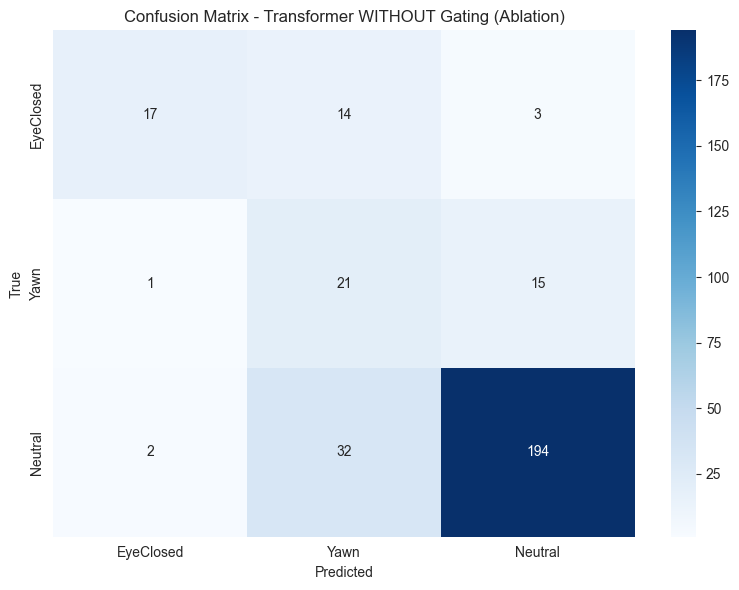


CLASSIFICATION REPORT (No-Gating Ablation) - VAL SET
              precision    recall  f1-score   support

   EyeClosed     0.7143    0.2941    0.4167        17
        Yawn     0.3714    0.7222    0.4906        18
     Neutral     0.8878    0.8286    0.8571       105

    accuracy                         0.7500       140
   macro avg     0.6578    0.6150    0.5881       140
weighted avg     0.8003    0.7500    0.7565       140



In [ ]:

# # ============================================================================
# # CLASSIFICATION REPORT - TEST SET
# # ============================================================================

# print("\n" + "=" * 70)
# print("CLASSIFICATION REPORT (No-Gating Ablation) - TEST SET")
# print("=" * 70)

# print(classification_report(
#     test_results_no_gating['labels'], 
#     test_results_no_gating['predictions'],
#     target_names=class_names,
#     digits=4
# ))

# # ============================================================================
# # CONFUSION MATRIX - TEST SET
# # ============================================================================

# print("\n" + "=" * 70)
# print("CONFUSION MATRIX (No-Gating Ablation) - TEST SET")
# print("=" * 70)

# cm = confusion_matrix(
#     test_results_no_gating['labels'], 
#     test_results_no_gating['predictions']
# )
# print(cm)

# # ============================================================================
# # PLOT CONFUSION MATRIX
# # ============================================================================

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_names,
#             yticklabels=class_names)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix - Transformer WITHOUT Gating (Ablation)')
# plt.tight_layout()
# plt.savefig('confusion_matrix_no_gating_ablation.png', dpi=150)
# plt.show()

# # ============================================================================
# # ALSO DO FOR VALIDATION SET (optional)
# # ============================================================================

# print("\n" + "=" * 70)
# print("CLASSIFICATION REPORT (No-Gating Ablation) - VAL SET")
# print("=" * 70)

# print(classification_report(
#     val_results_no_gating['labels'], 
#     val_results_no_gating['predictions'],
#     target_names=class_names,
#     digits=4
# ))

In [91]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class EnhancedOcclusionAwareTransformer(nn.Module):
    """
    Enhanced transformer with:
    - Multi-layer attention
    - Relative positional encoding
    - Temperature-scaled attention
    - Better pooling mechanism
    """
    
    def __init__(self, feature_dim=512, hidden_dim=128, num_heads=4, num_classes=3, 
                 num_layers=2, use_relative_pos=True):
        super().__init__()
        
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.num_classes = num_classes
        self.num_regions = 4
        self.num_layers = num_layers
        self.use_relative_pos = use_relative_pos
        
        print(f"🏗️ Building ENHANCED Occlusion-Aware Transformer")
        print(f"  📏 Feature dim: {feature_dim} → Hidden dim: {hidden_dim}")
        print(f"  🧠 Heads: {num_heads}, Layers: {num_layers}")
        print(f"  🎯 Regions: {self.num_regions}, Classes: {num_classes}")
        print(f"  🔧 Relative positional encoding: {use_relative_pos}")
        
        # 1. Feature projection layers (keep existing)
        self.feature_projectors = nn.ModuleDict({
            'face': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'left_eye': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'right_eye': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'mouth': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            )
        })
        
        # 2. Occlusion gates (keep existing)
        self.occlusion_gates = nn.ModuleDict({
            'eye_gate': nn.Sequential(
                nn.Linear(1, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
                nn.Sigmoid()
            ),
            'mouth_gate': nn.Sequential(
                nn.Linear(1, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
                nn.Sigmoid()
            )
        })
        
        # 3. ✨ Enhanced positional embeddings
        if use_relative_pos:
            self.pos_encoding = self._create_sinusoidal_embeddings(
                self.num_regions, hidden_dim
            )
        else:
            self.pos_embedding = nn.Embedding(self.num_regions, hidden_dim)
        
        # 4. Region type embeddings
        self.region_type_embedding = nn.Embedding(3, hidden_dim)
        
        # 5. ✨ Multi-layer transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-norm for stability
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(hidden_dim)
        )
        
        # 6. ✨ Learnable query token for attention pooling
        self.query_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        nn.init.xavier_uniform_(self.query_token)
        
        # 7. ✨ Cross-attention for pooling
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )
        self.pool_norm = nn.LayerNorm(hidden_dim)
        
        # 8. ✨ Temperature scaling
        self.attention_temperature = nn.Parameter(torch.ones(1) * math.sqrt(hidden_dim // num_heads))
        
        # 9. Classification head with better regularization
        self.state_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
        self._init_weights()
        print(f"✅ Enhanced transformer built!")
        print(f"  📊 Parameters: {sum(p.numel() for p in self.parameters()):,}")
    
    def _create_sinusoidal_embeddings(self, num_positions, d_model):
        """Create sinusoidal positional embeddings"""
        pe = torch.zeros(num_positions, d_model)
        position = torch.arange(0, num_positions, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        
        return nn.Parameter(pe, requires_grad=False)
    
    def _init_weights(self):
        """Initialize weights with Xavier/Kaiming"""
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() > 1:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
    
    def forward(self, features, occlusion_info, return_attention=False):
        device = next(self.parameters()).device
        region_names = ['face', 'left_eye', 'right_eye', 'mouth']
        region_types = [0, 1, 1, 2]
        
        # Helper function (keep existing)
        def to_B512(x):
            if isinstance(x, (list, tuple)):
                stacked = []
                for t in x:
                    if torch.is_tensor(t):
                        stacked.append(t)
                    else:
                        stacked.append(torch.tensor(t, dtype=torch.float32))
                x = torch.stack(stacked, dim=0)
            elif not torch.is_tensor(x):
                x = torch.tensor(x, dtype=torch.float32)
            if x.dim() == 1:
                x = x.unsqueeze(0)
            return x
        
        # Get batch size and project features
        batch_size = None
        region_feats = {}
        for region in region_names:
            feat = to_B512(features[region])
            if batch_size is None:
                batch_size = feat.shape[0]
            region_feats[region] = feat.to(device)
        
        # Project features
        projected_features = []
        for region in region_names:
            proj_feat = self.feature_projectors[region](region_feats[region])
            projected_features.append(proj_feat)
        
        token_sequence = torch.stack(projected_features, dim=1)  # [B, 4, H]
        
        # ✨ Enhanced positional encoding
        if self.use_relative_pos:
            pos_emb = self.pos_encoding.unsqueeze(0).expand(batch_size, -1, -1)
        else:
            positions = torch.arange(self.num_regions, device=device)
            pos_emb = self.pos_embedding(positions).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Region type embeddings
        region_type_ids = torch.tensor(region_types, device=device)
        type_emb = self.region_type_embedding(region_type_ids).unsqueeze(0).expand(batch_size, -1, -1)
        
        token_sequence = token_sequence + pos_emb + type_emb
        
        # Extract occlusion probabilities
        def _extract_occ_probs(oi, batch_size, device):
            if isinstance(oi, dict):
                eye_prob = oi.get('eye_occlusion_prob', 0.0)
                mouth_prob = oi.get('mouth_occlusion_prob', 0.0)
                if torch.is_tensor(eye_prob):
                    eye_prob = eye_prob.to(device).view(-1)
                    if eye_prob.size(0) == 1 and batch_size > 1:
                        eye_prob = eye_prob.expand(batch_size)
                else:
                    eye_prob = torch.full((batch_size,), float(eye_prob), device=device)
                if torch.is_tensor(mouth_prob):
                    mouth_prob = mouth_prob.to(device).view(-1)
                    if mouth_prob.size(0) == 1 and batch_size > 1:
                        mouth_prob = mouth_prob.expand(batch_size)
                else:
                    mouth_prob = torch.full((batch_size,), float(mouth_prob), device=device)
                return eye_prob, mouth_prob
            return torch.zeros(batch_size, device=device), torch.zeros(batch_size, device=device)
        
        eye_occ_probs, mouth_occ_probs = _extract_occ_probs(occlusion_info, batch_size, device)
        
        # Apply occlusion gates
        eye_gates = self.occlusion_gates['eye_gate'](eye_occ_probs.unsqueeze(1)).squeeze(1)
        mouth_gates = self.occlusion_gates['mouth_gate'](mouth_occ_probs.unsqueeze(1)).squeeze(1)
        
        face_gates = torch.ones(batch_size, device=device)
        left_eye_gates = 0.3 + 0.7 * eye_gates
        right_eye_gates = 0.3 + 0.7 * eye_gates
        mouth_gates_final = 0.3 + 0.7 * mouth_gates
        
        gated_tokens = token_sequence.clone()
        gated_tokens[:, 0, :] *= face_gates.unsqueeze(1)
        gated_tokens[:, 1, :] *= left_eye_gates.unsqueeze(1)
        gated_tokens[:, 2, :] *= right_eye_gates.unsqueeze(1)
        gated_tokens[:, 3, :] *= mouth_gates_final.unsqueeze(1)
        
        # ✨ Multi-layer transformer encoding
        hidden_states = self.transformer_encoder(gated_tokens)  # [B, 4, 128]
        
        # ✨ Query-based pooling with cross-attention
        query = self.query_token.expand(batch_size, -1, -1)  # [B, 1, 128]
        pooled_state, attention_weights = self.cross_attention(
            query, hidden_states, hidden_states, need_weights=True
        )  # pooled_state: [B, 1, 128], attention_weights: [B, 1, 4]
        
        pooled_state = self.pool_norm(pooled_state.squeeze(1))  # [B, 128]
        attention_weights = attention_weights.squeeze(1)  # [B, 4]
        
        # Classification
        class_logits = self.state_classifier(pooled_state)
        
        # Outputs
        gate_factors_tensor = torch.stack([face_gates, left_eye_gates, right_eye_gates, mouth_gates_final], dim=1)
        
        outputs = {
            'class_logits': class_logits,
            'class_probs': F.softmax(class_logits, dim=-1),
            'predicted_class': torch.argmax(class_logits, dim=-1),
            'attention_weights': attention_weights,  # [B, 4]
            'gate_factors': gate_factors_tensor,
            'hidden_states': hidden_states,
            'pooled_state': pooled_state
        }
        
        return outputs



print("🚀 INITIALIZING ENHANCED TINY OCCLUSION-AWARE TRANSFORMER")
print("="*70)

tiny_transformer = EnhancedOcclusionAwareTransformer(
    feature_dim=512,
    hidden_dim=128,
    num_heads=4,
    num_classes=3,
    num_layers=3,  # ← 3 transformer layers instead of 1
    use_relative_pos=True  # ← Use sinusoidal positional encoding
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tiny_transformer = tiny_transformer.to(device)

print(f"✅ Enhanced transformer ready on {device}!")

🚀 INITIALIZING ENHANCED TINY OCCLUSION-AWARE TRANSFORMER
🏗️ Building ENHANCED Occlusion-Aware Transformer
  📏 Feature dim: 512 → Hidden dim: 128
  🧠 Heads: 4, Layers: 3
  🎯 Regions: 4, Classes: 3
  🔧 Relative positional encoding: True
✅ Enhanced transformer built!
  📊 Parameters: 935,878
✅ Enhanced transformer ready on cpu!


 ### TinyTransformer Trainer  

In [92]:
import torch
import torch.nn as nn
import numpy as np

class TinyTransformerTrainer:
    """
    Trainer with batch-safe logging and device movement for nested structures
    """
    def __init__(self, model, device='cpu', learning_rate=3e-5):
        self.model = model.to(device)
        self.device = device

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=learning_rate, weight_decay=1e-4, betas=(0.9, 0.999)
        )
        # self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        #     self.optimizer, T_0=15, T_mult=2, eta_min=1e-6
        # )

        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        self.optimizer, T_max=20, eta_min=1e-6)
        self.classification_criterion = nn.CrossEntropyLoss()

        #self.loss_weights = {'classification': 1.0, 'regularization': 0.02}
        self.loss_weights = {'classification': 1.0, 'gate_occ': 0.1, 'gate_div': 0.01}
        self.history = {'epoch_losses': [], 'classification_losses': [], 'accuracies': [], 'learning_rates': []}

        print(f" TinyTransformerTrainer initialized on {device}")

    def _move_batch_to_device(self, batch):
        def to_dev(x):
            if isinstance(x, torch.Tensor):
                # Ensure float32 dtype for all float tensors
                if x.dtype == torch.float64:
                    x = x.float()
                return x.to(self.device)
            if isinstance(x, dict):
                return {k: to_dev(v) for k, v in x.items()}
            if isinstance(x, (list, tuple)):
                return type(x)(to_dev(v) for v in x)
            if isinstance(x, (float, int, np.number)):
                return torch.tensor(x, dtype=torch.float32, device=self.device)
            return x
        
        out = {}
        for k, v in batch.items():
            if k == 'features' and isinstance(v, dict):
                out[k] = {r: to_dev(t) for r, t in v.items()}
            else:
                out[k] = to_dev(v)
        return out

    # def _compute_losses(self, outputs, batch):
    #     labels = batch['label'].view(-1)
    #     # Ensure labels are long for CrossEntropyLoss
    #     if labels.dtype != torch.long:
    #         labels = labels.long()
        
    #     class_loss = self.classification_criterion(outputs['class_logits'], labels)
    #     gate_factors = outputs['gate_factors']  # [B, 4]
    #     gate_diversity = torch.var(gate_factors, dim=1).mean()
    #     gate_reg_loss = -gate_diversity
    #     total_loss = self.loss_weights['classification'] * class_loss + self.loss_weights['regularization'] * gate_reg_loss
    #     return {'total_loss': total_loss, 'classification_loss': class_loss, 'gate_reg_loss': gate_reg_loss}

    def _compute_losses(self, outputs, batch):
        labels = batch['label'].view(-1)
        if labels.dtype != torch.long:
            labels = labels.long()

        class_loss = self.classification_criterion(outputs['class_logits'], labels)

        # Gate factors [B,4]: [face, left_eye, right_eye, mouth]
        gate_factors = outputs['gate_factors']
        left_eye_g  = gate_factors[:, 1]
        right_eye_g = gate_factors[:, 2]
        mouth_g     = gate_factors[:, 3]

        # Occlusion targets from batch (shape [B,2]: [eye_prob, mouth_prob])
        occ = batch.get('occlusion_targets', None)
        if isinstance(occ, torch.Tensor):
            eye_prob   = occ[:, 0].clamp(0, 1)
            mouth_prob = occ[:, 1].clamp(0, 1)
            # Match the 0.3 floor used in forward: target = 0.3 + 0.7*(1 - prob)
            eye_target   = 0.3 + 0.7 * (1.0 - eye_prob)
            mouth_target = 0.3 + 0.7 * (1.0 - mouth_prob)
            gate_occ_reg = F.mse_loss(left_eye_g, eye_target) + F.mse_loss(right_eye_g, eye_target) + F.mse_loss(mouth_g, mouth_target)
        else:
            gate_occ_reg = torch.tensor(0.0, device=self.device)

        # Keep a small diversity term if you like
        gate_diversity = torch.var(gate_factors, dim=1).mean()
        gate_div_reg = -gate_diversity

        total_loss = (self.loss_weights['classification'] * class_loss
            + self.loss_weights['gate_occ'] * gate_occ_reg
            + self.loss_weights['gate_div'] * gate_div_reg
        )
        return {
            'total_loss': total_loss,
            'classification_loss': class_loss,
            'gate_occ_reg': gate_occ_reg,
            'gate_div_reg': gate_div_reg
        }

    def train_epoch(self, train_loader, epoch):
        self.model.train()
        epoch_losses, epoch_class_losses = [], []
        correct_predictions, total_predictions = 0, 0

        print(f"\n EPOCH {epoch + 1} TRAINING")
        for batch_idx, batch in enumerate(train_loader):
            try:
                batch = self._move_batch_to_device(batch)
                self.optimizer.zero_grad(set_to_none=True)
                outputs = self.model(batch['features'], batch['occlusion_info'] )
                losses = self._compute_losses(outputs, batch)
                total_loss = losses['total_loss']
                
                if torch.isnan(total_loss) or torch.isinf(total_loss):
                    print(f" Invalid loss at batch {batch_idx}, skipping...")
                    continue
                    
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                
                epoch_losses.append(total_loss.item())
                epoch_class_losses.append(losses['classification_loss'].item())

                pred = outputs['predicted_class'].view(-1)
                labels = batch['label'].view(-1)
                correct_predictions += (pred == labels).sum().item()
                total_predictions += labels.size(0)
                
                if (batch_idx + 1) % max(1, len(train_loader) // 3) == 0 or batch_idx == len(train_loader) - 1:
                    print(f"  Batch {batch_idx + 1}/{len(train_loader)} "
                          f"Loss={total_loss.item():.4f} Class={losses['classification_loss'].item():.4f}")
            except Exception as e:
                print(f" Error in batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()

        self.scheduler.step()

        if epoch_losses:
            avg_loss = float(np.mean(epoch_losses))
            avg_class_loss = float(np.mean(epoch_class_losses))
            accuracy = correct_predictions / max(total_predictions, 1) * 100
            lr = self.optimizer.param_groups[0]['lr']
            self.history['epoch_losses'].append(avg_loss)
            self.history['classification_losses'].append(avg_class_loss)
            self.history['accuracies'].append(accuracy)
            self.history['learning_rates'].append(lr)
            print(f"\n Epoch {epoch + 1}: Loss={avg_loss:.4f} Class={avg_class_loss:.4f} Acc={accuracy:.1f}% LR={lr:.2e}")
            return {'avg_loss': avg_loss, 'accuracy': accuracy, 'class_loss': avg_class_loss}
        return {'avg_loss': float('inf'), 'accuracy': 0.0, 'class_loss': float('inf')}

    def evaluate(self, loader, name="VAL"):
        self.model.eval()
        print(f"\n DETAILED EVALUATION [{name}]")
        all_preds, all_labels = [], []
        with torch.no_grad():
            for i, batch in enumerate(loader):
                batch = self._move_batch_to_device(batch)
                outputs = self.model(batch['features'], batch['occlusion_info'], return_attention=True)

                pred = outputs['predicted_class'].view(-1).detach().cpu().numpy()
                labels = batch['label'].view(-1).detach().cpu().numpy()
                all_preds.extend(pred.tolist())
                all_labels.extend(labels.tolist())

                # brief per-batch preview
                probs = outputs['class_probs'].detach().cpu().numpy()
                gates = outputs['gate_factors'].detach().cpu().numpy()
                attn = outputs['attention_weights'].detach().cpu().numpy()
                j = 0
                if len(pred) > 0:
                    cname = batch['class_name'][j] if isinstance(batch['class_name'], list) else str(batch['class_name'])
                    conf = float(probs[j][int(pred[j])])
                    print(f"  Sample {i+1}-1 ({cname}): pred={int(pred[j])} conf={conf:.3f} gates={np.round(gates[j],2)}")

        acc = float(np.mean(np.array(all_preds) == np.array(all_labels)) * 100) if all_labels else 0.0
        print(f" OVERALL ACCURACY: {acc:.1f}%")
        return {'accuracy': acc, 'predictions': all_preds, 'labels': all_labels}

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np

# class TinyTransformerTrainer:
#     """
#     Trainer with batch-safe logging and device movement for nested structures
#     """
#     def __init__(self, model, device='cpu', learning_rate=3e-5):
#         self.model = model.to(device)
#         self.device = device

#         self.optimizer = torch.optim.AdamW(
#             model.parameters(), lr=learning_rate, weight_decay=1e-4, betas=(0.9, 0.999)
#         )
#         # self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#         #     self.optimizer, T_0=15, T_mult=2, eta_min=1e-6
#         # )

#         self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#         self.optimizer, T_max=20, eta_min=1e-6)
#         self.classification_criterion = nn.CrossEntropyLoss()

#         #self.loss_weights = {'classification': 1.0, 'regularization': 0.02}
#         self.loss_weights = {'classification': 1.0, 'gate_occ': 0.1, 'gate_div': 0.01}
#         self.history = {'epoch_losses': [], 'classification_losses': [], 'accuracies': [], 'learning_rates': []}

#         print(f" TinyTransformerTrainer initialized on {device}")

#     def _move_batch_to_device(self, batch):
#         def to_dev(x):
#             if isinstance(x, torch.Tensor):
#                 # Ensure float32 dtype for all float tensors
#                 if x.dtype == torch.float64:
#                     x = x.float()
#                 return x.to(self.device)
#             if isinstance(x, dict):
#                 return {k: to_dev(v) for k, v in x.items()}
#             if isinstance(x, (list, tuple)):
#                 return type(x)(to_dev(v) for v in x)
#             if isinstance(x, (float, int, np.number)):
#                 return torch.tensor(x, dtype=torch.float32, device=self.device)
#             return x
        
#         out = {}
#         for k, v in batch.items():
#             if k == 'features' and isinstance(v, dict):
#                 out[k] = {r: to_dev(t) for r, t in v.items()}
#             else:
#                 out[k] = to_dev(v)
#         return out

#     # def _compute_losses(self, outputs, batch):
#     #     labels = batch['label'].view(-1)
#     #     # Ensure labels are long for CrossEntropyLoss
#     #     if labels.dtype != torch.long:
#     #         labels = labels.long()
        
#     #     class_loss = self.classification_criterion(outputs['class_logits'], labels)
#     #     gate_factors = outputs['gate_factors']  # [B, 4]
#     #     gate_diversity = torch.var(gate_factors, dim=1).mean()
#     #     gate_reg_loss = -gate_diversity
#     #     total_loss = self.loss_weights['classification'] * class_loss + self.loss_weights['regularization'] * gate_reg_loss
#     #     return {'total_loss': total_loss, 'classification_loss': class_loss, 'gate_reg_loss': gate_reg_loss}

#     def _compute_losses(self, outputs, batch):
#         labels = batch['label'].view(-1)
#         if labels.dtype != torch.long:
#             labels = labels.long()

#         class_loss = self.classification_criterion(outputs['class_logits'], labels)

#         # Gate factors [B,4]: [face, left_eye, right_eye, mouth]
#         gate_factors = outputs['gate_factors']
#         left_eye_g  = gate_factors[:, 1]
#         right_eye_g = gate_factors[:, 2]
#         mouth_g     = gate_factors[:, 3]

#         # Occlusion targets from batch (shape [B,2]: [eye_prob, mouth_prob])
#         occ = batch.get('occlusion_targets', None)
#         if isinstance(occ, torch.Tensor):
#             eye_prob   = occ[:, 0].clamp(0, 1)
#             mouth_prob = occ[:, 1].clamp(0, 1)
#             # Match the 0.3 floor used in forward: target = 0.3 + 0.7*(1 - prob)
#             eye_target   = 0.3 + 0.7 * (1.0 - eye_prob)
#             mouth_target = 0.3 + 0.7 * (1.0 - mouth_prob)
#             gate_occ_reg = F.mse_loss(left_eye_g, eye_target) + F.mse_loss(right_eye_g, eye_target) + F.mse_loss(mouth_g, mouth_target)
#         else:
#             gate_occ_reg = torch.tensor(0.0, device=self.device)

#         # Keep a small diversity term if you like
#         gate_diversity = torch.var(gate_factors, dim=1).mean()
#         gate_div_reg = -gate_diversity

#         total_loss = (self.loss_weights['classification'] * class_loss
#             + self.loss_weights['gate_occ'] * gate_occ_reg
#             + self.loss_weights['gate_div'] * gate_div_reg
#         )
#         return {
#             'total_loss': total_loss,
#             'classification_loss': class_loss,
#             'gate_occ_reg': gate_occ_reg,
#             'gate_div_reg': gate_div_reg
#         }

#     def train_epoch(self, train_loader, epoch):
#         self.model.train()
#         epoch_losses, epoch_class_losses = [], []
#         epoch_class_loss = 0.0  # ← INITIALIZE
#         epoch_gate_loss = 0.0   # ← INITIALIZE
#         correct_predictions, total_predictions = 0, 0

#         print(f"\n EPOCH {epoch + 1} TRAINING")
#         for batch_idx, batch in enumerate(train_loader):
#             try:
#                 batch = self._move_batch_to_device(batch)
#                 self.optimizer.zero_grad(set_to_none=True)
                
#                 # Forward pass with gate loss
#                 outputs = self.model(batch['features'], batch['occlusion_info'], return_gate_loss=True)
#                 losses = self._compute_losses(outputs, batch)
#                 class_loss = losses['classification_loss']
                
#                 # Gate diversity loss (only during training)
#                 if self.model.training and 'gate_diversity_loss' in outputs:
#                     gate_diversity_loss = outputs['gate_diversity_loss']
#                     total_loss = class_loss + self.model.gate_diversity_weight * gate_diversity_loss
                    
#                     # Log both losses
#                     epoch_class_loss += class_loss.item()
#                     epoch_gate_loss += gate_diversity_loss.item()
#                 else:
#                     total_loss = class_loss
#                     epoch_class_loss += class_loss.item()  # Still track class loss
                
#                 if torch.isnan(total_loss) or torch.isinf(total_loss):
#                     print(f" Invalid loss at batch {batch_idx}, skipping...")
#                     continue
                    
#                 total_loss.backward()
#                 torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
#                 self.optimizer.step()
                
#                 epoch_losses.append(total_loss.item())
#                 epoch_class_losses.append(class_loss.item())

#                 pred = outputs['predicted_class'].view(-1)
#                 labels = batch['label'].view(-1)
#                 correct_predictions += (pred == labels).sum().item()
#                 total_predictions += labels.size(0)
                
#                 if (batch_idx + 1) % max(1, len(train_loader) // 3) == 0 or batch_idx == len(train_loader) - 1:
#                     if self.model.training and 'gate_diversity_loss' in outputs:
#                         print(f"  Batch {batch_idx + 1}/{len(train_loader)} "
#                             f"Loss={total_loss.item():.4f} Class={class_loss.item():.4f} "
#                             f"Gate={gate_diversity_loss.item():.4f}")
#                     else:
#                         print(f"  Batch {batch_idx + 1}/{len(train_loader)} "
#                             f"Loss={total_loss.item():.4f} Class={class_loss.item():.4f}")
                            
#             except Exception as e:
#                 print(f" Error in batch {batch_idx}: {e}")
#                 import traceback
#                 traceback.print_exc()

#         self.scheduler.step()

#         if epoch_losses:
#             avg_loss = float(np.mean(epoch_losses))
#             avg_class_loss = float(np.mean(epoch_class_losses))
#             accuracy = correct_predictions / max(total_predictions, 1) * 100
#             lr = self.optimizer.param_groups[0]['lr']
            
#             self.history['epoch_losses'].append(avg_loss)
#             self.history['classification_losses'].append(avg_class_loss)
#             self.history['accuracies'].append(accuracy)
#             self.history['learning_rates'].append(lr)
            
#             # Optional: Log gate loss if it was computed
#             if epoch_gate_loss > 0:
#                 avg_gate_loss = epoch_gate_loss / len(train_loader)
#                 print(f"\n Epoch {epoch + 1}: Loss={avg_loss:.4f} Class={avg_class_loss:.4f} "
#                     f"Gate={avg_gate_loss:.6f} Acc={accuracy:.1f}% LR={lr:.2e}")
#             else:
#                 print(f"\n Epoch {epoch + 1}: Loss={avg_loss:.4f} Class={avg_class_loss:.4f} "
#                     f"Acc={accuracy:.1f}% LR={lr:.2e}")
                    
#             return {'avg_loss': avg_loss, 'accuracy': accuracy, 'class_loss': avg_class_loss}
#         return {'avg_loss': float('inf'), 'accuracy': 0.0, 'class_loss': float('inf')}
        
#     def evaluate(self, loader, name="VAL"):
#         self.model.eval()
#         print(f"\n DETAILED EVALUATION [{name}]")
#         all_preds, all_labels = [], []
#         with torch.no_grad():
#             for i, batch in enumerate(loader):
#                 batch = self._move_batch_to_device(batch)
#                 outputs = self.model(batch['features'], batch['occlusion_info'], return_attention=True)

#                 pred = outputs['predicted_class'].view(-1).detach().cpu().numpy()
#                 labels = batch['label'].view(-1).detach().cpu().numpy()
#                 all_preds.extend(pred.tolist())
#                 all_labels.extend(labels.tolist())

#                 # brief per-batch preview
#                 probs = outputs['class_probs'].detach().cpu().numpy()
#                 gates = outputs['gate_factors'].detach().cpu().numpy()
#                 attn = outputs['attention_weights'].detach().cpu().numpy()
#                 j = 0
#                 if len(pred) > 0:
#                     cname = batch['class_name'][j] if isinstance(batch['class_name'], list) else str(batch['class_name'])
#                     conf = float(probs[j][int(pred[j])])
#                     print(f"  Sample {i+1}-1 ({cname}): pred={int(pred[j])} conf={conf:.3f} gates={np.round(gates[j],2)}")

#         acc = float(np.mean(np.array(all_preds) == np.array(all_labels)) * 100) if all_labels else 0.0
#         print(f" OVERALL ACCURACY: {acc:.1f}%")
#         return {'accuracy': acc, 'predictions': all_preds, 'labels': all_labels}

In [50]:
def analyze_gate_dynamics(model, dataloader, device):
    """Analyze how dynamic the gates are"""
    all_gates = []
    all_labels = []
    
    model.eval()
    # model.evaluate(dataloader) # added to test ablation model
    with torch.no_grad():
        for batch in dataloader:
            features = {k: v.to(device) for k, v in batch['features'].items()}
            occlusion_info = {
                k: v.to(device) for k, v in batch['occlusion_info'].items()
            }
            labels = batch['label'].to(device)
            
            outputs = model(features, occlusion_info)
            # outputs = model.model(features, occlusion_info) # added to test ablation model
            
            all_gates.append(outputs['gate_factors'].cpu())
            all_labels.append(labels.cpu())
    
    all_gates = torch.cat(all_gates, dim=0)  # [N, 4]
    all_labels = torch.cat(all_labels, dim=0)  # [N]
    
    # Statistics
    print("\n" + "="*80)
    print("🎯 GATE DYNAMICS ANALYSIS")
    print("="*80)
    
    # Overall statistics
    print(f"\n📊 Overall Gate Statistics:")
    print(f"  Mean: {all_gates.mean():.4f}")
    print(f"  Std:  {all_gates.std():.4f}")
    print(f"  Min:  {all_gates.min():.4f}")
    print(f"  Max:  {all_gates.max():.4f}")
    
    # Per-region statistics
    region_names = ['face', 'left_eye', 'right_eye', 'mouth']
    print(f"\n📍 Per-Region Gate Statistics:")
    for i, region in enumerate(region_names):
        region_gates = all_gates[:, i]
        print(f"  {region:12s}: mean={region_gates.mean():.4f}, "
              f"std={region_gates.std():.4f}, "
              f"range=[{region_gates.min():.4f}, {region_gates.max():.4f}]")
    
    # Per-class statistics
    print(f"\n🏷️ Per-Class Gate Statistics:")
    class_names = ['EyeClosed', 'Yawn', 'Neutral']
    for class_idx, class_name in enumerate(class_names):
        mask = all_labels == class_idx
        if mask.sum() > 0:
            class_gates = all_gates[mask]
            print(f"  {class_name:12s}: {class_gates.mean(dim=0).numpy()}")
    
    # Gate variance (key metric for dynamics)
    region_variance = all_gates.var(dim=1).mean()
    sample_variance = all_gates.var(dim=0).mean()
    print(f"\n📈 Gate Diversity Metrics:")
    print(f"  Variance across regions (per sample): {region_variance:.6f}")
    print(f"  Variance across samples (per region): {sample_variance:.6f}")
    print(f"  Total diversity score: {(region_variance + sample_variance):.6f}")
    
    # Learnable parameters
    gate_bounds = outputs['gate_components']['bounds']
    gate_temp = outputs['gate_components']['temperature']
    print(f"\n⚙️ Learned Gate Parameters:")
    print(f"  Bounds: [{gate_bounds[0]:.4f}, {gate_bounds[1]:.4f}]")
    print(f"  Temperature: {gate_temp:.4f}")
    
    print("="*80 + "\n")
    
    return all_gates, all_labels

# Usage: Add this to your evaluation cells 
# train_gates, train_labels = analyze_gate_dynamics(ablation_trainer, train_loader, device)
# test_gates, test_labels = analyze_gate_dynamics(ablation_trainer, test_loader, device)


train_gates, train_labels = analyze_gate_dynamics(tiny_transformer, train_loader, device)
test_gates, test_labels = analyze_gate_dynamics(tiny_transformer, test_loader, device)


🎯 GATE DYNAMICS ANALYSIS

📊 Overall Gate Statistics:
  Mean: 0.7376
  Std:  0.1515
  Min:  0.6497
  Max:  1.0000

📍 Per-Region Gate Statistics:
  face        : mean=1.0000, std=0.0000, range=[1.0000, 1.0000]
  left_eye    : mean=0.6500, std=0.0000, range=[0.6497, 0.6500]
  right_eye   : mean=0.6500, std=0.0000, range=[0.6497, 0.6500]
  mouth       : mean=0.6503, std=0.0004, range=[0.6500, 0.6553]

🏷️ Per-Class Gate Statistics:
  EyeClosed   : [1.         0.64994484 0.64994484 0.6502708 ]
  Yawn        : [1.         0.64998114 0.64998114 0.65045947]
  Neutral     : [1.         0.6499813  0.6499813  0.65030766]

📈 Gate Diversity Metrics:
  Variance across regions (per sample): 0.030609
  Variance across samples (per region): 0.000000
  Total diversity score: 0.030609


KeyError: 'gate_components'

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gate_analysis(gates, labels, title="Gate Analysis"):
    """Visualize gate distributions and patterns"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    class_names = ['EyeClosed', 'Yawn', 'Neutral']
    
    # 1. Gate distributions per region
    ax = axes[0, 0]
    for i, region in enumerate(region_names):
        ax.hist(gates[:, i].numpy(), bins=30, alpha=0.5, label=region)
    ax.set_xlabel('Gate Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Gate Value Distributions by Region')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Gate patterns per class
    ax = axes[0, 1]
    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_gates = gates[mask].mean(dim=0).numpy()
            ax.plot(region_names, class_gates, marker='o', label=class_name, linewidth=2)
    ax.set_ylabel('Mean Gate Value')
    ax.set_title('Gate Patterns by Class')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Heatmap of gates (sample subset)
    ax = axes[1, 0]
    n_samples = min(50, len(gates))
    im = ax.imshow(gates[:n_samples].T, aspect='auto', cmap='RdYlGn')
    ax.set_yticks(range(4))
    ax.set_yticklabels(region_names)
    ax.set_xlabel('Sample Index')
    ax.set_title(f'Gate Heatmap (First {n_samples} Samples)')
    plt.colorbar(im, ax=ax)
    
    # 4. Gate variance scatter
    ax = axes[1, 1]
    gate_variance = gates.var(dim=1).numpy()
    gate_mean = gates.mean(dim=1).numpy()
    scatter = ax.scatter(gate_mean, gate_variance, c=labels.numpy(), 
                        cmap='viridis', alpha=0.6, s=30)
    ax.set_xlabel('Mean Gate Value')
    ax.set_ylabel('Gate Variance')
    ax.set_title('Gate Diversity (variance vs mean)')
    plt.colorbar(scatter, ax=ax, label='Class')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Usage
plot_gate_analysis(train_gates, train_labels, "Training Set Gate Analysis")
plot_gate_analysis(test_gates, test_labels, "Test Set Gate Analysis")

NameError: name 'train_gates' is not defined

In [36]:
# ============================================================================
# GATE VISUALIZATION FOR T-IV PAPER
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import defaultdict

# Set publication-quality style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif'
})

# ============================================================================
# 1. COLLECT GATE VALUES FROM YOUR MODEL
# ============================================================================

def collect_gate_statistics(model, dataloader, device):
    """
    Collect gate values across the dataset, grouped by class and occlusion state.
    """
    model.eval()
    
    # Storage
    gate_by_class = defaultdict(list)       # {class_name: [gate_values]}
    gate_by_occlusion = {
        'clean': [],           # No occlusion
        'eyes_occluded': [],   # Eyes occluded
        'mouth_occluded': [],  # Mouth occluded
        'both_occluded': []    # Both occluded
    }
    all_gates = []
    all_attention = []
    
    with torch.no_grad():
        for batch in dataloader:
            # Move to device
            features = {k: v.to(device) if torch.is_tensor(v) else v 
                       for k, v in batch['features'].items()}
            occlusion_info = batch.get('occlusion_info', {})
            if isinstance(occlusion_info, dict):
                occlusion_info = {k: v.to(device) if torch.is_tensor(v) else v 
                                 for k, v in occlusion_info.items()}
            
            # Forward pass
            outputs = model(features, occlusion_info, return_gate_loss=False)
            
            # Extract gate factors [B, 4]
            gates = outputs['gate_factors'].cpu().numpy()
            attention = outputs['attention_weights'].cpu().numpy()
            
            # Get class names and occlusion flags from batch
            class_names = batch.get('class_name', ['unknown'] * gates.shape[0])
            
            # Handle occlusion targets if available
            occ_targets = batch.get('occlusion_targets', None)
            if occ_targets is not None and torch.is_tensor(occ_targets):
                occ_targets = occ_targets.cpu().numpy()
            
            for i in range(gates.shape[0]):
                gate_values = gates[i]  # [4] - face, left_eye, right_eye, mouth
                attn_values = attention[i]
                
                # Store by class
                cname = class_names[i] if isinstance(class_names, list) else str(class_names)
                gate_by_class[cname].append(gate_values)
                
                # Store by occlusion state
                if occ_targets is not None:
                    eye_occ = occ_targets[i, 0] > 0.5
                    mouth_occ = occ_targets[i, 1] > 0.5
                    
                    if eye_occ and mouth_occ:
                        gate_by_occlusion['both_occluded'].append(gate_values)
                    elif eye_occ:
                        gate_by_occlusion['eyes_occluded'].append(gate_values)
                    elif mouth_occ:
                        gate_by_occlusion['mouth_occluded'].append(gate_values)
                    else:
                        gate_by_occlusion['clean'].append(gate_values)
                else:
                    gate_by_occlusion['clean'].append(gate_values)
                
                all_gates.append(gate_values)
                all_attention.append(attn_values)
    
    return {
        'by_class': {k: np.array(v) for k, v in gate_by_class.items()},
        'by_occlusion': {k: np.array(v) if v else np.array([]).reshape(0, 4) 
                        for k, v in gate_by_occlusion.items()},
        'all_gates': np.array(all_gates),
        'all_attention': np.array(all_attention)
    }


# ============================================================================
# 2. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_gates_by_class(gate_stats, save_path='fig_gates_by_class.pdf'):
    """
    Bar chart: Mean gate values per region, grouped by class.
    Great for showing class-dependent gating behavior.
    """
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    class_data = gate_stats['by_class']
    
    # Compute means and stds
    classes = list(class_data.keys())
    n_classes = len(classes)
    n_regions = 4
    
    means = np.zeros((n_classes, n_regions))
    stds = np.zeros((n_classes, n_regions))
    
    for i, cls in enumerate(classes):
        if len(class_data[cls]) > 0:
            means[i] = class_data[cls].mean(axis=0)
            stds[i] = class_data[cls].std(axis=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = np.arange(n_regions)
    width = 0.25
    colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green, Red, Blue
    
    for i, cls in enumerate(classes):
        offset = (i - n_classes/2 + 0.5) * width
        bars = ax.bar(x + offset, means[i], width, 
                     yerr=stds[i], label=cls, color=colors[i % len(colors)],
                     capsize=3, alpha=0.85)
    
    ax.set_xlabel('Region')
    ax.set_ylabel('Gate Value')
    ax.set_title('Dynamic Gate Values by Driver State')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names)
    ax.legend(title='Class')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='No suppression')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_gates_by_occlusion(gate_stats, save_path='fig_gates_by_occlusion.pdf'):
    """
    Bar chart: Mean gate values under different occlusion conditions.
    Shows that gates respond to occlusion.
    """
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    occ_data = gate_stats['by_occlusion']
    
    # Filter conditions with data
    conditions = ['clean', 'eyes_occluded', 'mouth_occluded', 'both_occluded']
    condition_labels = ['Clean', 'Eyes Occluded', 'Mouth Occluded', 'Both Occluded']
    colors = ['#27ae60', '#e67e22', '#9b59b6', '#c0392b']
    
    valid_conditions = []
    valid_labels = []
    valid_colors = []
    
    for cond, label, color in zip(conditions, condition_labels, colors):
        if len(occ_data[cond]) > 0:
            valid_conditions.append(cond)
            valid_labels.append(label)
            valid_colors.append(color)
    
    if len(valid_conditions) == 0:
        print("No occlusion data available for plotting.")
        return
    
    n_conditions = len(valid_conditions)
    n_regions = 4
    
    means = np.zeros((n_conditions, n_regions))
    stds = np.zeros((n_conditions, n_regions))
    
    for i, cond in enumerate(valid_conditions):
        means[i] = occ_data[cond].mean(axis=0)
        stds[i] = occ_data[cond].std(axis=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = np.arange(n_regions)
    width = 0.8 / n_conditions
    
    for i, (cond, label, color) in enumerate(zip(valid_conditions, valid_labels, valid_colors)):
        offset = (i - n_conditions/2 + 0.5) * width
        ax.bar(x + offset, means[i], width, 
               yerr=stds[i], label=label, color=color,
               capsize=3, alpha=0.85)
    
    ax.set_xlabel('Region')
    ax.set_ylabel('Gate Value')
    ax.set_title('Gate Values Under Different Occlusion Conditions')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names)
    ax.legend(title='Condition', loc='upper right')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_gate_distribution_heatmap(gate_stats, save_path='fig_gate_heatmap.pdf'):
    """
    Heatmap: Gate value distribution across regions and classes.
    Compact view for paper figures.
    """
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    class_data = gate_stats['by_class']
    classes = list(class_data.keys())
    
    # Build matrix of mean gate values
    matrix = np.zeros((len(classes), 4))
    for i, cls in enumerate(classes):
        if len(class_data[cls]) > 0:
            matrix[i] = class_data[cls].mean(axis=0)
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(8, 4))
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0.2, vmax=1.0)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Gate Value')
    
    # Labels
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(region_names)
    ax.set_yticks(np.arange(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel('Region')
    ax.set_ylabel('Driver State')
    ax.set_title('Gate Values Heatmap')
    
    # Add value annotations
    for i in range(len(classes)):
        for j in range(4):
            text = ax.text(j, i, f'{matrix[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_gate_vs_attention(gate_stats, save_path='fig_gate_vs_attention.pdf'):
    """
    Scatter plot: Gate values vs Attention weights per region.
    Shows relationship between gating and attention.
    """
    all_gates = gate_stats['all_gates']      # [N, 4]
    all_attention = gate_stats['all_attention']  # [N, 4]
    
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    colors = ['#3498db', '#e74c3c', '#e74c3c', '#9b59b6']
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    
    for i, (ax, region, color) in enumerate(zip(axes, region_names, colors)):
        # Subsample for clarity
        n_samples = min(2000, len(all_gates))
        indices = np.random.choice(len(all_gates), n_samples, replace=False)
        
        ax.scatter(all_gates[indices, i], all_attention[indices, i], 
                   alpha=0.3, s=10, c=color)
        ax.set_xlabel('Gate Value')
        ax.set_ylabel('Attention Weight')
        ax.set_title(region)
        ax.set_xlim(0, 1.1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        
        # Add correlation coefficient
        corr = np.corrcoef(all_gates[:, i], all_attention[:, i])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                fontsize=10, verticalalignment='top')
    
    plt.suptitle('Gate Values vs Attention Weights', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


def plot_gate_boxplot(gate_stats, save_path='fig_gate_boxplot.pdf'):
    """
    Box plot: Gate value distribution per region and class.
    Good for showing variance and outliers.
    """
    region_names = ['Face', 'Left Eye', 'Right Eye', 'Mouth']
    class_data = gate_stats['by_class']
    classes = list(class_data.keys())
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    
    for i, (ax, region) in enumerate(zip(axes, region_names)):
        data_to_plot = []
        labels = []
        
        for cls in classes:
            if len(class_data[cls]) > 0:
                data_to_plot.append(class_data[cls][:, i])
                labels.append(cls)
        
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
        
        colors = ['#2ecc71', '#e74c3c', '#3498db']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(region)
        ax.set_ylabel('Gate Value' if i == 0 else '')
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    
    plt.suptitle('Gate Value Distribution by Region and Class', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ============================================================================
# 3. RUN ALL VISUALIZATIONS
# ============================================================================

# Collect gate statistics from test set
print("Collecting gate statistics from test set...")
gate_stats = collect_gate_statistics(tiny_transformer, test_loader, device)

print(f"\nCollected {len(gate_stats['all_gates'])} samples")
print(f"Classes found: {list(gate_stats['by_class'].keys())}")
print(f"Occlusion conditions: {[(k, len(v)) for k, v in gate_stats['by_occlusion'].items()]}")

# Generate all figures
print("\n" + "=" * 70)
print("GENERATING GATE VISUALIZATION FIGURES")
print("=" * 70)

# Figure 1: Gates by class (most important for paper)
plot_gates_by_class(gate_stats, save_path='fig_gates_by_class.pdf')

# Figure 2: Gates by occlusion condition
plot_gates_by_occlusion(gate_stats, save_path='fig_gates_by_occlusion.pdf')

# Figure 3: Heatmap (compact, good for paper)
plot_gate_distribution_heatmap(gate_stats, save_path='fig_gate_heatmap.pdf')

# Figure 4: Gate vs Attention relationship
plot_gate_vs_attention(gate_stats, save_path='fig_gate_vs_attention.pdf')

# Figure 5: Box plots (shows variance)
plot_gate_boxplot(gate_stats, save_path='fig_gate_boxplot.pdf')

print("\n" + "=" * 70)
print("ALL FIGURES SAVED!")
print("=" * 70)

TypeError: EnhancedOcclusionAwareTransformer.forward() got an unexpected keyword argument 'return_gate_loss'

In [93]:
# Initialize simplified trainer
import torch.nn.functional as F  # ← CRITICAL for F.mse_loss, F.cross_entropy, etc.
if tiny_transformer:
    trainer = TinyTransformerTrainer(
        model=tiny_transformer,
        device=device,
        learning_rate=3e-5  # ← Reduced from 1e-3
    )
    print(" Transformer trainer ready for training!")
else:
    print(" Missing model or dataset for trainer initialization")
    trainer = None

 TinyTransformerTrainer initialized on cpu
 Transformer trainer ready for training!


In [ ]:
# # Initialize simplified trainer
# import torch.nn.functional as F  # ← CRITICAL for F.mse_loss, F.cross_entropy, etc.
# if ablation_model:
#     trainer = TinyTransformerTrainer(
#         model=ablation_model,
#         device=device,
#         learning_rate=3e-5  # ← Reduced from 1e-3
#     )
#     print(" Transformer trainer ready for training!")
# else:
#     print(" Missing model or dataset for trainer initialization")
#     trainer = None

 TinyTransformerTrainer initialized on cpu
 Transformer trainer ready for training!


### Running the Training 

In [94]:
# Visualization Helpers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

import torch

# Helpers
def compute_metrics_on_loader(trainer, loader, compute_loss=True):
    """Return dict(loss, accuracy, precision, recall, f1, preds, labels) on a loader."""
    model = trainer.model
    device = trainer.device
    criterion = trainer.classification_criterion
    model.eval()

    all_preds, all_labels = [], []
    total_loss, n = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            batch = trainer._move_batch_to_device(batch)
            outputs = model(batch['features'], batch['occlusion_info'])
            logits = outputs['class_logits']
            preds = torch.argmax(logits, dim=-1).detach().cpu().numpy()
            labels = batch['label'].view(-1).detach().cpu().numpy()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

            if compute_loss:
                loss = criterion(logits, batch['label'].view(-1))
                total_loss += float(loss.item()) * labels.shape[0]
                n += labels.shape[0]

    acc = accuracy_score(all_labels, all_preds) * 100 if all_labels else 0.0
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    val_loss = (total_loss / max(n, 1)) if compute_loss else None

    return {
        'loss': val_loss,
        'accuracy': acc,
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'preds': all_preds,
        'labels': all_labels,
    }

def plot_curves(train_loss, val_loss, val_acc, val_p=None, val_r=None, val_f1=None, title_suffix=""):
    epochs = np.arange(1, len(train_loss) + 1)

    # 1) Train/Val loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_loss, label='Train loss')
    if val_loss is not None:
        plt.plot(epochs, val_loss, label='Val loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Loss vs Epoch {title_suffix}')
    plt.legend(); plt.grid(True); plt.show()

    # 2) Val accuracy
    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_acc, label='Val accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title(f'Val Accuracy vs Epoch {title_suffix}')
    plt.legend(); plt.grid(True); plt.show()

    # 3) Val precision/recall/F1
    if val_p is not None and val_r is not None and val_f1 is not None:
        plt.figure(figsize=(6,4))
        plt.plot(epochs, val_p,  label='Precision (weighted)')
        plt.plot(epochs, val_r,  label='Recall (weighted)')
        plt.plot(epochs, val_f1, label='F1 (weighted)')
        plt.xlabel('Epoch'); plt.ylabel('Score'); plt.ylim(0, 1.0)
        plt.title(f'Val Precision/Recall/F1 vs Epoch {title_suffix}')


In [96]:
def finetune_tiny_transformer(trainer, train_loader, val_loader,  num_epochs=10, save_model=True, patience=20):
    """
    Fine-tune with proper validation-based model selection and single final test run.

    Args:
        trainer: TinyTransformerTrainer
        train_loader: DataLoader for training
        val_loader:   DataLoader for validation (required)
        test_loader:  DataLoader for test (optional; evaluated once at end)
        num_epochs:   epochs to train
        save_model:   save best checkpoint based on VAL accuracy
        patience:     early stopping patience on VAL accuracy
    """
    if val_loader is None:
        raise ValueError("val_loader is required for proper model selection.")

    print(" STARTING TINY TRANSFORMER FINE-TUNING")
    print(f"Epochs: {num_epochs}, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    train_loss_hist = []
    val_loss_hist   = []
    val_acc_hist    = []
    val_p_hist      = []
    val_r_hist      = []
    val_f1_hist     = []

    best_val, best_epoch = -1.0, 0
    best_checkpoint_path = None

    for epoch in range(num_epochs):
        # Train one epoch (trainer.train_epoch typically steps scheduler internally)
        tr = trainer.train_epoch(train_loader, epoch)
        train_loss_hist.append(tr['avg_loss'])

        # Validate (loss + metrics)
        val_metrics = compute_metrics_on_loader(trainer, val_loader, compute_loss=True)
        val_loss_hist.append(val_metrics['loss'])
        val_acc_hist.append(val_metrics['accuracy'])
        val_p_hist.append(val_metrics['precision'])
        val_r_hist.append(val_metrics['recall'])
        val_f1_hist.append(val_metrics['f1'])

        improved = val_metrics['accuracy'] > best_val
        if improved:
            best_val, best_epoch = val_metrics['accuracy'], epoch + 1
            best_checkpoint_path = f"best_tiny_transformer_epoch_{best_epoch}_{best_val:.1f}.pth"
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': trainer.model.state_dict(),
                'optimizer_state_dict': trainer.optimizer.state_dict(),
                'scheduler_state_dict': trainer.scheduler.state_dict(),
                'val_accuracy': best_val,
                'training_history': trainer.history,
            }, best_checkpoint_path)

            torch.save(trainer.model, best_checkpoint_path.replace(".pth", ".full.pt"))

            print(f"💾 Saved: {best_checkpoint_path}")

        print(f"Epoch {epoch+1}/{num_epochs} "
            f"| TrainLoss {tr['avg_loss']:.4f} "
            f"| ValLoss {val_metrics['loss']:.4f} "
            f"| ValAcc {val_metrics['accuracy']:.1f}% "
            f"| ValF1 {val_metrics['f1']:.3f} "
            f"{'<= BEST' if improved else ''}")

    print(f"\n🏆 Best VAL accuracy: {best_val:.1f}% @ epoch {best_epoch}")
    print(f"💾 Best checkpoint path: {best_checkpoint_path}")

    # Plots at end of training
    plot_curves(
        train_loss=train_loss_hist,
        val_loss=val_loss_hist,
        val_acc=val_acc_hist,
        val_p=val_p_hist,
        val_r=val_r_hist,
        val_f1=val_f1_hist,
        title_suffix=""
    )

    return {
         'best_val_accuracy': best_val,
         'best_epoch': best_epoch,
         'training_history': trainer.history,
          'final_epoch': epoch + 1,
          'best_checkpoint_path': best_checkpoint_path
      }
        


   Starting fine-tuning with proper val selection...
  Train batches: 18  |  Val batches: 5
 STARTING TINY TRANSFORMER FINE-TUNING
Epochs: 20, Train batches: 18, Val batches: 5

 EPOCH 1 TRAINING
  Batch 6/18 Loss=1.5140 Class=1.4798
  Batch 12/18 Loss=0.8305 Class=0.7961
  Batch 18/18 Loss=0.7032 Class=0.6682

 Epoch 1: Loss=1.4839 Class=1.4492 Acc=42.3% LR=2.98e-05
💾 Saved: best_tiny_transformer_epoch_1_75.0.pth
Epoch 1/20 | TrainLoss 1.4839 | ValLoss 0.7700 | ValAcc 75.0% | ValF1 0.643 <= BEST

 EPOCH 2 TRAINING
  Batch 6/18 Loss=1.0470 Class=1.0122
  Batch 12/18 Loss=1.0680 Class=1.0334
  Batch 18/18 Loss=0.8680 Class=0.8327

 Epoch 2: Loss=0.8286 Class=0.7940 Acc=73.8% LR=2.93e-05
Epoch 2/20 | TrainLoss 0.8286 | ValLoss 0.7319 | ValAcc 75.0% | ValF1 0.643 

 EPOCH 3 TRAINING
  Batch 6/18 Loss=0.8704 Class=0.8365
  Batch 12/18 Loss=0.8884 Class=0.8538
  Batch 18/18 Loss=0.6307 Class=0.5964

 Epoch 3: Loss=0.7733 Class=0.7389 Acc=74.5% LR=2.84e-05
Epoch 3/20 | TrainLoss 0.7733 | Val

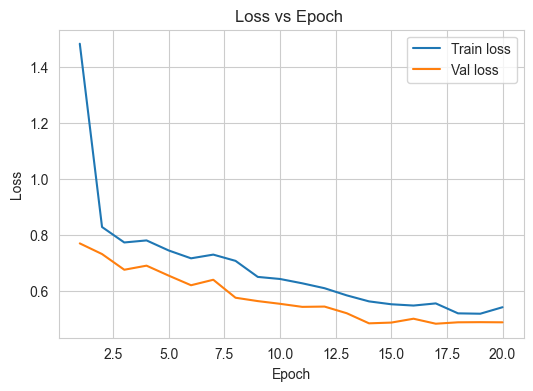

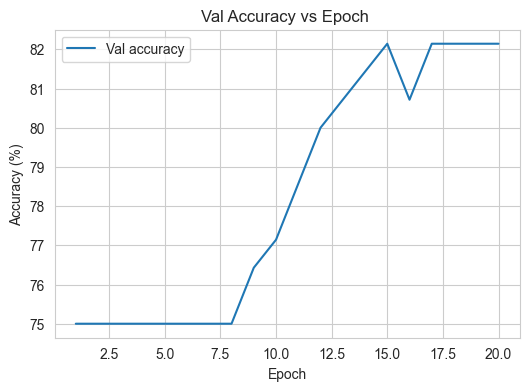


 TRAINING RESULTS:
   Best VAL accuracy: 82.1%
   Best epoch: 15
   Total epochs: 20
   Saved checkpoint: best_tiny_transformer_epoch_15_82.1.pth


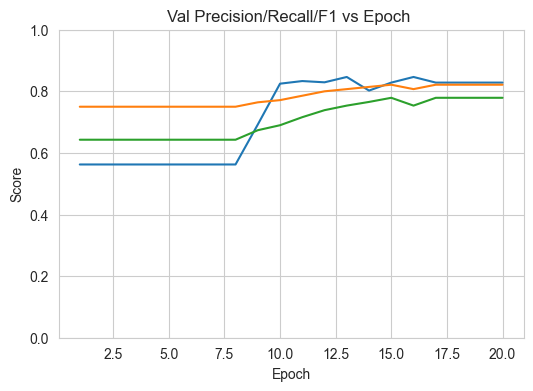

In [97]:
if 'trainer' in locals() and 'train_loader' in locals() and 'val_loader' in locals():
    print("   Starting fine-tuning with proper val selection...")
    print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

    finetune_results = finetune_tiny_transformer(
        trainer=trainer,
        train_loader=train_loader,
        val_loader=val_loader,                     # Validation data
        num_epochs=20,
        save_model=True,
    )


    # Show final results (keys updated)
    print("\n TRAINING RESULTS:")
    print(f"   Best VAL accuracy: {finetune_results['best_val_accuracy']:.1f}%")
    print(f"   Best epoch: {finetune_results['best_epoch']}")
    print(f"   Total epochs: {finetune_results['final_epoch']}")
    if finetune_results.get('best_checkpoint_path'):
        print(f"   Saved checkpoint: {finetune_results['best_checkpoint_path']}")

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _move_batch_to_device(batch):
    def to_dev(x):
        if isinstance(x, torch.Tensor):
            # Ensure float32 dtype for all float tensors
            if x.dtype == torch.float64:
                x = x.float()
            return x.to(device)
        if isinstance(x, dict):
            return {k: to_dev(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)):
            return type(x)(to_dev(v) for v in x)
        if isinstance(x, (float, int, np.number)):
            return torch.tensor(x, dtype=torch.float32, device=device)
        return x
    
    out = {}
    for k, v in batch.items():
        if k == 'features' and isinstance(v, dict):
            out[k] = {r: to_dev(t) for r, t in v.items()}
        else:
            out[k] = to_dev(v)
    return out



def evaluate(model, loader, name="Test"):
    model.eval()
    print(f"\n DETAILED EVALUATION [{name}]")
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = _move_batch_to_device(batch)
            outputs = model(batch['features'], batch['occlusion_info'], return_attention=True)

            pred = outputs['predicted_class'].view(-1).detach().cpu().numpy()
            labels = batch['label'].view(-1).detach().cpu().numpy()
            all_preds.extend(pred.tolist())
            all_labels.extend(labels.tolist())

            # brief per-batch preview
            probs = outputs['class_probs'].detach().cpu().numpy()
            gates = outputs['gate_factors'].detach().cpu().numpy()
            attn = outputs['attention_weights'].detach().cpu().numpy()
            j = 0
            if len(pred) > 0:
                cname = batch['class_name'][j] if isinstance(batch['class_name'], list) else str(batch['class_name'])
                conf = float(probs[j][int(pred[j])])
                print(f"  Sample {i+1}-1 ({cname}): pred={int(pred[j])} conf={conf:.3f} gates={np.round(gates[j],2)}")

    acc = float(np.mean(np.array(all_preds) == np.array(all_labels)) * 100) if all_labels else 0.0
    return {'accuracy': acc, 'predictions': all_preds, 'labels': all_labels}

In [42]:
trained_model = torch.load(finetune_results['best_checkpoint_path'].replace(".pth", ".full.pt"), map_location=device, weights_only=False)

# Single final test evaluation
test_result = None
if test_loader is not None:
    print("\n FINAL TEST EVALUATION:")
    test_result = evaluate(trained_model, test_loader, name="TEST")


print(test_result['accuracy'])



 FINAL TEST EVALUATION:

 DETAILED EVALUATION [TEST]
  Sample 1-1 (Neutral): pred=2 conf=0.573 gates=[1.   0.65 0.65 0.65]
  Sample 2-1 (Neutral): pred=0 conf=0.461 gates=[1.   0.65 0.65 0.65]
  Sample 3-1 (Neutral): pred=0 conf=0.462 gates=[1.   0.65 0.65 0.65]
  Sample 4-1 (Neutral): pred=0 conf=0.445 gates=[1.   0.65 0.65 0.65]
  Sample 5-1 (Yawn): pred=2 conf=0.479 gates=[1.   0.65 0.65 0.65]
  Sample 6-1 (Neutral): pred=2 conf=0.513 gates=[1.   0.65 0.65 0.65]
  Sample 7-1 (Neutral): pred=2 conf=0.514 gates=[1.   0.65 0.65 0.65]
  Sample 8-1 (Neutral): pred=2 conf=0.512 gates=[1.   0.65 0.65 0.65]
  Sample 9-1 (Neutral): pred=2 conf=0.529 gates=[1.   0.65 0.65 0.65]
  Sample 10-1 (Neutral): pred=0 conf=0.482 gates=[1.   0.65 0.65 0.65]
57.333333333333336



📊 TEST: loss=0.9946  acc=57.3%

Classification report (TEST):
              precision    recall  f1-score   support

   EyeClosed      0.099     0.265     0.144        34
        Yawn      0.000     0.000     0.000        38
     Neutral      0.780     0.715     0.746       228

    accuracy                          0.573       300
   macro avg      0.293     0.327     0.297       300
weighted avg      0.604     0.573     0.583       300



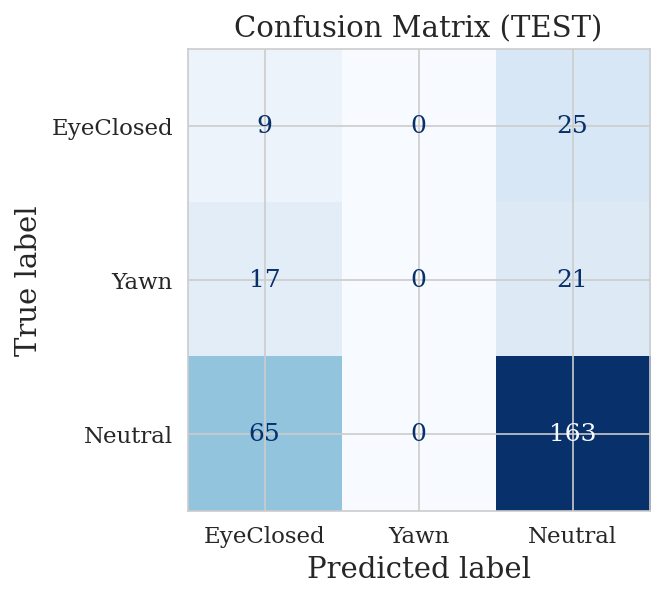

In [43]:
import torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def show_test_report_and_cm(y_true, y_pred, class_names=('EyeClosed','Yawn', 'Neutral')):
    print("\nClassification report (TEST):")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    plt.title('Confusion Matrix (TEST)')
    plt.show()
    
    
# Evaluate on test_loader
if 'test_loader' not in locals() or test_loader is None:
    raise RuntimeError("test_loader must be defined before running this cell.")

def to_dev(x):
    if isinstance(x, torch.Tensor):
        if x.dtype == torch.float64:
            x = x.float()
        return x.to(device)
    if isinstance(x, dict):
        return {k: to_dev(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(to_dev(v) for v in x)
    if isinstance(x, (float, int, np.number)):
        return torch.tensor(x, dtype=torch.float32, device=device)
    return x

criterion = torch.nn.CrossEntropyLoss()
all_preds, all_labels = [], []
total_loss, n = 0.0, 0

with torch.no_grad():
    for batch in test_loader:
        batch_dev = {k: ( {r: to_dev(t) for r, t in v.items()} if k=='features' and isinstance(v, dict) else to_dev(v) )
                     for k, v in batch.items()}
        out = trained_model(batch_dev['features'], batch_dev['occlusion_info'])
        logits = out['class_logits']
        preds = torch.argmax(logits, dim=-1).detach().cpu().numpy()
        labels = batch_dev['label'].view(-1).detach().cpu().numpy()

        all_preds.extend(preds.tolist()); all_labels.extend(labels.tolist())
        loss = criterion(logits, batch_dev['label'].view(-1))
        total_loss += float(loss.item()) * labels.shape[0]; n += labels.shape[0]

test_loss = total_loss / max(n, 1)
test_acc = (np.mean(np.array(all_preds) == np.array(all_labels)) * 100.0) if n > 0 else 0.0
print(f"\n📊 TEST: loss={test_loss:.4f}  acc={test_acc:.1f}%")
show_test_report_and_cm(all_labels, all_preds, class_names=('EyeClosed','Yawn','Neutral'))

In [45]:
# ============================================================================
# LATENCY MEASUREMENT FOR T-IV PAPER
# ============================================================================

import time
import numpy as np

def measure_pipeline_latency(face_detector, feature_extractor, occlusion_detector, 
                             transformer, sample_frames, device, num_runs=100):
    """
    Measure per-component and total pipeline latency.
    Report these numbers in your T-IV paper.
    """
    
    # Warm-up runs
    print("Warming up...")
    for frame in sample_frames[:10]:
        _ = face_detector.detect_face_and_landmarks(frame['image'])
    
    # Latency storage
    latencies = {
        'face_detection': [],
        'feature_extraction': [],
        'occlusion_detection': [],
        'transformer': [],
        'total': []
    }
    
    print(f"Measuring latency over {num_runs} frames...")
    
    for i, frame in enumerate(sample_frames[:num_runs]):
        image = frame['image']
        total_start = time.time()
        
        # 1. Face Detection
        t0 = time.time()
        face_result = face_detector.detect_face_and_landmarks(image)
        latencies['face_detection'].append(time.time() - t0)
        
        if not face_result['is_valid']:
            continue
        
        # 2. Feature Extraction
        t0 = time.time()
        feature_result = feature_extractor.extract_region_features(
            image,
            face_result['face_bbox'],
            face_result['eye_regions'],
            face_result['mouth_region'],
            is_training=False
        )
        latencies['feature_extraction'].append(time.time() - t0)
        
        # 3. Occlusion Detection
        t0 = time.time()
        occ_result = occlusion_detector.analyze_occlusion_and_states(
            image, face_result['landmarks'], face_result['eye_regions'],
            face_result['mouth_region'], face_result['face_bbox'], feature_result
        )
        latencies['occlusion_detection'].append(time.time() - t0)
        
        # 4. Transformer
        t0 = time.time()
        # Prepare features
        features = {
            'face': torch.tensor(feature_result['face_features']).unsqueeze(0).to(device),
            'left_eye': torch.tensor(feature_result['left_eye_features']).unsqueeze(0).to(device),
            'right_eye': torch.tensor(feature_result['right_eye_features']).unsqueeze(0).to(device),
            'mouth': torch.tensor(feature_result['mouth_features']).unsqueeze(0).to(device)
        }
        occlusion_info = occ_result.get('occlusion_analysis', {})
        
        with torch.no_grad():
            _ = transformer(features, occlusion_info)
        latencies['transformer'].append(time.time() - t0)
        
        latencies['total'].append(time.time() - total_start)
    
    # Compute statistics
    print("\n" + "=" * 70)
    print("LATENCY REPORT (for T-IV Paper)")
    print("=" * 70)
    print(f"{'Component':<25} {'Mean (ms)':<12} {'Std (ms)':<12} {'FPS':<10}")
    print("-" * 70)
    
    for component, times in latencies.items():
        if len(times) > 0:
            mean_ms = np.mean(times) * 1000
            std_ms = np.std(times) * 1000
            fps = 1.0 / np.mean(times) if np.mean(times) > 0 else 0
            print(f"{component:<25} {mean_ms:<12.2f} {std_ms:<12.2f} {fps:<10.1f}")
    
    print("=" * 70)
    
    return latencies


# Run latency measurement
latencies = measure_pipeline_latency(
    face_detector, 
    feature_extractor, 
    occlusion_detector,
    tiny_transformer,  # Your gated transformer
    train_frames,     # Your test frames
    device,
    num_runs=100
)

Warming up...
Measuring latency over 100 frames...

LATENCY REPORT (for T-IV Paper)
Component                 Mean (ms)    Std (ms)     FPS       
----------------------------------------------------------------------
face_detection            24.35        1.23         41.1      
feature_extraction        56.13        16.15        17.8      
occlusion_detection       14.78        3.34         67.7      
transformer               0.89         0.35         1125.8    
total                     96.15        18.52        10.4      


In [129]:
# ============================================================================
# LATENCY MEASUREMENT FOR T-IV PAPER
# ============================================================================

import time
import numpy as np

def measure_pipeline_latency(face_detector, feature_extractor, occlusion_detector, 
                             transformer, sample_frames, device, num_runs=100):
    """
    Measure per-component and total pipeline latency.
    Report these numbers in your T-IV paper.
    """
    
    # Warm-up runs
    print("Warming up...")
    for frame in sample_frames[:10]:
        _ = face_detector.detect_face_and_landmarks(frame['image'])
    
    # Latency storage
    latencies = {
        'face_detection': [],
        'feature_extraction': [],
        'occlusion_detection': [],
        'transformer': [],
        'total': []
    }
    
    print(f"Measuring latency over {num_runs} frames...")
    
    for i, frame in enumerate(sample_frames[:num_runs]):
        image = frame['image']
        total_start = time.time()
        
        # 1. Face Detection
        t0 = time.time()
        face_result = face_detector.detect_face_and_landmarks(image)
        latencies['face_detection'].append(time.time() - t0)
        
        if not face_result['is_valid']:
            continue
        
        # 2. Feature Extraction
        t0 = time.time()
        feature_result = feature_extractor.extract_region_features(
            image,
            face_result['face_bbox'],
            face_result['eye_regions'],
            face_result['mouth_region'],
            is_training=False
        )
        latencies['feature_extraction'].append(time.time() - t0)
        
        # 3. Occlusion Detection
        t0 = time.time()
        occ_result = occlusion_detector.analyze_occlusion_and_states(
            image, face_result['landmarks'], face_result['eye_regions'],
            face_result['mouth_region'], face_result['face_bbox'], feature_result
        )
        latencies['occlusion_detection'].append(time.time() - t0)
        
        # 4. Transformer
        t0 = time.time()
        # Prepare features
        features = {
            'face': torch.tensor(feature_result['face_features']).unsqueeze(0).to(device),
            'left_eye': torch.tensor(feature_result['left_eye_features']).unsqueeze(0).to(device),
            'right_eye': torch.tensor(feature_result['right_eye_features']).unsqueeze(0).to(device),
            'mouth': torch.tensor(feature_result['mouth_features']).unsqueeze(0).to(device)
        }
        occlusion_info = occ_result.get('occlusion_analysis', {})
        
        with torch.no_grad():
            _ = transformer(features, occlusion_info)
        latencies['transformer'].append(time.time() - t0)
        
        latencies['total'].append(time.time() - total_start)
    
    # Compute statistics
    print("\n" + "=" * 70)
    print("LATENCY REPORT (for T-IV Paper)")
    print("=" * 70)
    print(f"{'Component':<25} {'Mean (ms)':<12} {'Std (ms)':<12} {'FPS':<10}")
    print("-" * 70)
    
    for component, times in latencies.items():
        if len(times) > 0:
            mean_ms = np.mean(times) * 1000
            std_ms = np.std(times) * 1000
            fps = 1.0 / np.mean(times) if np.mean(times) > 0 else 0
            print(f"{component:<25} {mean_ms:<12.2f} {std_ms:<12.2f} {fps:<10.1f}")
    
    print("=" * 70)
    
    return latencies


# Run latency measurement
latencies = measure_pipeline_latency(
    face_detector, 
    feature_extractor, 
    occlusion_detector,
    tiny_transformer,  # Your gated transformer
    train_frames,     # Your test frames
    device,
    num_runs=100
)

Warming up...
Measuring latency over 100 frames...

LATENCY REPORT (for T-IV Paper)
Component                 Mean (ms)    Std (ms)     FPS       
----------------------------------------------------------------------
face_detection            31.17        5.53         32.1      
feature_extraction        55.98        24.69        17.9      
occlusion_detection       16.08        17.28        62.2      
transformer               1.05         2.13         950.1     
total                     104.29       44.70        9.6       


**Occlusion Analysis**

### Occlusion Robustness Analysis (what we measure)

We will quantify robustness under occlusion directly on your `test_loader`:
- **Accuracy by occlusion bins**: Low (<0.3), Medium (0.3–0.7), High (≥0.7) for eyes and mouth.
- **Per-class under occlusion**: Class-wise accuracy/F1 across occlusion bins.
- **Gate responsiveness**: Correlation between occlusion probability and learned gate factors for eyes/mouth.
- **Qualitative examples**: A few high-occlusion frames with predictions and gate vectors.

Run the next cells after your `model` (or `trained_model`) and `test_loader` are defined.


In [33]:
# === Occlusion analysis: collect predictions, gates, and occlusion into a DataFrame ===
import numpy as np
import pandas as pd
import torch
from typing import Dict, Any

# Helper to pick active model variable
def _get_active_model() -> torch.nn.Module:
    if 'model' in globals() and isinstance(globals()['model'], torch.nn.Module):
        return globals()['model']
    if 'trained_model' in globals() and isinstance(globals()['trained_model'], torch.nn.Module):
        return globals()['trained_model']
    raise RuntimeError("Neither 'model' nor 'trained_model' is defined as a torch.nn.Module.")

# Helper to move batch to model's device (reuses existing util if present)
def _safe_move_batch_to_device(batch: Dict[str, Any], device: torch.device) -> Dict[str, Any]:
    if '_move_batch_to_device' in globals() and callable(globals()['_move_batch_to_device']):
        return globals()['_move_batch_to_device'](batch)

    def to_dev(x):
        if isinstance(x, torch.Tensor):
            if x.dtype == torch.float64:
                x = x.float()
            return x.to(device)
        if isinstance(x, dict):
            return {k: to_dev(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)):
            return type(x)(to_dev(v) for v in x)
        if isinstance(x, (float, int, np.number)):
            return torch.tensor(x, dtype=torch.float32, device=device)
        return x

    out = {}
    for k, v in batch.items():
        if k == 'features' and isinstance(v, dict):
            out[k] = {r: to_dev(t) for r, t in v.items()}
        else:
            out[k] = to_dev(v)
    return out

@torch.no_grad()
def collect_eval_with_occlusion(loader) -> pd.DataFrame:
    """Iterate test_loader and collect preds, labels, occlusion probs, gates, (optionally) attention."""
    mdl = _get_active_model()
    device = next(mdl.parameters()).device
    mdl.eval()

    rows = []
    for batch in loader:
        batch_dev = _safe_move_batch_to_device(batch, device)
        outputs = mdl(batch_dev['features'], batch_dev['occlusion_info'], return_attention=True)

        # Tensors → numpy
        preds = outputs['predicted_class'].view(-1).detach().cpu().numpy()
        labels = batch_dev['label'].view(-1).detach().cpu().numpy()
        probs  = outputs['class_probs'].detach().cpu().numpy() if 'class_probs' in outputs else None
        gates  = outputs['gate_factors'].detach().cpu().numpy() if 'gate_factors' in outputs else None
        attn   = outputs.get('attention_weights', None)
        if torch.is_tensor(attn):
            attn = attn.detach().cpu().numpy()

        # Occlusion probs come from the batch (float tensors of shape [B])
        eye_occ   = batch_dev['occlusion_info']['eye_occlusion_prob'].view(-1).detach().cpu().numpy()
        mouth_occ = batch_dev['occlusion_info']['mouth_occlusion_prob'].view(-1).detach().cpu().numpy()

        # Class names if available
        names = batch.get('class_name')
        if isinstance(names, list):
            class_names = [str(x) for x in names]
        else:
            # Fallback to numeric → str, length = batch size
            class_names = [str(int(y)) for y in labels]

        # Build per-sample rows
        bsz = len(labels)
        for i in range(bsz):
            gate_face = float(gates[i, 0]) if gates is not None else np.nan
            gate_eye  = float(np.mean(gates[i, 1:3])) if gates is not None else np.nan
            gate_mouth= float(gates[i, 3]) if gates is not None else np.nan
            conf = float(probs[i, int(preds[i])]) if probs is not None else np.nan

            rows.append({
                'true': int(labels[i]),
                'pred': int(preds[i]),
                'is_correct': bool(int(preds[i]) == int(labels[i])),
                'class_name': class_names[i],
                'eye_occ': float(eye_occ[i]),
                'mouth_occ': float(mouth_occ[i]),
                'gate_face': gate_face,
                'gate_eye': gate_eye,
                'gate_mouth': gate_mouth,
                'conf': conf,
            })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        print("No samples collected. Ensure test_loader has data and the model is on the correct device.")
    return df

# Quick smoke test (does not run collection):
print("Occlusion analysis helpers ready. Call: df_occ = collect_eval_with_occlusion(test_loader)")


Occlusion analysis helpers ready. Call: df_occ = collect_eval_with_occlusion(test_loader)


### How to read these occlusion results (template)

- **Accuracy by occlusion bin**: If accuracy stays high from low→high bins, the model is robust to occlusions. Small drops are expected at extreme occlusion; large drops suggest sensitivity.
- **Gate responsiveness**: Negative correlation between occlusion probability and the corresponding gate (eyes/mouth) shows the model correctly down-weights occluded regions.
- **Per-class under occlusion**: Validate that eye-closed remains stable under mouth occlusion, and yawn remains stable under eye occlusion.
- **Qualitative checks**: Inspect a few high-occlusion samples where predictions are correct; report gate vectors (e.g., `[face, L-eye, R-eye, mouth]`).

One-sentence claim you can use:
- “Under increasing occlusion, the model maintains strong accuracy and adaptively suppresses the occluded region via learned gates, reallocating attention to visible regions. This demonstrates improved robustness over baselines that lack occlusion-aware token gating.”


Overall accuracy: 87.09% on N=11383 samples

Accuracy by eye occlusion bin (%):
eye_bin
low     88.75
med     87.13
high    85.38
Counts:
eye_bin
low     3795
med     3793
high    3795

Accuracy by mouth occlusion bin (%):
mouth_bin
low     91.51
med     82.61
high    87.14
Counts:
mouth_bin
low     3794
med     3795
high    3794

Weighted F1 by eye bin:
eye_bin
low     88.69
med     88.75
high    87.28
Weighted F1 by mouth bin:
mouth_bin
low     92.10
med     84.29
high    88.02

Correlation(eye_occ, gate_eye): 0.997
Correlation(mouth_occ, gate_mouth): 0.982


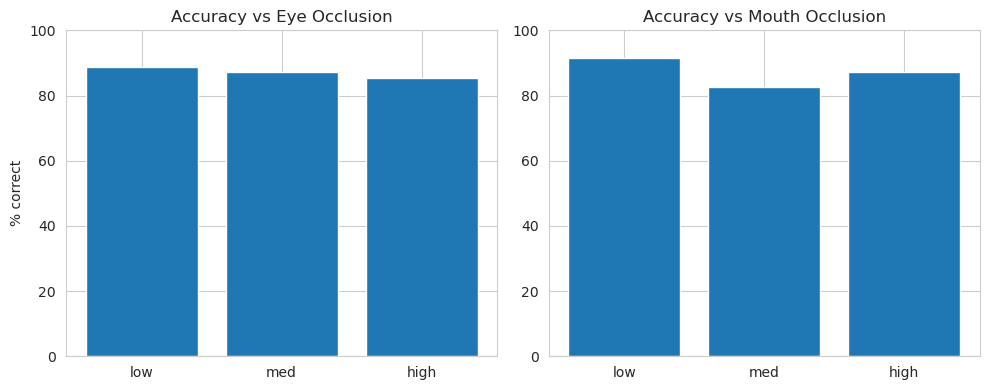

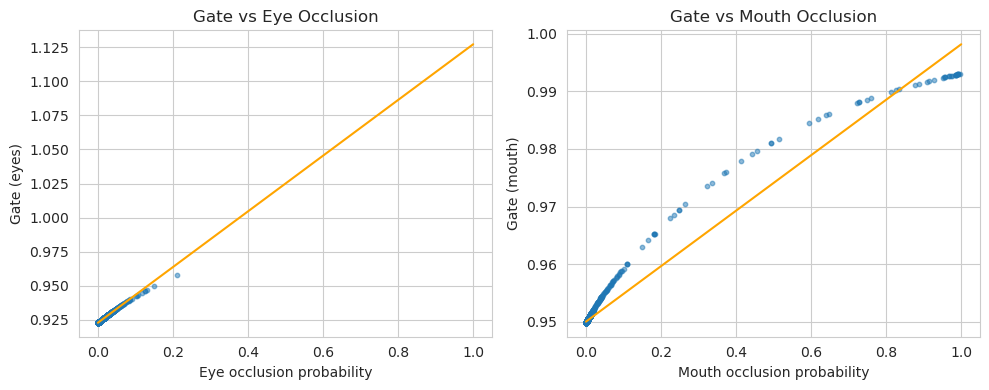


Tip: Use df_occ to slice specific conditions, e.g. high-mouth occlusion, and inspect predictions.


In [34]:
# === Occlusion analysis: metrics and plots ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

# Collect (or reuse) dataframe
if 'df_occ' not in globals():
    if 'test_loader' not in globals():
        raise RuntimeError("test_loader not defined. Run your data prep/evaluation first.")
    df_occ = collect_eval_with_occlusion(test_loader)

# # Define occlusion bins
labels = ['low', 'med', 'high']

df_occ = df_occ.copy()

# Quantile-based bins (equal-sized by count)
df_occ['eye_bin'] = pd.qcut(df_occ['eye_occ'], q=3, labels=labels)
df_occ['mouth_bin'] = pd.qcut(df_occ['mouth_occ'], q=3, labels=labels)


# edges = [-0.01, 0.3, 0.7, 1.01]
# labels = ['low', 'med', 'high']

# df_occ = df_occ.copy()
# df_occ['eye_bin'] = pd.cut(df_occ['eye_occ'], bins=edges, labels=labels)
# df_occ['mouth_bin'] = pd.cut(df_occ['mouth_occ'], bins=edges, labels=labels)

# Overall accuracy
overall_acc = df_occ['is_correct'].mean() * 100.0 if len(df_occ) else float('nan')
print(f"Overall accuracy: {overall_acc:.2f}% on N={len(df_occ)} samples")

# Accuracy by bins
acc_eye = df_occ.groupby('eye_bin')['is_correct'].mean().reindex(labels) * 100.0
acc_mouth = df_occ.groupby('mouth_bin')['is_correct'].mean().reindex(labels) * 100.0
cnt_eye = df_occ['eye_bin'].value_counts().reindex(labels)
cnt_mouth = df_occ['mouth_bin'].value_counts().reindex(labels)

print("\nAccuracy by eye occlusion bin (%):")
print(acc_eye.round(2).to_string())
print("Counts:")
print(cnt_eye.to_string())

print("\nAccuracy by mouth occlusion bin (%):")
print(acc_mouth.round(2).to_string())
print("Counts:")
print(cnt_mouth.to_string())

# Weighted F1 by bins (optional)
def _weighted_f1(sub: pd.DataFrame) -> float:
    if len(sub) == 0:
        return float('nan')
    y_true = sub['true'].to_numpy()
    y_pred = sub['pred'].to_numpy()
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return float(f1)

f1_eye = df_occ.groupby('eye_bin').apply(_weighted_f1).reindex(labels)
f1_mouth = df_occ.groupby('mouth_bin').apply(_weighted_f1).reindex(labels)
print("\nWeighted F1 by eye bin:")
print((f1_eye.fillna(0.0) * 100.0).round(2).to_string())
print("Weighted F1 by mouth bin:")
print((f1_mouth.fillna(0.0) * 100.0).round(2).to_string())

# Gate responsiveness: correlation
corr_eye = np.corrcoef(df_occ['eye_occ'], df_occ['gate_eye'])[0,1] if df_occ[['eye_occ','gate_eye']].dropna().shape[0] > 1 else np.nan
corr_mouth = np.corrcoef(df_occ['mouth_occ'], df_occ['gate_mouth'])[0,1] if df_occ[['mouth_occ','gate_mouth']].dropna().shape[0] > 1 else np.nan
print(f"\nCorrelation(eye_occ, gate_eye): {corr_eye:.3f}")
print(f"Correlation(mouth_occ, gate_mouth): {corr_mouth:.3f}")

# Plots
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, acc_eye.fillna(0.0))
axes[0].set_title('Accuracy vs Eye Occlusion')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('% correct')
axes[1].bar(labels, acc_mouth.fillna(0.0))
axes[1].set_title('Accuracy vs Mouth Occlusion')
axes[1].set_ylim(0, 100)
plt.tight_layout(); plt.show()

# Scatter with trend lines for gate responsiveness
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_occ['eye_occ'], df_occ['gate_eye'], s=10, alpha=0.5)
if df_occ[['eye_occ','gate_eye']].dropna().shape[0] > 1:
    z = np.polyfit(df_occ['eye_occ'], df_occ['gate_eye'], 1)
    x = np.linspace(0, 1, 100); axes[0].plot(x, z[0]*x + z[1], c='orange')
axes[0].set_xlabel('Eye occlusion probability'); axes[0].set_ylabel('Gate (eyes)')
axes[0].set_title('Gate vs Eye Occlusion')
axes[1].scatter(df_occ['mouth_occ'], df_occ['gate_mouth'], s=10, alpha=0.5)
if df_occ[['mouth_occ','gate_mouth']].dropna().shape[0] > 1:
    z = np.polyfit(df_occ['mouth_occ'], df_occ['gate_mouth'], 1)
    x = np.linspace(0, 1, 100); axes[1].plot(x, z[0]*x + z[1], c='orange')
axes[1].set_xlabel('Mouth occlusion probability'); axes[1].set_ylabel('Gate (mouth)')
axes[1].set_title('Gate vs Mouth Occlusion')
plt.tight_layout(); plt.show()

print("\nTip: Use df_occ to slice specific conditions, e.g. high-mouth occlusion, and inspect predictions.")


In [35]:
def bin_ranges(series, q=10, edges=None):
    if edges is not None:
        b = pd.cut(series, bins=edges, include_lowest=True)
    else:
        b = pd.qcut(series, q=q, duplicates='drop')  # equal-count bins
    dfb = pd.DataFrame({'v': series, 'bin': b})
    return dfb.groupby('bin')['v'].agg(['min','max','count']).sort_index()

# Deciles (equal-count)
eye_deciles  = bin_ranges(df_occ['eye_occ'],  q=10)
mouth_deciles= bin_ranges(df_occ['mouth_occ'], q=10)
print(eye_deciles); print(mouth_deciles)

# If you want semantic low/med/high, use edges with support:
edges = [0.0, 0.05, 0.10, 1.0]  # example; adjust after seeing deciles
mouth_bins = bin_ranges(df_occ['mouth_occ'], edges=edges)
print(mouth_bins)

                                        min       max  count
bin                                                         
(-0.0007930000000000001, 0.00161]  0.000207  0.001607   1139
(0.00161, 0.00224]                 0.001608  0.002240   1138
(0.00224, 0.00297]                 0.002240  0.002965   1138
(0.00297, 0.00363]                 0.002966  0.003629   1138
(0.00363, 0.00438]                 0.003630  0.004378   1139
(0.00438, 0.00536]                 0.004378  0.005355   1138
(0.00536, 0.00667]                 0.005357  0.006670   1138
(0.00667, 0.0086]                  0.006673  0.008594   1138
(0.0086, 0.0123]                   0.008597  0.012294   1138
(0.0123, 0.209]                    0.012296  0.209426   1139
                                         min       max  count
bin                                                          
(-0.0008990000000000001, 0.000616]  0.000101  0.000616   1139
(0.000616, 0.000905]                0.000616  0.000904   1138
(0.000905, 0.00122] 

#  **Ablation: Without gates**

In [36]:

# === Ablation: Disable gates at inference and recompute accuracy by occlusion bin ===
import torch, numpy as np, pandas as pd
from contextlib import contextmanager

class _OnesGate(torch.nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Return a column vector of ones matching batch size
        return torch.ones((x.shape[0], 1), device=x.device, dtype=x.dtype)

@contextmanager
def disable_gates_at_inference(model: torch.nn.Module):
    """Temporarily force eye/mouth gates to 1.0 so tokens are not down-weighted.
    Works with models that expose `model.occlusion_gates['eye_gate'|'mouth_gate']`.
    """
    if not hasattr(model, 'occlusion_gates'):
        raise AttributeError("Model has no attribute 'occlusion_gates'.")

    gates = getattr(model, 'occlusion_gates')
    # Support both dict-like and ModuleDict
    try:
        eye_orig = gates['eye_gate']
        mouth_orig = gates['mouth_gate']
    except Exception as e:
        raise AttributeError("Could not access 'eye_gate'/'mouth_gate' in model.occlusion_gates") from e

    gates['eye_gate'] = _OnesGate()
    gates['mouth_gate'] = _OnesGate()
    try:
        yield
    finally:
        gates['eye_gate'] = eye_orig
        gates['mouth_gate'] = mouth_orig

@torch.no_grad()
def evaluate_bins_with_gates_disabled(loader):
    mdl = _get_active_model()
    device = next(mdl.parameters()).device
    mdl.eval()

    with disable_gates_at_inference(mdl):
        df = collect_eval_with_occlusion(loader)

    # Compute accuracy by occlusion bins (same bins as before)
    edges = [-0.01, 0.3, 0.7, 1.01]
    labels = ['low', 'med', 'high']
    df = df.copy()
    df['eye_bin'] = pd.cut(df['eye_occ'], bins=edges, labels=labels)
    df['mouth_bin'] = pd.cut(df['mouth_occ'], bins=edges, labels=labels)

    overall = df['is_correct'].mean() * 100.0 if len(df) else float('nan')
    acc_eye = df.groupby('eye_bin')['is_correct'].mean().reindex(labels) * 100.0
    acc_mouth = df.groupby('mouth_bin')['is_correct'].mean().reindex(labels) * 100.0
    cnt_eye = df['eye_bin'].value_counts().reindex(labels)
    cnt_mouth = df['mouth_bin'].value_counts().reindex(labels)

    print(f"\n[No-Gate Ablation] Overall accuracy: {overall:.2f}% (N={len(df)})")
    print("Accuracy by eye occlusion bin (%):\n" + acc_eye.round(2).to_string())
    print("Counts:\n" + cnt_eye.to_string())
    print("\nAccuracy by mouth occlusion bin (%):\n" + acc_mouth.round(2).to_string())
    print("Counts:\n" + cnt_mouth.to_string())
    return {'df': df, 'overall_acc': overall, 'acc_eye': acc_eye, 'acc_mouth': acc_mouth}


result_nogate = evaluate_bins_with_gates_disabled(test_loader)
df_occ_nogate = result_nogate['df']


[No-Gate Ablation] Overall accuracy: 87.09% (N=11383)
Accuracy by eye occlusion bin (%):
eye_bin
low     87.09
med       NaN
high      NaN
Counts:
eye_bin
low     11383
med         0
high        0

Accuracy by mouth occlusion bin (%):
mouth_bin
low     87.10
med     92.86
high    84.38
Counts:
mouth_bin
low     11337
med        14
high       32


**Debugging checking both variants**

In [37]:
# Baseline (gated)
df_base = collect_eval_with_occlusion(test_loader)
# No-gate (just ran)
res_ng = evaluate_bins_with_gates_disabled(test_loader); df_ng = res_ng['df']

print("mean gate_eye (base,no-gate):",
      float(np.nanmean(df_base['gate_eye'])), float(np.nanmean(df_ng['gate_eye'])))
print("mean gate_mouth (base,no-gate):",
      float(np.nanmean(df_base['gate_mouth'])), float(np.nanmean(df_ng['gate_mouth'])))

same = (df_base['pred'].to_numpy() == df_ng['pred'].to_numpy()).mean()*100
print(f"% identical predictions: {same:.2f}% (N={len(df_base)})")


[No-Gate Ablation] Overall accuracy: 87.09% (N=11383)
Accuracy by eye occlusion bin (%):
eye_bin
low     87.09
med       NaN
high      NaN
Counts:
eye_bin
low     11383
med         0
high        0

Accuracy by mouth occlusion bin (%):
mouth_bin
low     87.10
med     92.86
high    84.38
Counts:
mouth_bin
low     11337
med        14
high       32
mean gate_eye (base,no-gate): 0.92417414956234 1.0
mean gate_mouth (base,no-gate): 0.950360592425545 1.0
% identical predictions: 99.82% (N=11383)


**Debugging: forcing stronger occlusion**

In [38]:
import torch
from contextlib import contextmanager

class _ConstGate(torch.nn.Module):
    def __init__(self, val): super().__init__(); self.val = float(val)
    def forward(self, x): return torch.full((x.shape[0],1), self.val, device=x.device, dtype=x.dtype)

@contextmanager
def force_gate_values(model, eye=None, mouth=None):
    g = model.occlusion_gates
    old_eye, old_mouth = g['eye_gate'], g['mouth_gate']
    if eye is not None:  g['eye_gate']  = _ConstGate(eye)   # final eye gates = 0.3 + 0.7*eye
    if mouth is not None:g['mouth_gate'] = _ConstGate(mouth) # final mouth    = 0.3 + 0.7*mouth
    try:   yield
    finally:
        g['eye_gate'], g['mouth_gate'] = old_eye, old_mouth

# Example: simulate heavy eye occlusion (final eye gates ≈ 0.3)
with force_gate_values(_get_active_model(), eye=0.0):
    df_eye030 = collect_eval_with_occlusion(test_loader)
    acc_eye030 = (df_eye030['is_correct'].mean()*100.0)
    print(f"Accuracy with eye gates forced to 0.3: {acc_eye030:.2f}%")

Accuracy with eye gates forced to 0.3: 85.05%


In [39]:
import pandas as pd

def sweep_forced_gates(test_loader, eye_vals=(1.0, 0.6, 0.0), mouth_vals=(1.0, 0.6, 0.0)):
    mdl = _get_active_model(); mdl.eval()
    rows = []
    for e in eye_vals:
        with force_gate_values(mdl, eye=e, mouth=None):
            df = collect_eval_with_occlusion(test_loader)
            rows.append({'where':'eye', 'forced_val': e, 'final_gate': 0.3 + 0.7*e,
                         'acc_overall_%': float(df['is_correct'].mean()*100.0)})
    for m in mouth_vals:
        with force_gate_values(mdl, eye=None, mouth=m):
            df = collect_eval_with_occlusion(test_loader)
            rows.append({'where':'mouth', 'forced_val': m, 'final_gate': 0.3 + 0.7*m,
                         'acc_overall_%': float(df['is_correct'].mean()*100.0)})
    return pd.DataFrame(rows)

df_sweep = sweep_forced_gates(test_loader)
print(df_sweep)

   where  forced_val  final_gate  acc_overall_%
0    eye         1.0        1.00      87.226566
1    eye         0.6        0.72      86.550119
2    eye         0.0        0.30      85.047878
3  mouth         1.0        1.00      86.945445
4  mouth         0.6        0.72      87.657032
5  mouth         0.0        0.30      88.930862


**Feature Masking**

In [40]:
import numpy as np, torch
from contextlib import nullcontext

@torch.no_grad()
def eval_with_feature_mask(loader, mask='eyes', no_gates=False):
    mdl = _get_active_model(); mdl.eval()
    ctx = disable_gates_at_inference(mdl) if no_gates else nullcontext()
    with ctx:
        correct, total = 0, 0
        for batch in loader:
            b = _safe_move_batch_to_device(batch, next(mdl.parameters()).device)
            if mask in ('eyes','all'):
                for r in ['left_eye','right_eye']:
                    b['features'][r] = torch.zeros_like(b['features'][r])
            if mask in ('mouth','all'):
                b['features']['mouth'] = torch.zeros_like(b['features']['mouth'])
            out = mdl(b['features'], b['occlusion_info'])
            pred = torch.argmax(out['class_logits'], dim=-1)
            lab = b['label'].view(-1)
            correct += (pred == lab).sum().item()
            total += lab.numel()
        return correct/total*100.0

print("Mask eyes, gated:   ", eval_with_feature_mask(test_loader, 'eyes',  no_gates=False))
print("Mask eyes, no-gates:", eval_with_feature_mask(test_loader, 'eyes',  no_gates=True))
print("Mask mouth, gated:  ", eval_with_feature_mask(test_loader, 'mouth', no_gates=False))
print("Mask mouth, no-gates:",eval_with_feature_mask(test_loader, 'mouth', no_gates=True))

Mask eyes, gated:    44.81243960291663
Mask eyes, no-gates: 44.84757972415005
Mask mouth, gated:   90.01142053940086
Mask mouth, no-gates: 90.0202055697092


In [41]:
import torch
from contextlib import nullcontext

@torch.no_grad()
def eval_with_mask_and_occinfo(loader, mask='eyes', no_gates=False):
    mdl = _get_active_model(); mdl.eval()
    device = next(mdl.parameters()).device
    ctx = disable_gates_at_inference(mdl) if no_gates else nullcontext()
    correct, total = 0, 0
    with ctx:
        for batch in loader:
            b = _safe_move_batch_to_device(batch, device)
            B = b['label'].shape[0]

            # 1) Mask features
            if mask in ('eyes','all'):
                for r in ['left_eye','right_eye']:
                    b['features'][r] = torch.zeros_like(b['features'][r])
            if mask in ('mouth','all'):
                b['features']['mouth'] = torch.zeros_like(b['features']['mouth'])

            # 2) Reflect occlusion in occlusion_info
            if isinstance(b['occlusion_info']['eye_occlusion_prob'], torch.Tensor):
                if mask in ('eyes','all'):
                    b['occlusion_info']['eye_occlusion_prob'] = torch.ones(B, device=device)
            if isinstance(b['occlusion_info']['mouth_occlusion_prob'], torch.Tensor):
                if mask in ('mouth','all'):
                    b['occlusion_info']['mouth_occlusion_prob'] = torch.ones(B, device=device)

            out = mdl(b['features'], b['occlusion_info'])
            pred = torch.argmax(out['class_logits'], dim=-1)
            lab = b['label'].view(-1)
            correct += (pred == lab).sum().item()
            total += lab.numel()
    return correct/total*100.0 if total else float('nan')

print("Eyes masked, gated (occ=1):   ", eval_with_mask_and_occinfo(test_loader, 'eyes',  no_gates=False))
print("Eyes masked, no-gates:        ", eval_with_mask_and_occinfo(test_loader, 'eyes',  no_gates=True))
print("Mouth masked, gated (occ=1):  ", eval_with_mask_and_occinfo(test_loader, 'mouth', no_gates=False))
print("Mouth masked, no-gates:       ", eval_with_mask_and_occinfo(test_loader, 'mouth', no_gates=True))

Eyes masked, gated (occ=1):    44.900289906000175
Eyes masked, no-gates:         44.84757972415005
Mouth masked, gated (occ=1):   90.03777563032592
Mouth masked, no-gates:        90.0202055697092


**Analysis with actual Occlusion labels**

In [42]:
# === Collector (with ground-truth occlusion) ===
import numpy as np, pandas as pd, torch
from typing import Dict, Any

@torch.no_grad()
def collect_eval_with_occlusion_plus(loader) -> pd.DataFrame:
    """Like collect_eval_with_occlusion, but also records gt eye/mouth occlusion if present.
    Returns a DataFrame with columns: true, pred, is_correct, class_name,
    eye_occ, mouth_occ, gate_face, gate_eye, gate_mouth, conf, gt_eye_occ, gt_mouth_occ
    """
    mdl = _get_active_model(); mdl.eval()
    device = next(mdl.parameters()).device

    rows = []
    for batch in loader:
        batch_dev = _safe_move_batch_to_device(batch, device)
        outputs = mdl(batch_dev['features'], batch_dev['occlusion_info'], return_attention=True)

        preds = outputs['predicted_class'].view(-1).detach().cpu().numpy()
        labels = batch_dev['label'].view(-1).detach().cpu().numpy()
        probs  = outputs['class_probs'].detach().cpu().numpy() if 'class_probs' in outputs else None
        gates  = outputs['gate_factors'].detach().cpu().numpy() if 'gate_factors' in outputs else None

        eye_occ   = batch_dev['occlusion_info']['eye_occlusion_prob'].view(-1).detach().cpu().numpy()
        mouth_occ = batch_dev['occlusion_info']['mouth_occlusion_prob'].view(-1).detach().cpu().numpy()

        names = batch.get('class_name')
        if isinstance(names, list):
            class_names = [str(x) for x in names]
        else:
            class_names = [str(int(y)) for y in labels]

        gt_list = batch.get('ground_truth', None)

        bsz = len(labels)
        for i in range(bsz):
            gate_face = float(gates[i, 0]) if gates is not None else np.nan
            gate_eye  = float(np.mean(gates[i, 1:3])) if gates is not None else np.nan
            gate_mouth= float(gates[i, 3]) if gates is not None else np.nan
            conf = float(probs[i, int(preds[i])]) if probs is not None else np.nan

            gt_eye = None; gt_mouth = None
            if isinstance(gt_list, (list, tuple)) and i < len(gt_list) and isinstance(gt_list[i], dict):
                gt_eye = bool(gt_list[i].get('eyes_occluded', False))
                gt_mouth = bool(gt_list[i].get('mouth_occluded', False))
            elif isinstance(gt_list, dict):
                gt_eye = bool(gt_list.get('eyes_occluded', False))
                gt_mouth = bool(gt_list.get('mouth_occluded', False))

            rows.append({
                'true': int(labels[i]),
                'pred': int(preds[i]),
                'is_correct': bool(int(preds[i]) == int(labels[i])),
                'class_name': class_names[i],
                'eye_occ': float(eye_occ[i]),
                'mouth_occ': float(mouth_occ[i]),
                'gate_face': gate_face,
                'gate_eye': gate_eye,
                'gate_mouth': gate_mouth,
                'conf': conf,
                'gt_eye_occ': gt_eye,
                'gt_mouth_occ': gt_mouth,
            })

    df = pd.DataFrame(rows)
    print(f"Collected samples: {len(df)}")
    return df

print("Collector ready: df_occ_plus = collect_eval_with_occlusion_plus(test_loader)")

Collector ready: df_occ_plus = collect_eval_with_occlusion_plus(test_loader)


In [43]:
# === Metrics: overall and by occlusion bins; occlusion detection report ===
import numpy as np, pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Build mapping id->name from df (most frequent name per true id)
def infer_id_to_name(df: pd.DataFrame):
    id_to_name = {}
    for k in sorted(df['true'].unique()):
        names = df.loc[df['true'] == k, 'class_name']
        if len(names):
            id_to_name[k] = names.value_counts().idxmax()
        else:
            id_to_name[k] = str(k)
    return id_to_name

# Pretty print report for a subset
_DEF_LABELS = None

def _report_for_subset(df: pd.DataFrame, title: str, labels_order=None):
    if df.empty:
        print(f"\n{title}: (no data)")
        return
    y_true = df['true'].to_numpy()
    y_pred = df['pred'].to_numpy()
    id2name = infer_id_to_name(df)
    order = labels_order if labels_order is not None else sorted(id2name.keys())
    target_names = [id2name[i] for i in order]
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, labels=order, target_names=target_names, digits=3, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=order)
    print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Compute occlusion detection metrics
def occlusion_detection_report(df: pd.DataFrame, which='eye', thresh=0.5):
    key_prob = 'eye_occ' if which=='eye' else 'mouth_occ'
    key_gt   = 'gt_eye_occ' if which=='eye' else 'gt_mouth_occ'
    sub = df[df[key_gt].notna()].copy()
    if sub.empty:
        print(f"\nOcclusion detection [{which}]: no GT available")
        return
    y_true = sub[key_gt].astype(bool).to_numpy().astype(int)
    y_pred = (sub[key_prob] >= thresh).astype(int).to_numpy()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    print(f"\nOcclusion detection [{which}] @ thresh={thresh:.2f}")
    print(f"Precision={p:.3f} Recall={r:.3f} F1={f1:.3f}")
    print("Confusion matrix [\n  [TN FP]\n  [FN TP]\n]:\n", cm)

# Driver function

def full_metric_breakdown(df: pd.DataFrame, occ_edges=(-0.01,0.3,0.7,1.01)):
    labels = ['low','med','high']
    eye_bin = pd.cut(df['eye_occ'], bins=occ_edges, labels=labels)
    mouth_bin = pd.cut(df['mouth_occ'], bins=occ_edges, labels=labels)

    # Overall
    _report_for_subset(df, 'Overall classification report')

    # By eye bin
    for b in labels:
        _report_for_subset(df[eye_bin==b], f'Classification report | eye_bin={b}')

    # By mouth bin
    for b in labels:
        _report_for_subset(df[mouth_bin==b], f'Classification report | mouth_bin={b}')

    # By GT occlusion if available
    if 'gt_eye_occ' in df.columns:
        _report_for_subset(df[df['gt_eye_occ'] == True],  'Class report | GT eyes occluded=True')
        _report_for_subset(df[df['gt_eye_occ'] == False], 'Class report | GT eyes occluded=False')
    if 'gt_mouth_occ' in df.columns:
        _report_for_subset(df[df['gt_mouth_occ'] == True],  'Class report | GT mouth occluded=True')
        _report_for_subset(df[df['gt_mouth_occ'] == False], 'Class report | GT mouth occluded=False')

    # Occlusion detection (prob vs GT)
    if 'gt_eye_occ' in df.columns:
        occlusion_detection_report(df, 'eye',  thresh=0.5)
    if 'gt_mouth_occ' in df.columns:
        occlusion_detection_report(df, 'mouth', thresh=0.5)

print("Metrics helpers ready. Example usage:\n"
      "df_occ_plus = collect_eval_with_occlusion_plus(test_loader)\n"
      "full_metric_breakdown(df_occ_plus)")

Metrics helpers ready. Example usage:
df_occ_plus = collect_eval_with_occlusion_plus(test_loader)
full_metric_breakdown(df_occ_plus)


In [44]:
df_occ_plus = collect_eval_with_occlusion_plus(test_loader)

Collected samples: 11383


In [45]:
full_metric_breakdown(df_occ_plus)


Overall classification report
              precision    recall  f1-score   support

   EyeClosed      0.963     0.948     0.955      1265
        Yawn      0.505     0.792     0.617      1448
     Neutral      0.962     0.873     0.915      8670

    accuracy                          0.871     11383
   macro avg      0.810     0.871     0.829     11383
weighted avg      0.904     0.871     0.882     11383

Confusion matrix (rows=true, cols=pred):
 [[1199   26   40]
 [  40 1147  261]
 [   6 1097 7567]]

Classification report | eye_bin=low
              precision    recall  f1-score   support

   EyeClosed      0.963     0.948     0.955      1265
        Yawn      0.505     0.792     0.617      1448
     Neutral      0.962     0.873     0.915      8670

    accuracy                          0.871     11383
   macro avg      0.810     0.871     0.829     11383
weighted avg      0.904     0.871     0.882     11383

Confusion matrix (rows=true, cols=pred):
 [[1199   26   40]
 [  40 1147  

## **Mouth Occlusion Analysis**

In [46]:
from sklearn.metrics import precision_recall_fscore_support

def tune_thresh_on_gt(df, which='mouth'):
    prob = df['mouth_occ'] if which=='mouth' else df['eye_occ']
    gt = df['gt_mouth_occ'] if which=='mouth' else df['gt_eye_occ']
    sub = df[gt.notna()].copy()
    if sub.empty: 
        print("No GT occlusion available."); return None
    best, best_t = (-1, 0.0), 0.0
    for t in np.linspace(0.0, 1.0, 101):
        y_true = sub[gt.name].astype(int).values
        y_pred = (sub[prob.name] >= t).astype(int).values
        p,r,f1,_ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        if f1 > best[0]: best, best_t = (f1,p,r), t
    f1,p,r = best[0], best[1], best[2]
    print(f"Best {which} occlusion threshold: {best_t:.2f} | F1={f1:.3f} P={p:.3f} R={r:.3f}")
    return best_t


def report_by_thresh(df, t, which='mouth'):
    key_prob = 'mouth_occ' if which=='mouth' else 'eye_occ'
    mask = df[key_prob] >= t
    print(f"\nClassification with {which} occluded (>= {t:.2f}) vs not")
    print(f"N occluded: {mask.sum()} | N not: {(~mask).sum()}")
    # Per-class metrics in each group
    _report_for_subset(df[ mask], f"Class report | {which} occluded=True")
    _report_for_subset(df[~mask], f"Class report | {which} occluded=False")


In [47]:
df_occ_mouth= collect_eval_with_occlusion_plus(test_loader)
print(len(df_occ_mouth), df_occ_mouth[['mouth_occ','gt_mouth_occ']].notna().sum())

df_occ_mouth[['gt_eye_occ','gt_mouth_occ']].value_counts(dropna=False)
df_occ_mouth.groupby('gt_mouth_occ')['mouth_occ'].describe()

Collected samples: 11383
11383 mouth_occ       11383
gt_mouth_occ    11383
dtype: int64


,count,mean,std,min,25%,50%,75%,max
gt_mouth_occ,,,,,,,,
False,10714.0,0.006103,0.050696,0.000101,0.001010,0.001848,0.003185,0.992125
True,669.0,0.012297,0.069573,0.000244,0.002351,0.004066,0.006584,0.995515


In [48]:
# 1) Find the best threshold on GT (max F1)
best_t_mouth = tune_thresh_on_gt(df_occ_mouth, which='mouth')  # prints best t, F1, P, R

# 2) Print 3-class reports for occluded vs not using that threshold
report_by_thresh(df_occ_mouth, best_t_mouth, which='mouth')     # prints counts + reports

Best mouth occlusion threshold: 0.01 | F1=0.133 P=0.137 R=0.129

Classification with mouth occluded (>= 0.01) vs not
N occluded: 628 | N not: 10755

Class report | mouth occluded=True
              precision    recall  f1-score   support

   EyeClosed      1.000     0.938     0.968        32
        Yawn      0.716     0.964     0.822       110
     Neutral      0.987     0.914     0.949       486

    accuracy                          0.924       628
   macro avg      0.901     0.938     0.913       628
weighted avg      0.940     0.924     0.927       628

Confusion matrix (rows=true, cols=pred):
 [[ 30   0   2]
 [  0 106   4]
 [  0  42 444]]

Class report | mouth occluded=False
              precision    recall  f1-score   support

   EyeClosed      0.962     0.948     0.955      1233
        Yawn      0.491     0.778     0.602      1338
     Neutral      0.960     0.870     0.913      8184

    accuracy                          0.868     10755
   macro avg      0.804     0.865     

In [49]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, confusion_matrix

sub = df_occ_mouth[df_occ_mouth['gt_mouth_occ'].notna()].copy()
X = sub['mouth_occ'].to_numpy()
y = sub['gt_mouth_occ'].astype(int).to_numpy()

iso = IsotonicRegression(out_of_bounds='clip').fit(X, y)
cal_score = iso.predict(X)
ap = average_precision_score(y, cal_score)
print(f"Calibrated PR-AUC = {ap:.3f}")

# pick threshold at max F1 on calibrated scores
best_f1, best_t = -1.0, 0.0
for t in np.linspace(0, 1, 101):
    yp = (cal_score >= t).astype(int)
    p = (yp & (y==1)).sum() / max(yp.sum(), 1)
    r = (yp & (y==1)).sum() / max((y==1).sum(), 1)
    f1 = 0 if (p+r)==0 else 2*p*r/(p+r)
    if f1 > best_f1: best_f1, best_t = f1, t
print(f"Best calibrated threshold: {best_t:.2f} | F1={best_f1:.3f}")

# confusion at tuned threshold
yp = (cal_score >= best_t).astype(int)
print("Confusion [rows=true, cols=pred]:\n", confusion_matrix(y, yp, labels=[0,1]))
print(classification_report(y, yp, target_names=['NotOcc','Occ'], digits=3, zero_division=0))

Calibrated PR-AUC = 0.142
Best calibrated threshold: 0.11 | F1=0.240
Confusion [rows=true, cols=pred]:
 [[8952 1762]
 [ 338  331]]
              precision    recall  f1-score   support

      NotOcc      0.964     0.836     0.895     10714
         Occ      0.158     0.495     0.240       669

    accuracy                          0.816     11383
   macro avg      0.561     0.665     0.567     11383
weighted avg      0.916     0.816     0.857     11383



In [50]:
# Export frames by GT mouth occlusion flag into two folders
# Requires: csv_data from your loader (has annotations with mouth_occluded_prior)

import os, cv2

def export_mouth_occ_frames(csv_data, out_root="viz_mouth_occ", 
                            max_true=200, max_false=200, stride=10):
    os.makedirs(out_root, exist_ok=True)
    out_true  = os.path.join(out_root, "mouth_occ_true");  os.makedirs(out_true, exist_ok=True)
    out_false = os.path.join(out_root, "mouth_occ_false"); os.makedirs(out_false, exist_ok=True)

    cnt_true = cnt_false = 0

    for video_key, meta in csv_data.items():
        cap = cv2.VideoCapture(meta['video_path'])
        if not cap.isOpened():
            print(f"Could not open video: {meta['video_path']}")
            continue

        try:
            anns = meta['annotations']
            for idx, ann in enumerate(anns):
                if (idx % stride) != 0: 
                    continue
                flag = bool(getattr(ann, 'mouth_occluded_prior', False))
                if flag and cnt_true >= max_true: 
                    continue
                if not flag and cnt_false >= max_false: 
                    continue

                fn = int(ann.frame)
                cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
                ok, frame_bgr = cap.read()
                if not ok:
                    continue

                # Name: {video}_f{frame}_{class}_{occ}.jpg
                fname = f"{video_key}_f{fn:06d}_{ann.class_label}_{'occT' if flag else 'occF'}.jpg"
                out_dir = out_true if flag else out_false
                cv2.imwrite(os.path.join(out_dir, fname), frame_bgr)

                if flag: cnt_true += 1
                else:     cnt_false += 1

                if cnt_true >= max_true and cnt_false >= max_false:
                    break
        finally:
            cap.release()

        if cnt_true >= max_true and cnt_false >= max_false:
            break

    print(f"Saved: {cnt_true} occluded, {cnt_false} not-occluded → {out_root}")

# Usage
export_mouth_occ_frames(csv_data, out_root="viz_mouth_occ", max_true=150, max_false=150, stride=5)

Saved: 150 occluded, 150 not-occluded → viz_mouth_occ


In [51]:
df_occ_mouth.head()

,true,pred,is_correct,class_name,eye_occ,mouth_occ,gate_face,gate_eye,gate_mouth,conf,gt_eye_occ,gt_mouth_occ
0,2,2,True,Neutral,0.004395,0.000725,1.0,0.923742,0.949919,0.999511,False,False
1,2,2,True,Neutral,0.002799,0.000580,1.0,0.923390,0.949902,0.999520,False,False
2,2,2,True,Neutral,0.003571,0.000586,1.0,0.923561,0.949903,0.999526,False,False
3,2,2,True,Neutral,0.005124,0.000620,1.0,0.923902,0.949907,0.999488,False,False
4,2,2,True,Neutral,0.004063,0.000837,1.0,0.923669,0.949932,0.999482,False,False


In [ ]:
# === Save test predictions with robust meta extraction (no meta_csv needed) ===
import os, numpy as np, pandas as pd, torch

# Canonical class mapping from your CONFIG
CSV_LABELS    = CONFIG['CSV_LABELS']                    # e.g. {'EyeClosed': 0, 'Yawn': 1, 'Neutral': 0}
ID_TO_NAME    = {idx: name for name, idx in CSV_LABELS.items()}
ORDERED_IDS   = sorted(ID_TO_NAME.keys())
ORDERED_NAMES = [ID_TO_NAME[i] for i in ORDERED_IDS]

def _safe_get_meta(batch, i):
    """
    Pull per-sample meta from the batch, handling list/str/torch.Tensor.
    Falls back to optional 'frame_data' list of dicts if present.
    """
    import torch
    def pick(x):
        if x is None: return None
        if isinstance(x, list): return x[i]
        if torch.is_tensor(x):
            # Accept scalar or 1D tensors
            return x.view(-1)[i].item()
        return x  # str/int/None
    vk  = pick(batch.get('video_key'))
    fn  = pick(batch.get('frame_number'))
    fid = pick(batch.get('frame_id'))
    fd  = batch.get('frame_data')
    if (vk is None or fn is None or fid is None) and isinstance(fd, list) and i < len(fd) and isinstance(fd[i], dict):
        vk  = vk  or fd[i].get('video_key')
        fn  = fn  or fd[i].get('frame_number')
        fid = fid or fd[i].get('frame_id')
    return vk, fn, fid

def _to_int_or_none(x):
    try:
        return int(x)
    except Exception:
        return None

@torch.no_grad()
def save_test_predictions(model, loader, out_csv="exports/test_predictions.csv", save_every=5):
    """
    Writes rows incrementally so progress is kept if interrupted.
    Columns include meta, 3-class probs, gates, attention, and occlusion probs.
    """
    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    dev = next(model.parameters()).device
    model.eval()

    rows = []
    header_written = os.path.exists(out_csv) and os.path.getsize(out_csv) > 0

    def to_dev(b):
        def td(x):
            if isinstance(x, torch.Tensor):
                if x.dtype == torch.float64: x = x.float()
                return x.to(dev)
            if isinstance(x, dict): return {k: td(v) for k,v in x.items()}
            return x
        return {k: ({r: td(t) for r,t in v.items()} if k=='features' and isinstance(v, dict) else td(v))
                for k,v in b.items()}

    total = 0
    for bi, batch in enumerate(loader):
        b = to_dev(batch)
        out = model(b['features'], b['occlusion_info'], return_attention=True)

        probs = out['class_probs'].detach().cpu().numpy()           # [B, C]
        preds = np.argmax(probs, axis=-1)                           # [B]
        gates = out.get('gate_factors')
        gates = gates.detach().cpu().numpy() if torch.is_tensor(gates) else None  # [B, 4]
        attn  = out.get('attention_weights')
        attn  = attn.detach().cpu().numpy()  if torch.is_tensor(attn)  else None  # [B, 4]

        labels    = b['label'].view(-1).detach().cpu().numpy()      # [B]
        eye_occ   = b['occlusion_info']['eye_occlusion_prob'].view(-1).detach().cpu().numpy()
        mouth_occ = b['occlusion_info']['mouth_occlusion_prob'].view(-1).detach().cpu().numpy()

        # Prefer batch-provided names; else map ids via CONFIG
        names = batch.get('class_name')
        if isinstance(names, list):
            true_names = [str(x) for x in names]
        else:
            true_names = [ID_TO_NAME.get(int(y), str(int(y))) for y in labels]

        B = len(labels)
        for i in range(B):
            vk, fn, fid = _safe_get_meta(batch, i)

            row = {
                'video_key': vk,
                'frame_number': _to_int_or_none(fn),
                'frame_id': _to_int_or_none(fid),
                'true_id':  int(labels[i]),
                'true_name': true_names[i],
                'pred_id':  int(preds[i]),
                'pred_name': ID_TO_NAME.get(int(preds[i]), str(int(preds[i]))),
                'is_correct': bool(preds[i] == labels[i]),
                'conf': float(probs[i, preds[i]]),
                'eye_occ': float(eye_occ[i]),
                'mouth_occ': float(mouth_occ[i]),
            }
            # Per-class probabilities with readable names
            for cls_id in ORDERED_IDS:
                if cls_id < probs.shape[1]:
                    row[f'prob_{ID_TO_NAME[cls_id]}'] = float(probs[i, cls_id])

            if isinstance(gates, np.ndarray) and gates.shape[1] >= 4:
                row.update({
                    'gate_face': float(gates[i,0]),
                    'gate_left_eye': float(gates[i,1]),
                    'gate_right_eye': float(gates[i,2]),
                    'gate_mouth': float(gates[i,3]),
                })
            if isinstance(attn, np.ndarray) and attn.shape[1] >= 4:
                row.update({
                    'attn_face': float(attn[i,0]),
                    'attn_left_eye': float(attn[i,1]),
                    'attn_right_eye': float(attn[i,2]),
                    'attn_mouth': float(attn[i,3]),
                })

            rows.append(row)

        if (bi + 1) % save_every == 0:
            pd.DataFrame(rows).to_csv(out_csv, mode='a', index=False, header=not header_written)
            header_written = True
            total += len(rows)
            rows = []

    if rows:
        pd.DataFrame(rows).to_csv(out_csv, mode='a', index=False, header=not header_written)
        total += len(rows)

    print(f"Saved {total} rows → {out_csv}")

# Usage:
save_test_predictions(trained_model, test_loader, out_csv="exports/test_predictions.csv", save_every=5)

Saved 11383 rows → exports/test_predictions.csv


**No gate Ablation**

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class EnhancedTransformerNoGates(nn.Module):
    """
    Identical to EnhancedOcclusionAwareTransformer but with NO gating:
    - No occlusion gate modules
    - No scaling of tokens by gates
    - occlusion_info is ignored
    - gate_factors returned as all-ones for API compatibility
    """
    def __init__(self, feature_dim=512, hidden_dim=128, num_heads=4, num_classes=3,
                 num_layers=2, use_relative_pos=True):
        super().__init__()

        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.num_classes = num_classes
        self.num_regions = 4
        self.num_layers = num_layers
        self.use_relative_pos = use_relative_pos

        print(f"🏗️ Building ENHANCED Transformer (NO GATES)")
        print(f"  📏 Feature dim: {feature_dim} → Hidden dim: {hidden_dim}")
        print(f"  🧠 Heads: {num_heads}, Layers: {num_layers}")
        print(f"  🎯 Regions: {self.num_regions}, Classes: {num_classes}")
        print(f"  🔧 Relative positional encoding: {use_relative_pos}")
        print(f"  🚫 Occlusion gates: DISABLED")

        # 1) Feature projectors (unchanged)
        self.feature_projectors = nn.ModuleDict({
            'face': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'left_eye': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'right_eye': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            ),
            'mouth': nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(0.1)
            )
        })

        # 2) Positional embeddings (unchanged)
        if use_relative_pos:
            self.pos_encoding = self._create_sinusoidal_embeddings(self.num_regions, hidden_dim)
        else:
            self.pos_embedding = nn.Embedding(self.num_regions, hidden_dim)

        # 3) Region type embeddings (unchanged)
        self.region_type_embedding = nn.Embedding(3, hidden_dim)

        # 4) Transformer encoder (unchanged)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(hidden_dim)
        )

        # 5) Query token + cross-attention pooling (unchanged)
        self.query_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        nn.init.xavier_uniform_(self.query_token)

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )
        self.pool_norm = nn.LayerNorm(hidden_dim)

        # 6) Temperature parameter (kept for parity, not used explicitly)
        self.attention_temperature = nn.Parameter(
            torch.ones(1) * math.sqrt(hidden_dim // num_heads)
        )

        # 7) Classifier (unchanged)
        self.state_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )

        self._init_weights()
        print(f"✅ Enhanced Transformer (NO GATES) built!")
        print(f"  📊 Parameters: {sum(p.numel() for p in self.parameters()):,}")

    def _create_sinusoidal_embeddings(self, num_positions, d_model):
        pe = torch.zeros(num_positions, d_model)
        position = torch.arange(0, num_positions, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        return nn.Parameter(pe, requires_grad=False)

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight' in name and p.dim() > 1:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def forward(self, features, occlusion_info=None, return_attention=False):
        device = next(self.parameters()).device
        region_names = ['face', 'left_eye', 'right_eye', 'mouth']
        region_types = [0, 1, 1, 2]

        def to_B512(x):
            if isinstance(x, (list, tuple)):
                stacked = []
                for t in x:
                    if torch.is_tensor(t):
                        stacked.append(t)
                    else:
                        stacked.append(torch.tensor(t, dtype=torch.float32))
                x = torch.stack(stacked, dim=0)
            elif not torch.is_tensor(x):
                x = torch.tensor(x, dtype=torch.float32)
            if x.dim() == 1:
                x = x.unsqueeze(0)
            return x

        # Project features
        batch_size = None
        region_feats = {}
        for region in region_names:
            feat = to_B512(features[region])
            if batch_size is None:
                batch_size = feat.shape[0]
            region_feats[region] = feat.to(device)

        projected = []
        for region in region_names:
            projected.append(self.feature_projectors[region](region_feats[region]))
        token_sequence = torch.stack(projected, dim=1)  # [B, 4, H]

        # Positional + type embeddings
        if self.use_relative_pos:
            pos_emb = self.pos_encoding.unsqueeze(0).expand(batch_size, -1, -1)
        else:
            positions = torch.arange(self.num_regions, device=device)
            pos_emb = self.pos_embedding(positions).unsqueeze(0).expand(batch_size, -1, -1)

        region_type_ids = torch.tensor(region_types, device=device)
        type_emb = self.region_type_embedding(region_type_ids).unsqueeze(0).expand(batch_size, -1, -1)

        token_sequence = token_sequence + pos_emb + type_emb

        # NO GATING: feed tokens directly to encoder
        hidden_states = self.transformer_encoder(token_sequence)  # [B, 4, H]

        # Query-based pooling
        query = self.query_token.expand(batch_size, -1, -1)  # [B, 1, H]
        pooled_state, attention_weights = self.cross_attention(
            query, hidden_states, hidden_states, need_weights=True
        )  # pooled: [B,1,H], attn: [B,1,4]

        pooled_state = self.pool_norm(pooled_state.squeeze(1))  # [B,H]
        attention_weights = attention_weights.squeeze(1)  # [B,4]

        # Classification
        class_logits = self.state_classifier(pooled_state)

        # For API compatibility with the gated model:
        gate_factors_tensor = torch.ones(batch_size, 4, device=device)

        outputs = {
            'class_logits': class_logits,
            'class_probs': F.softmax(class_logits, dim=-1),
            'predicted_class': torch.argmax(class_logits, dim=-1),
            'attention_weights': attention_weights,
            'gate_factors': gate_factors_tensor,
            'hidden_states': hidden_states,
            'pooled_state': pooled_state
        }
        return outputs


# === Example usage (same hyperparams as your tiny_transformer) ===
print("🚀 INITIALIZING ENHANCED TRANSFORMER (NO GATES)")
print("=" * 70)

tiny_transformer_nogates = EnhancedTransformerNoGates(
    feature_dim=512,
    hidden_dim=128,
    num_heads=4,
    num_classes=3,
    num_layers=3,
    use_relative_pos=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tiny_transformer_nogates = tiny_transformer_nogates.to(device)
print(f"✅ Enhanced NO-GATES transformer ready on {device}!")


🚀 INITIALIZING ENHANCED TRANSFORMER (NO GATES)
🏗️ Building ENHANCED Transformer (NO GATES)
  📏 Feature dim: 512 → Hidden dim: 128
  🧠 Heads: 4, Layers: 3
  🎯 Regions: 4, Classes: 3
  🔧 Relative positional encoding: True
  🚫 Occlusion gates: DISABLED
✅ Enhanced Transformer (NO GATES) built!
  📊 Parameters: 934,660
✅ Enhanced NO-GATES transformer ready on cpu!


In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class TinyTransformerTrainerNoGates:
    """
    Trainer for NO-GATES transformer variants.
    - Classification-only objective (no gate regularizers).
    - Batch-safe device movement for nested structures.
    - Same public API as your original trainer (train_epoch/evaluate/history).
    """
    def __init__(self, model, device='cpu', learning_rate=3e-5):
        self.model = model.to(device)
        self.device = device

        self.optimizer = torch.optim.AdamW(
            self.model.parameters(), lr=learning_rate,
            weight_decay=1e-4, betas=(0.9, 0.999)
        )

        # Cosine annealing (no restarts) to match your last setup
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=20, eta_min=1e-6
        )

        self.classification_criterion = nn.CrossEntropyLoss()
        self.loss_weights = {'classification': 1.0}  # <-- only classification

        self.history = {
            'epoch_losses': [],
            'classification_losses': [],
            'accuracies': [],
            'learning_rates': [],
        }

        print(f" TinyTransformerTrainerNoGates initialized on {device}")

    def _move_batch_to_device(self, batch):
        def to_dev(x):
            if isinstance(x, torch.Tensor):
                # Normalize float dtype
                if x.dtype == torch.float64:
                    x = x.float()
                return x.to(self.device)
            if isinstance(x, dict):
                return {k: to_dev(v) for k, v in x.items()}
            if isinstance(x, (list, tuple)):
                return type(x)(to_dev(v) for v in x)
            if isinstance(x, (float, int, np.number)):
                return torch.tensor(x, dtype=torch.float32, device=self.device)
            return x

        out = {}
        for k, v in batch.items():
            if k == 'features' and isinstance(v, dict):
                out[k] = {r: to_dev(t) for r, t in v.items()}
            else:
                out[k] = to_dev(v)
        return out

    def _compute_losses(self, outputs, batch):
        # --- classification ---
        labels = batch['label'].view(-1)
        if labels.dtype != torch.long:
            labels = labels.long()
        class_loss = self.classification_criterion(outputs['class_logits'], labels)

        total_loss = self.loss_weights['classification'] * class_loss

        # Return zeros for gate-related keys for logging compatibility
        zero = torch.tensor(0.0, device=self.device)
        return {
            'total_loss': total_loss,
            'classification_loss': class_loss,
            'gate_occ_reg': zero,
            'gate_div_reg': zero
        }

    def train_epoch(self, train_loader, epoch):
        self.model.train()
        epoch_losses, epoch_class_losses = [], []
        correct_predictions, total_predictions = 0, 0

        print(f"\n EPOCH {epoch + 1} TRAINING (NO GATES)")
        for batch_idx, batch in enumerate(train_loader):
            try:
                batch = self._move_batch_to_device(batch)
                self.optimizer.zero_grad(set_to_none=True)

                # occlusion_info may be provided by the loader; model can ignore it
                occlusion_info = batch.get('occlusion_info', None)
                outputs = self.model(batch['features'], occlusion_info)

                losses = self._compute_losses(outputs, batch)
                total_loss = losses['total_loss']

                if torch.isnan(total_loss) or torch.isinf(total_loss):
                    print(f" Invalid loss at batch {batch_idx}, skipping...")
                    continue

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

                epoch_losses.append(total_loss.item())
                epoch_class_losses.append(losses['classification_loss'].item())

                pred = outputs['predicted_class'].view(-1)
                labels = batch['label'].view(-1)
                correct_predictions += (pred == labels).sum().item()
                total_predictions += labels.size(0)

                if (batch_idx + 1) % max(1, len(train_loader) // 3) == 0 or batch_idx == len(train_loader) - 1:
                    print(f"  Batch {batch_idx + 1}/{len(train_loader)} "
                          f"Loss={total_loss.item():.4f} "
                          f"Class={losses['classification_loss'].item():.4f}")

            except Exception as e:
                print(f" Error in batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()

        self.scheduler.step()

        if epoch_losses:
            avg_loss = float(np.mean(epoch_losses))
            avg_class_loss = float(np.mean(epoch_class_losses))
            accuracy = correct_predictions / max(total_predictions, 1) * 100.0
            lr = self.optimizer.param_groups[0]['lr']

            self.history['epoch_losses'].append(avg_loss)
            self.history['classification_losses'].append(avg_class_loss)
            self.history['accuracies'].append(accuracy)
            self.history['learning_rates'].append(lr)

            print(f"\n Epoch {epoch + 1}: Loss={avg_loss:.4f} "
                  f"Class={avg_class_loss:.4f} Acc={accuracy:.1f}% LR={lr:.2e}")

            return {'avg_loss': avg_loss, 'accuracy': accuracy, 'class_loss': avg_class_loss}

        return {'avg_loss': float('inf'), 'accuracy': 0.0, 'class_loss': float('inf')}

    def evaluate(self, loader, name="VAL"):
        self.model.eval()
        print(f"\n DETAILED EVALUATION [{name}] (NO GATES)")
        all_preds, all_labels = [], []

        with torch.no_grad():
            for i, batch in enumerate(loader):
                batch = self._move_batch_to_device(batch)
                occlusion_info = batch.get('occlusion_info', None)
                outputs = self.model(batch['features'], occlusion_info, return_attention=True)

                pred = outputs['predicted_class'].view(-1).detach().cpu().numpy()
                labels = batch['label'].view(-1).detach().cpu().numpy()
                all_preds.extend(pred.tolist())
                all_labels.extend(labels.tolist())

                # Preview first item (compatible with models that return 'gate_factors')
                probs = outputs.get('class_probs', None)
                gates = outputs.get('gate_factors', None)
                j = 0
                if len(pred) > 0:
                    cname = batch['class_name'][j] if isinstance(batch.get('class_name'), list) else str(batch.get('class_name'))
                    if probs is not None:
                        probs_np = probs.detach().cpu().numpy()
                        conf = float(probs_np[j][int(pred[j])])
                    else:
                        conf = float('nan')

                    if gates is not None:
                        gates_np = gates.detach().cpu().numpy()
                        gates_disp = np.round(gates_np[j], 2)
                    else:
                        gates_disp = '[—]'

                    print(f"  Sample {i+1}-1 ({cname}): pred={int(pred[j])} conf={conf:.3f} gates={gates_disp}")

        acc = float(np.mean(np.array(all_preds) == np.array(all_labels)) * 100.0) if all_labels else 0.0
        print(f" OVERALL ACCURACY: {acc:.1f}%")
        return {'accuracy': acc, 'predictions': all_preds, 'labels': all_labels}


In [55]:
# Initialize simplified trainer
if tiny_transformer_nogates:
    trainer_no_gates= TinyTransformerTrainerNoGates(
        model=tiny_transformer_nogates,
        device=device,
        learning_rate=3e-5  # ← Reduced from 1e-3
    )
    print(" Simplified trainer with no gates ready for training!")
else:
    print(" Missing model or dataset for trainer initialization")
    trainer_no_gates = None

 TinyTransformerTrainerNoGates initialized on cpu
 Simplified trainer with no gates ready for training!


   Starting fine-tuning with proper val selection...
  Train batches: 18  |  Val batches: 5
 STARTING TINY TRANSFORMER FINE-TUNING
Epochs: 20, Train batches: 18, Val batches: 5

 EPOCH 1 TRAINING (NO GATES)
  Batch 6/18 Loss=1.3872 Class=1.3872
  Batch 12/18 Loss=0.8202 Class=0.8202
  Batch 18/18 Loss=1.0647 Class=1.0647

 Epoch 1: Loss=1.1447 Class=1.1447 Acc=49.6% LR=2.98e-05
💾 Saved: best_tiny_transformer_epoch_1_75.0.pth
Epoch 1/20 | TrainLoss 1.1447 | ValLoss 0.8020 | ValAcc 75.0% | ValF1 0.643 <= BEST

 EPOCH 2 TRAINING (NO GATES)
  Batch 6/18 Loss=0.8861 Class=0.8861
  Batch 12/18 Loss=0.5685 Class=0.5685
  Batch 18/18 Loss=1.0648 Class=1.0648

 Epoch 2: Loss=0.8199 Class=0.8199 Acc=73.8% LR=2.93e-05
Epoch 2/20 | TrainLoss 0.8199 | ValLoss 0.7383 | ValAcc 75.0% | ValF1 0.643 

 EPOCH 3 TRAINING (NO GATES)
  Batch 6/18 Loss=0.6354 Class=0.6354
  Batch 12/18 Loss=0.9475 Class=0.9475
  Batch 18/18 Loss=0.7075 Class=0.7075

 Epoch 3: Loss=0.7673 Class=0.7673 Acc=73.6% LR=2.84e-05
Ep

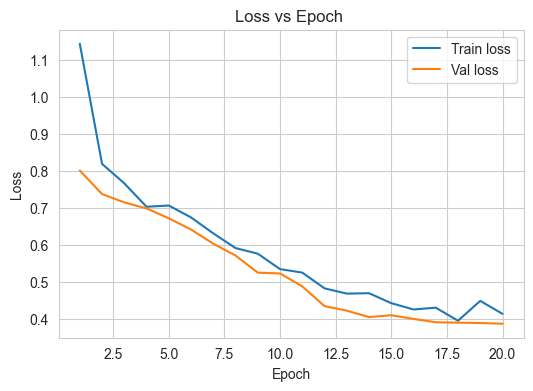

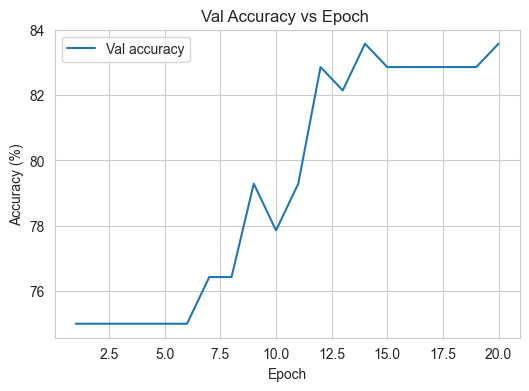


 TRAINING RESULTS:
   Best VAL accuracy no gates: 83.6%
   Best epoch no gates: 14
   Total epochs: 20
   Saved checkpoint: best_tiny_transformer_epoch_14_83.6.pth


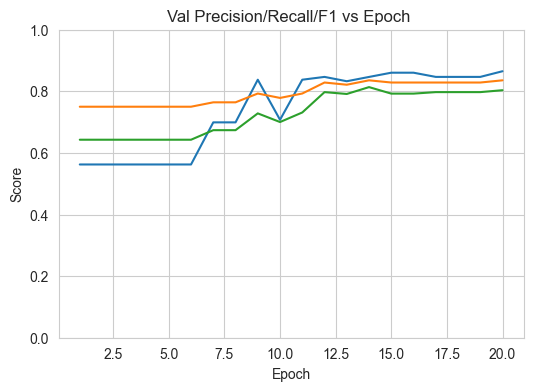

In [56]:
if 'trainer_no_gates' in locals() and 'train_loader' in locals() and 'val_loader' in locals():
    print("   Starting fine-tuning with proper val selection...")
    print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

    finetune_results_no_gates = finetune_tiny_transformer(
        trainer=trainer_no_gates,
        train_loader=train_loader,
        val_loader=val_loader,                     # Validation data
        num_epochs=20,
        save_model=True,
    )


    # Show final results (keys updated)
    print("\n TRAINING RESULTS:")
    print(f"   Best VAL accuracy no gates: {finetune_results_no_gates['best_val_accuracy']:.1f}%")
    print(f"   Best epoch no gates: {finetune_results_no_gates['best_epoch']}")
    print(f"   Total epochs: {finetune_results_no_gates['final_epoch']}")
    if finetune_results_no_gates.get('best_checkpoint_path'):
        print(f"   Saved checkpoint: {finetune_results_no_gates['best_checkpoint_path']}")

In [57]:
trained_model_no_gates= torch.load(finetune_results_no_gates['best_checkpoint_path'].replace(".pth", ".full.pt"), map_location=device, weights_only=False)

# Single final test evaluation
test_result_no_gates = None
if test_loader is not None:
    print("\n FINAL TEST EVALUATION:")
    test_result_no_gates = evaluate(trained_model_no_gates, test_loader, name="TEST")


print(test_result_no_gates['accuracy'])



 FINAL TEST EVALUATION:


NameError: name 'evaluate' is not defined


📊 TEST: loss=0.3555  acc=92.5%

Classification report (TEST):
              precision    recall  f1-score   support

   EyeClosed      0.986     0.925     0.954      1265
        Yawn      0.722     0.781     0.750      1448
     Neutral      0.953     0.949     0.951      8670

    accuracy                          0.925     11383
   macro avg      0.887     0.885     0.885     11383
weighted avg      0.928     0.925     0.926     11383



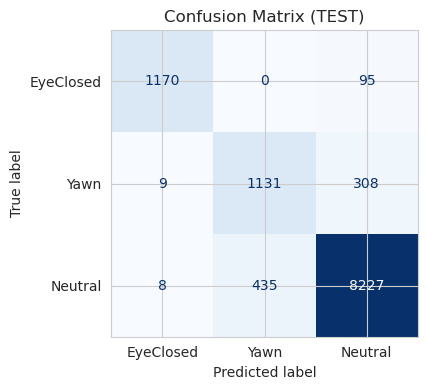

In [58]:
import torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def show_test_report_and_cm(y_true, y_pred, class_names=('EyeClosed','Yawn','Neutral')):
    print("\nClassification report (TEST):")
    # zero_division=0 suppresses divide-by-zero warnings when a class isn't predicted
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title('Confusion Matrix (TEST)')
    plt.tight_layout()
    plt.show()

# ---- REQUIREMENTS: trained_model and test_loader must be defined ----
if 'test_loader' not in locals() or test_loader is None:
    raise RuntimeError("test_loader must be defined before running this cell.")
if 'trained_model' not in locals():
    raise RuntimeError("trained_model (your model) must be defined before running this cell.")

# Use the model's device if 'device' isn't defined
if 'device' not in locals():
    device = next(trained_model_no_gates.parameters()).device

# Ensure eval mode for correct dropout/LayerNorm behavior
trained_model_no_gates.eval()

def to_dev(x):
    if isinstance(x, torch.Tensor):
        if x.dtype == torch.float64:
            x = x.float()
        return x.to(device)
    if isinstance(x, dict):
        return {k: to_dev(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(to_dev(v) for v in x)
    if isinstance(x, (float, int, np.number)):
        # occlusion fields etc. can be raw numbers; push as float32 tensor
        return torch.tensor(x, dtype=torch.float32, device=device)
    return x

criterion = torch.nn.CrossEntropyLoss()
all_preds, all_labels = [], []
total_loss, n = 0.0, 0

with torch.no_grad():
    for batch in test_loader:
        # move nested structures
        batch_dev = {
            k: ({r: to_dev(t) for r, t in v.items()} if k == 'features' and isinstance(v, dict) else to_dev(v))
            for k, v in batch.items()
        }

        # occlusion_info may not exist for no-gates runs; pass None safely
        occlusion_info = batch_dev.get('occlusion_info', None)

        out = trained_model_no_gates(batch_dev['features'], occlusion_info)
        logits = out['class_logits']

        # CE needs Long labels; enforce dtype
        labels_t = batch_dev['label'].view(-1)
        if labels_t.dtype != torch.long:
            labels_t = labels_t.long()

        loss = criterion(logits, labels_t)
        total_loss += float(loss.item()) * labels_t.shape[0]
        n += labels_t.shape[0]

        preds = torch.argmax(logits, dim=-1).detach().cpu().numpy()
        labels_np = labels_t.detach().cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels_np.tolist())

test_loss = total_loss / max(n, 1)
test_acc = (np.mean(np.array(all_preds) == np.array(all_labels)) * 100.0) if n > 0 else 0.0
print(f"\n📊 TEST: loss={test_loss:.4f}  acc={test_acc:.1f}%")

# IMPORTANT: class_names order must match label encoding 0..N-1
show_test_report_and_cm(all_labels, all_preds, class_names=('EyeClosed','Yawn','Neutral'))
